# Обзор refined full-covariance HMM grid

Ноутбук читает результаты `train_hmm_refined_full_grid.py`: модели `covariance_type=full`, `n_components=2..10`, top random states из первого broad grid. Фокус: BIC/AIC/LogLik, occupancy, полные распределения длительностей, transition matrix, state means и state covariances.

In [1]:
from __future__ import annotations

import io
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from botocore.exceptions import ClientError

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "build_price_feature_day.py").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from build_price_feature_day import make_s3_client

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 200)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
S3_BUCKET = "binance-data-downloader"
OUTPUT_PREFIX = "features/hmm_grid_search/refined_full_results"

# Пример: RUN_ID = "refined_full_20260705_120000". None возьмёт самый свежий run.
RUN_ID = None
EXPECTED_MODELS = 135

s3 = make_s3_client()

In [3]:
def list_s3_keys(bucket: str, prefix: str) -> list[str]:
    keys = []
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix.rstrip("/") + "/"):
        keys.extend(item["Key"] for item in page.get("Contents", []))
    return keys


def s3_key_exists(bucket: str, key: str) -> bool:
    try:
        s3.head_object(Bucket=bucket, Key=key)
        return True
    except ClientError as exc:
        code = exc.response.get("Error", {}).get("Code")
        if code in {"404", "NoSuchKey", "NotFound"}:
            return False
        raise


def read_s3_parquet(bucket: str, key: str) -> pd.DataFrame:
    body = s3.get_object(Bucket=bucket, Key=key)["Body"].read()
    return pd.read_parquet(io.BytesIO(body))


def all_results_key(run_id: str) -> str:
    return f"{OUTPUT_PREFIX.strip('/')}/runs/run_id={run_id}/all_results.parquet"


def models_prefix(run_id: str) -> str:
    return f"{OUTPUT_PREFIX.strip('/')}/runs/run_id={run_id}/models"


def discover_run_ids() -> pd.DataFrame:
    keys = list_s3_keys(S3_BUCKET, f"{OUTPUT_PREFIX.strip('/')}/runs")
    rows = []
    for key in keys:
        if "/run_id=" not in key:
            continue
        run_id = key.split("/run_id=", 1)[1].split("/", 1)[0]
        rows.append({"run_id": run_id, "key": key, "is_all_results": key.endswith("/all_results.parquet"), "is_model_result": key.endswith("/result.parquet")})
    if not rows:
        return pd.DataFrame(columns=["run_id", "has_all_results", "model_files"])
    frame = pd.DataFrame(rows)
    return (
        frame.groupby("run_id", as_index=False)
        .agg(has_all_results=("is_all_results", "any"), model_files=("is_model_result", "sum"))
        .sort_values("run_id", ascending=False)
        .reset_index(drop=True)
    )


def load_results(run_id: str | None) -> tuple[str, pd.DataFrame]:
    runs = discover_run_ids()
    display(runs.head(20))
    if run_id is None:
        candidates = runs[runs["has_all_results"]]
        if candidates.empty:
            candidates = runs[runs["model_files"].gt(0)]
        if candidates.empty:
            raise FileNotFoundError(f"No refined result runs found under s3://{S3_BUCKET}/{OUTPUT_PREFIX}/runs/")
        run_id = candidates.iloc[0]["run_id"]

    final_key = all_results_key(run_id)
    if s3_key_exists(S3_BUCKET, final_key):
        return run_id, read_s3_parquet(S3_BUCKET, final_key)

    result_keys = [key for key in list_s3_keys(S3_BUCKET, models_prefix(run_id)) if key.endswith("/result.parquet")]
    if not result_keys:
        raise FileNotFoundError(f"No refined model result files found for run_id={run_id}")
    frames = [read_s3_parquet(S3_BUCKET, key) for key in sorted(result_keys)]
    return run_id, pd.concat(frames, ignore_index=True)

In [4]:
run_id, raw_results = load_results(RUN_ID)
print(f"Loaded run_id={run_id}")
print(f"Rows: {len(raw_results):,}")
raw_results.head()

,run_id,has_all_results,model_files
0,refined_full_20260705_115031,True,135


Loaded run_id=refined_full_20260705_115031
Rows: 135


,model_group,features,n_components,covariance_type,random_state,selected_from_broad_bic,selected_from_broad_n_components,n_rows,train_seconds,n_iter,converged,success,error,log_likelihood,aic,bic,state_occupancy,state_duration_distribution,state_duration_stats,state_mean_duration,transition_matrix,state_means,state_covariances,result_key
0,flow,"[""ada_volume_zscore_60m"", ""ada_trades_per_minu...",2,full,0,-1.580150e+07,6,2630700,115.923639,38,True,True,None,2.424101e+06,-4.848115e+06,-4.847565e+06,"[0.06583266811114913, 0.9341673318888509]","[[16, 7, 28, 24, 2, 31, 4, 19, 1, 3, 5, 7, 6, ...","[{""count"": 74398, ""mean"": 2.3278313933170245, ...","[2.3278313933170245, 33.03154612293176]","[[0.5692777807802402, 0.4307222192197598], [0....","[[0.03666961022757481, -0.2648717859075746, 0....","[[[0.9893215252387543, 0.0216173438962584, 0.0...",features/hmm_grid_search/refined_full_results/...
1,flow,"[""ada_volume_zscore_60m"", ""ada_trades_per_minu...",2,full,9,-1.580150e+07,6,2630700,145.730800,45,True,True,None,2.424101e+06,-4.848115e+06,-4.847565e+06,"[0.06583266811114913, 0.9341673318888509]","[[16, 7, 28, 24, 2, 31, 4, 19, 1, 3, 5, 7, 6, ...","[{""count"": 74398, ""mean"": 2.3278313933170245, ...","[2.3278313933170245, 33.03154612293176]","[[0.5692783275812261, 0.4307216724187739], [0....","[[0.03666960374778259, -0.2648718014107908, 0....","[[[0.9893215089985751, 0.02161734374545541, 0....",features/hmm_grid_search/refined_full_results/...
2,flow,"[""ada_volume_zscore_60m"", ""ada_trades_per_minu...",2,full,11,-1.580150e+07,6,2630700,87.534833,40,True,True,None,2.424101e+06,-4.848115e+06,-4.847565e+06,"[0.06583266811114913, 0.9341673318888509]","[[16, 7, 28, 24, 2, 31, 4, 19, 1, 3, 5, 7, 6, ...","[{""count"": 74398, ""mean"": 2.3278313933170245, ...","[2.3278313933170245, 33.03154612293176]","[[0.5692794388011304, 0.4307205611988696], [0....","[[0.03666962588232394, -0.264871745171792, 0.0...","[[[0.9893215624018902, 0.02161734408295034, 0....",features/hmm_grid_search/refined_full_results/...
3,flow,"[""ada_volume_zscore_60m"", ""ada_trades_per_minu...",2,full,15,-1.580150e+07,6,2630700,98.663540,40,True,True,None,2.424101e+06,-4.848115e+06,-4.847565e+06,"[0.9341673318888509, 0.06583266811114913]","[[22, 20, 26, 5, 43, 2, 38, 13, 11, 12, 57, 2,...","[{""count"": 74399, ""mean"": 33.03154612293176, ""...","[33.03154612293176, 2.3278313933170245]","[[0.9693076327106934, 0.03069236728930653], [0...","[[-0.0026129968809457857, 0.018874182096472184...","[[[1.0006582858236166, 0.017310589735692092, -...",features/hmm_grid_search/refined_full_results/...
4,flow,"[""ada_volume_zscore_60m"", ""ada_trades_per_minu...",2,full,16,-1.580150e+07,6,2630700,115.356408,36,True,True,None,2.568846e+06,-5.137607e+06,-5.137057e+06,"[0.07153761356293002, 0.92846238643707]","[[3, 2, 1, 1, 1, 2, 1, 5, 5, 1, 1, 1, 2, 2, 1,...","[{""count"": 72128, ""mean"": 2.609167036379769, ""...","[2.609167036379769, 33.8630231945542]","[[0.61554189736655, 0.3844581026334501], [0.02...","[[0.07166376779367173, 1.380833709187194, 0.08...","[[[1.0596836531284914, -0.006756770432923926, ...",features/hmm_grid_search/refined_full_results/...


In [5]:
results = raw_results.copy()
numeric_columns = ["n_components", "random_state", "n_rows", "train_seconds", "n_iter", "log_likelihood", "aic", "bic", "selected_from_broad_bic", "selected_from_broad_n_components"]
for column in numeric_columns:
    if column in results.columns:
        results[column] = pd.to_numeric(results[column], errors="coerce")
results["success"] = results["success"].astype(bool)
results["converged"] = results["converged"].astype("boolean")

successful = results[results["success"]].copy()
failed = results[~results["success"]].copy()

print(f"Expected: {EXPECTED_MODELS}")
print(f"Actual: {len(results)}")
print(f"Success: {len(successful)}")
print(f"Failed: {len(failed)}")
print(f"Missing vs expected: {EXPECTED_MODELS - len(results)}")

Expected: 135
Actual: 135
Success: 135
Failed: 0
Missing vs expected: 0


## Лучшие модели по BIC/AIC/LogLik

In [6]:
metric_columns = ["model_group", "n_components", "covariance_type", "random_state", "bic", "aic", "log_likelihood", "converged", "n_iter", "train_seconds", "selected_from_broad_bic", "selected_from_broad_n_components"]

best_by_bic = successful.loc[successful.groupby("model_group")["bic"].idxmin(), metric_columns].sort_values("model_group")
best_by_aic = successful.loc[successful.groupby("model_group")["aic"].idxmin(), metric_columns].sort_values("model_group")
best_by_ll = successful.loc[successful.groupby("model_group")["log_likelihood"].idxmax(), metric_columns].sort_values("model_group")

best_by_bic

,model_group,n_components,covariance_type,random_state,bic,aic,log_likelihood,converged,n_iter,train_seconds,selected_from_broad_bic,selected_from_broad_n_components
43,flow,10,full,15,-1.988329e+07,-1.988712e+07,9.943857e+06,True,165,2660.599552,-1.580150e+07,6
89,market,10,full,14,1.068067e+07,1.067685e+07,-5.338127e+06,True,400,5184.549661,1.613726e+07,6
133,price,10,full,16,1.702541e+07,1.702159e+07,-8.510495e+06,True,400,6551.102306,1.950320e+07,6


In [7]:
print("Best by AIC")
display(best_by_aic)
print("Best by LogLik")
display(best_by_ll)

Best by AIC


,model_group,n_components,covariance_type,random_state,bic,aic,log_likelihood,converged,n_iter,train_seconds,selected_from_broad_bic,selected_from_broad_n_components
43,flow,10,full,15,-1.988329e+07,-1.988712e+07,9.943857e+06,True,165,2660.599552,-1.580150e+07,6
89,market,10,full,14,1.068067e+07,1.067685e+07,-5.338127e+06,True,400,5184.549661,1.613726e+07,6
133,price,10,full,16,1.702541e+07,1.702159e+07,-8.510495e+06,True,400,6551.102306,1.950320e+07,6


Best by LogLik


,model_group,n_components,covariance_type,random_state,bic,aic,log_likelihood,converged,n_iter,train_seconds,selected_from_broad_bic,selected_from_broad_n_components
43,flow,10,full,15,-1.988329e+07,-1.988712e+07,9.943857e+06,True,165,2660.599552,-1.580150e+07,6
89,market,10,full,14,1.068067e+07,1.067685e+07,-5.338127e+06,True,400,5184.549661,1.613726e+07,6
133,price,10,full,16,1.702541e+07,1.702159e+07,-8.510495e+06,True,400,6551.102306,1.950320e+07,6


In [8]:
hyper_summary = (
    successful.groupby(["model_group", "n_components"], as_index=False)
    .agg(
        models=("random_state", "count"),
        bic_min=("bic", "min"),
        bic_median=("bic", "median"),
        bic_std=("bic", "std"),
        aic_min=("aic", "min"),
        ll_max=("log_likelihood", "max"),
        converged_rate=("converged", "mean"),
        median_seconds=("train_seconds", "median"),
    )
    .sort_values(["model_group", "bic_min"])
)
hyper_summary

,model_group,n_components,models,bic_min,bic_median,bic_std,aic_min,ll_max,converged_rate,median_seconds
8,flow,10,5,-1.988329e+07,-1.979086e+07,1.279639e+05,-1.988712e+07,9.943857e+06,1.0,5347.521410
7,flow,9,5,-1.922299e+07,-1.910422e+07,1.047810e+05,-1.922631e+07,9.613416e+06,1.0,2368.676739
6,flow,8,5,-1.838996e+07,-1.836338e+07,2.153107e+04,-1.839281e+07,9.196630e+06,1.0,1921.276189
5,flow,7,5,-1.730335e+07,-1.724183e+07,2.736777e+05,-1.730575e+07,8.653065e+06,1.0,1214.754074
4,flow,6,5,-1.580150e+07,-1.580150e+07,3.159221e-02,-1.580348e+07,7.901896e+06,1.0,1679.212765
3,flow,5,5,-1.377915e+07,-1.349885e+07,1.218518e+05,-1.378074e+07,6.890494e+06,1.0,677.377416
2,flow,4,5,-1.079302e+07,-1.065918e+07,6.708587e+04,-1.079424e+07,5.397213e+06,1.0,404.497486
1,flow,3,5,-5.920654e+06,-5.269080e+06,6.247067e+05,-5.921523e+06,2.960830e+06,1.0,175.447799
0,flow,2,5,-5.137057e+06,-4.847565e+06,1.294645e+05,-5.137607e+06,2.568846e+06,1.0,115.356408
17,market,10,5,1.068067e+07,1.148111e+07,1.778325e+06,1.067685e+07,-5.338127e+06,1.0,5083.949515


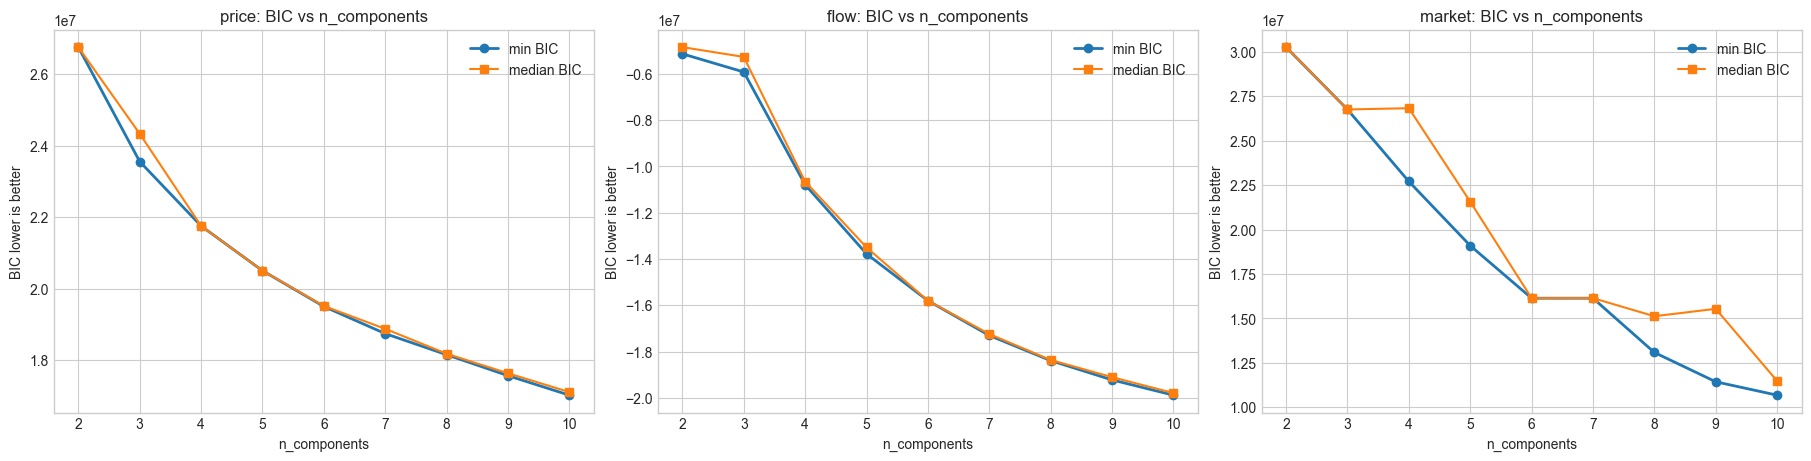

In [9]:
groups = [group for group in ["price", "flow", "market"] if group in successful["model_group"].unique()]
fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 4.5), constrained_layout=True, squeeze=False)

for axis, group in zip(axes[0], groups):
    frame = hyper_summary[hyper_summary["model_group"].eq(group)].sort_values("n_components")
    axis.plot(frame["n_components"], frame["bic_min"], marker="o", linewidth=2, label="min BIC")
    axis.plot(frame["n_components"], frame["bic_median"], marker="s", linewidth=1.5, label="median BIC")
    axis.set_title(f"{group}: BIC vs n_components")
    axis.set_xlabel("n_components")
    axis.set_ylabel("BIC lower is better")
    axis.legend()

plt.show()

## JSON parsers

In [10]:
def parse_json(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    if isinstance(value, str):
        return json.loads(value)
    return value


def parse_array(value) -> np.ndarray | None:
    parsed = parse_json(value)
    if parsed is None:
        return None
    return np.asarray(parsed, dtype="float64")


def selected_best_rows(metric: str = "bic") -> pd.DataFrame:
    if metric in {"bic", "aic"}:
        return successful.loc[successful.groupby("model_group")[metric].idxmin()].sort_values("model_group")
    return successful.loc[successful.groupby("model_group")[metric].idxmax()].sort_values("model_group")


selected_best = selected_best_rows("bic")
selected_best.loc[:, metric_columns]

,model_group,n_components,covariance_type,random_state,bic,aic,log_likelihood,converged,n_iter,train_seconds,selected_from_broad_bic,selected_from_broad_n_components
43,flow,10,full,15,-1.988329e+07,-1.988712e+07,9.943857e+06,True,165,2660.599552,-1.580150e+07,6
89,market,10,full,14,1.068067e+07,1.067685e+07,-5.338127e+06,True,400,5184.549661,1.613726e+07,6
133,price,10,full,16,1.702541e+07,1.702159e+07,-8.510495e+06,True,400,6551.102306,1.950320e+07,6


## Occupancy и средние длительности для лучших BIC

In [11]:
duration_rows = []
for _, row in selected_best.iterrows():
    occupancy = parse_array(row["state_occupancy"])
    stats_by_state = parse_json(row["state_duration_stats"])
    for state_id, state_stats in enumerate(stats_by_state):
        duration_rows.append(
            {
                "model_group": row["model_group"],
                "n_components": int(row["n_components"]),
                "random_state": int(row["random_state"]),
                "state": state_id,
                "occupancy": occupancy[state_id],
                **state_stats,
            }
        )

duration_stats_table = pd.DataFrame(duration_rows)
duration_stats_table

,model_group,n_components,random_state,state,occupancy,count,mean,std,min,max,p50,p75,p90,p95,p99
0,flow,10,15,0,1.580165e-01,28789,14.439334,12.600262,1,126,11.0,20.0,31.0,39.00,59.00
1,flow,10,15,1,8.270878e-02,77383,2.811755,2.600901,1,119,2.0,4.0,6.0,8.00,12.00
2,flow,10,15,2,3.801270e-07,1,1.000000,0.000000,1,1,1.0,1.0,1.0,1.00,1.00
3,flow,10,15,3,9.915612e-03,21498,1.213369,0.755876,1,34,1.0,1.0,2.0,2.00,4.00
4,flow,10,15,4,8.165773e-02,23289,9.223968,17.236887,1,276,3.0,7.0,29.0,42.00,85.00
5,flow,10,15,5,1.109298e-01,15773,18.501426,19.096896,1,294,12.0,26.0,41.0,55.00,89.00
6,flow,10,15,6,1.428593e-01,25680,14.634735,11.838089,1,101,11.0,21.0,30.0,37.00,55.00
7,flow,10,15,7,1.772140e-01,37332,12.487866,11.922360,1,133,8.0,17.0,29.0,36.00,55.00
8,flow,10,15,8,7.273197e-02,43507,4.397821,3.769848,1,42,3.0,6.0,9.0,12.00,19.00
9,flow,10,15,9,1.639659e-01,27051,15.945621,13.899237,1,159,12.0,23.0,33.0,42.00,64.00


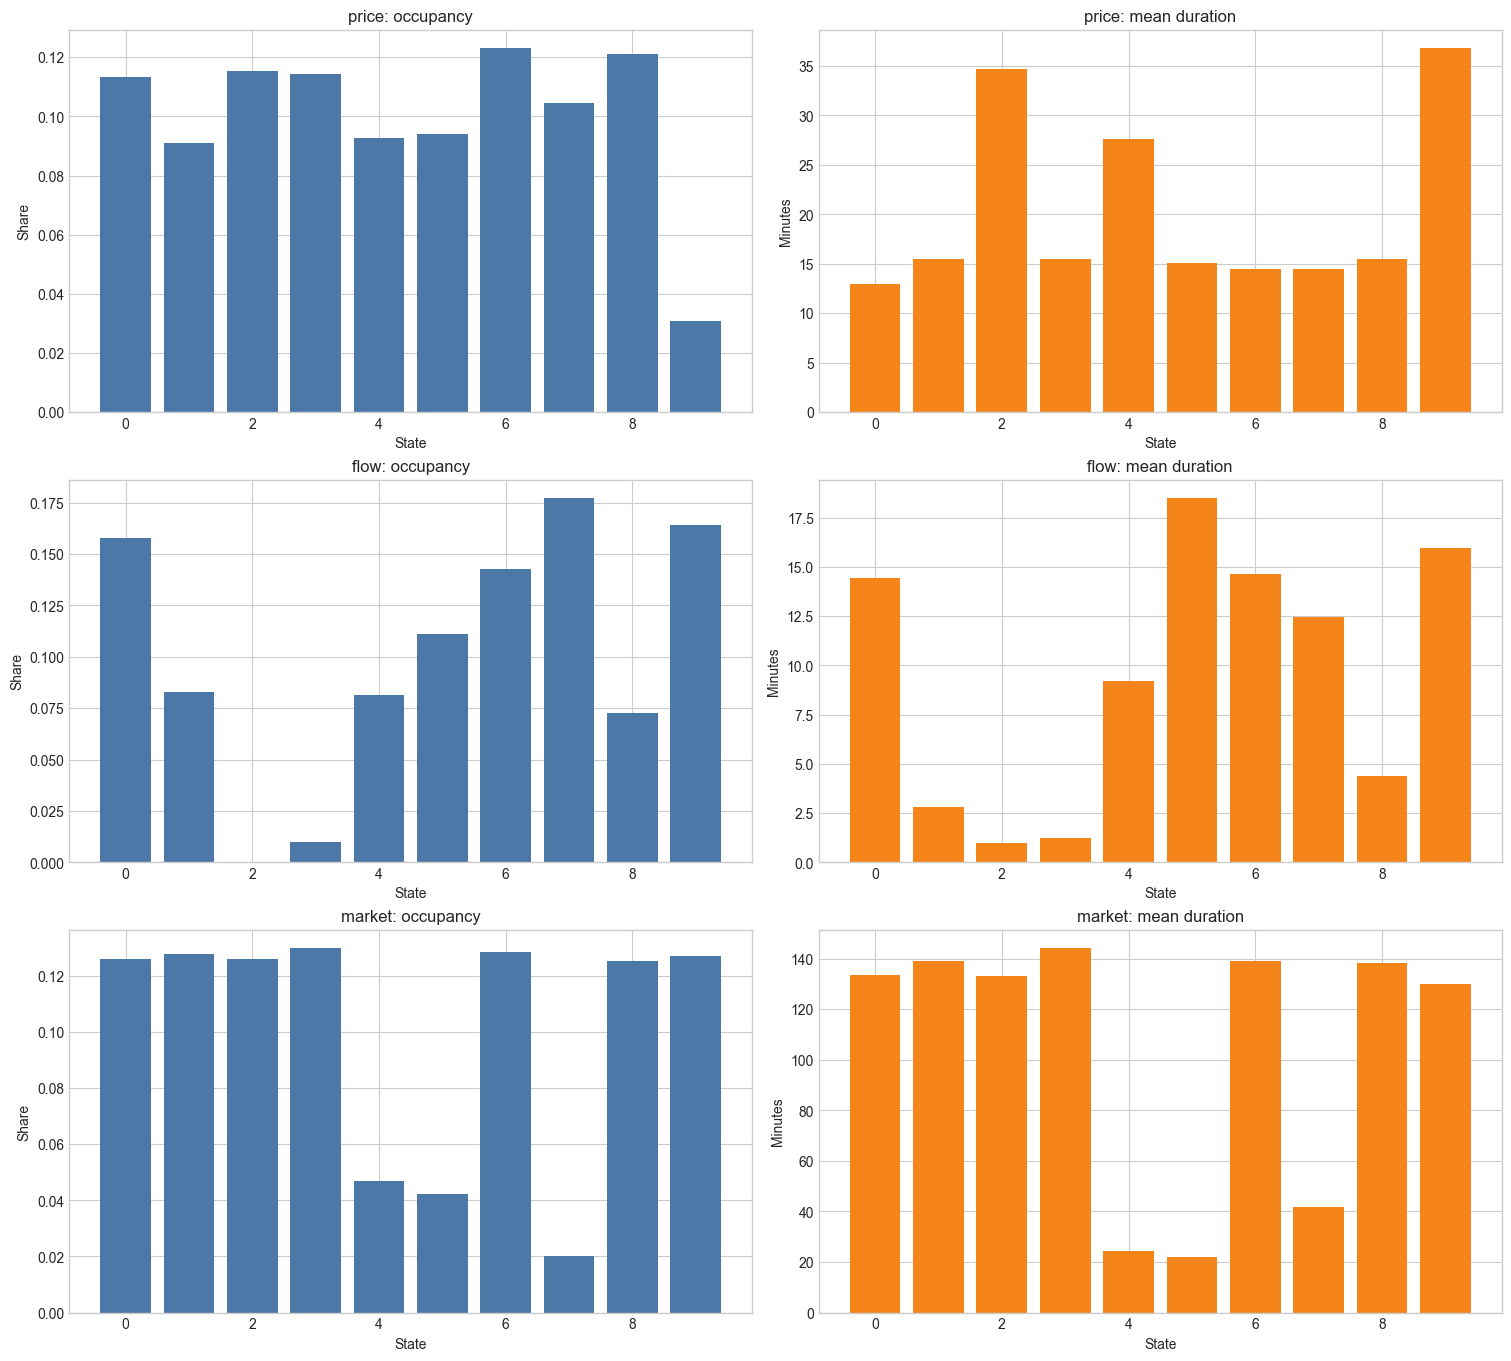

In [12]:
fig, axes = plt.subplots(len(groups), 2, figsize=(15, 4.5 * len(groups)), constrained_layout=True, squeeze=False)

for row_idx, group in enumerate(groups):
    frame = duration_stats_table[duration_stats_table["model_group"].eq(group)]
    axes[row_idx][0].bar(frame["state"], frame["occupancy"], color="#4C78A8")
    axes[row_idx][0].set_title(f"{group}: occupancy")
    axes[row_idx][0].set_xlabel("State")
    axes[row_idx][0].set_ylabel("Share")

    axes[row_idx][1].bar(frame["state"], frame["mean"], color="#F58518")
    axes[row_idx][1].set_title(f"{group}: mean duration")
    axes[row_idx][1].set_xlabel("State")
    axes[row_idx][1].set_ylabel("Minutes")

plt.show()

## Полное распределение длительностей режимов

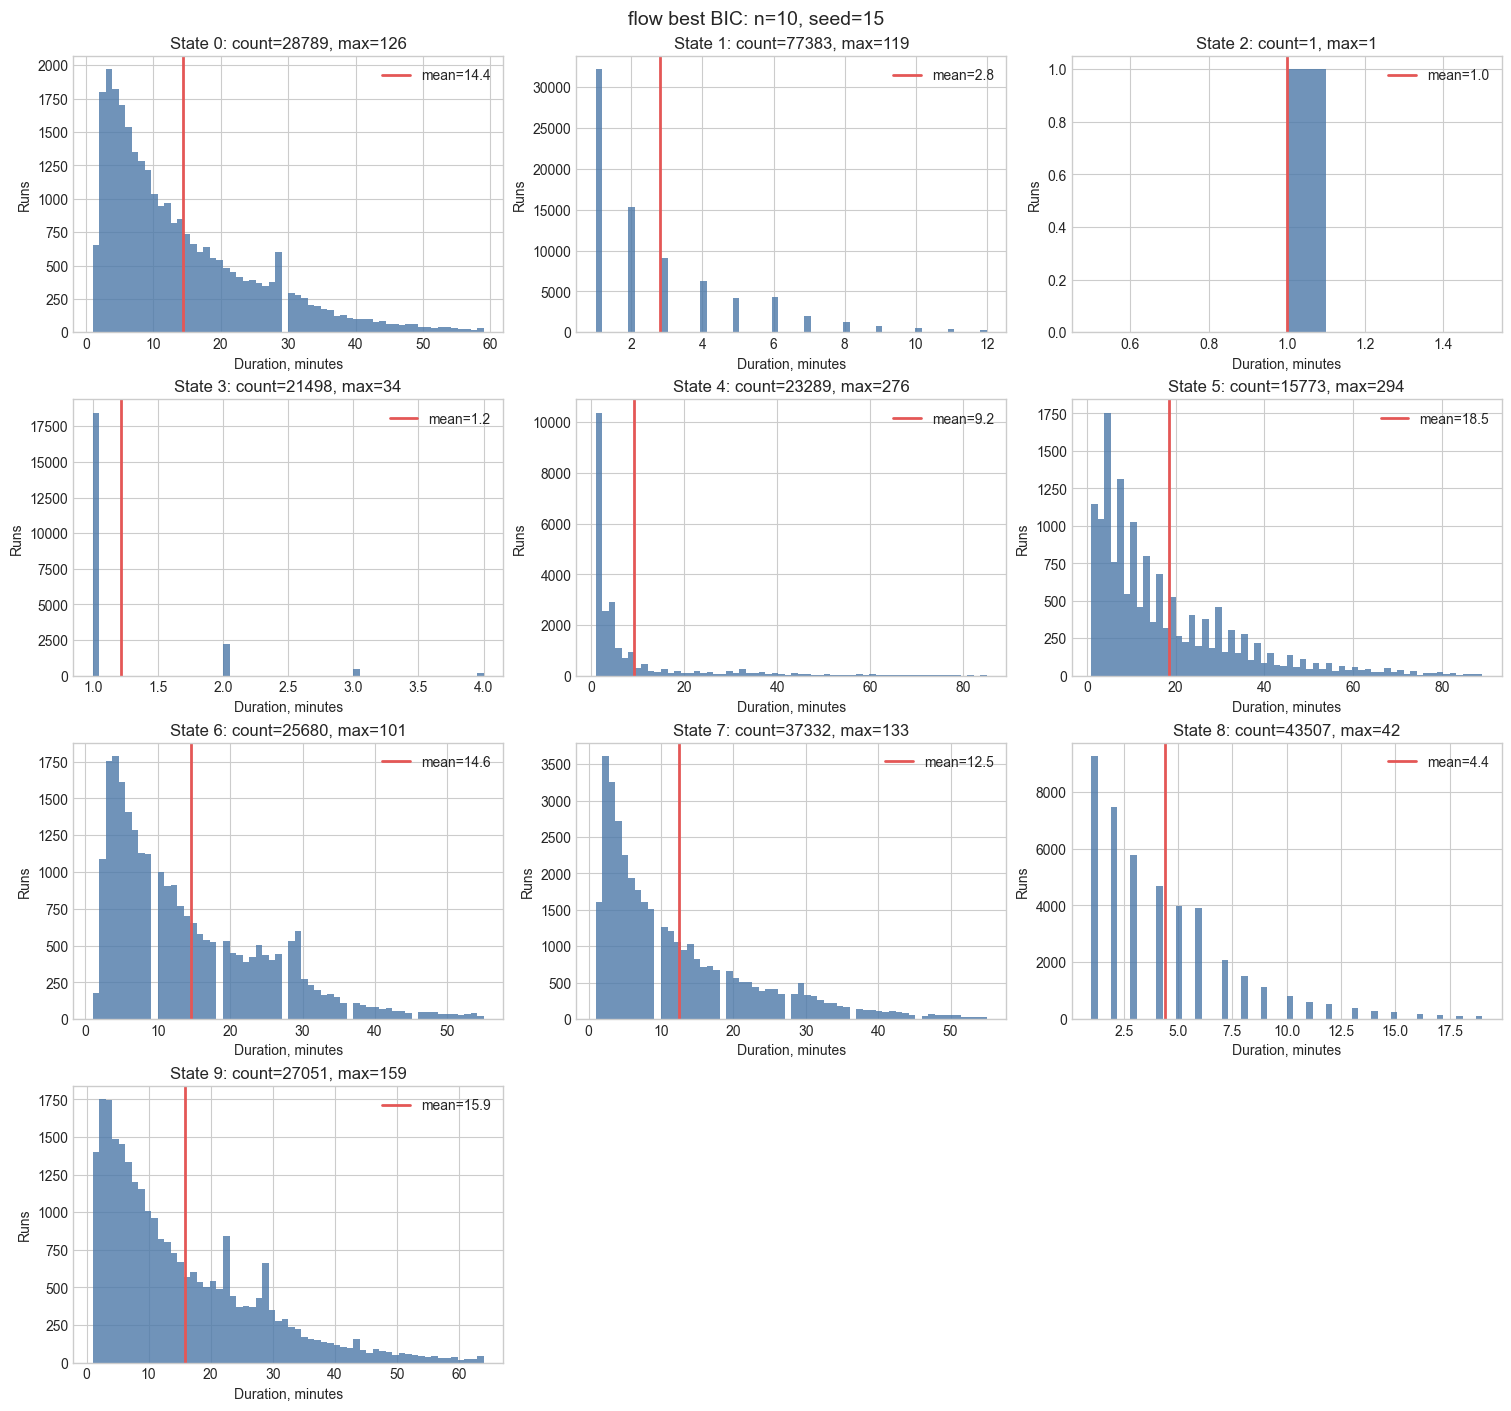

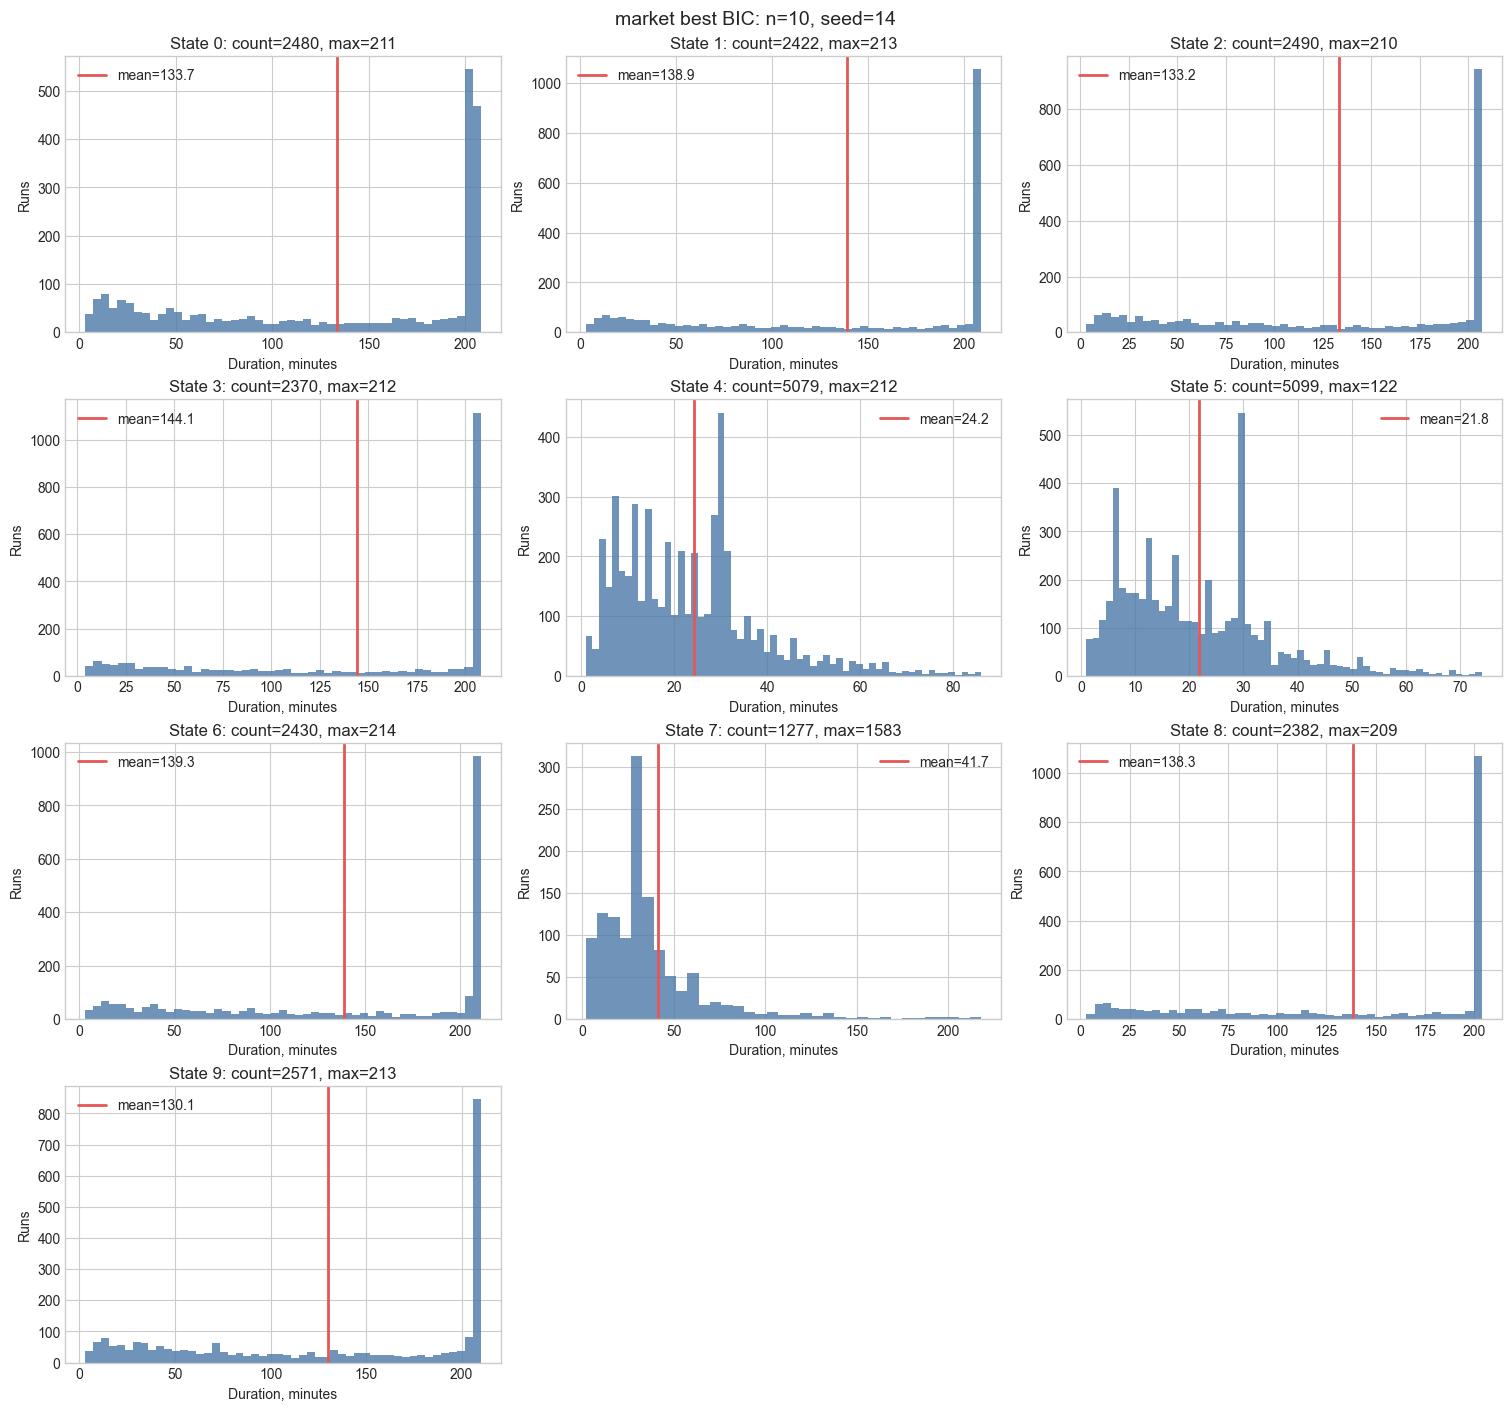

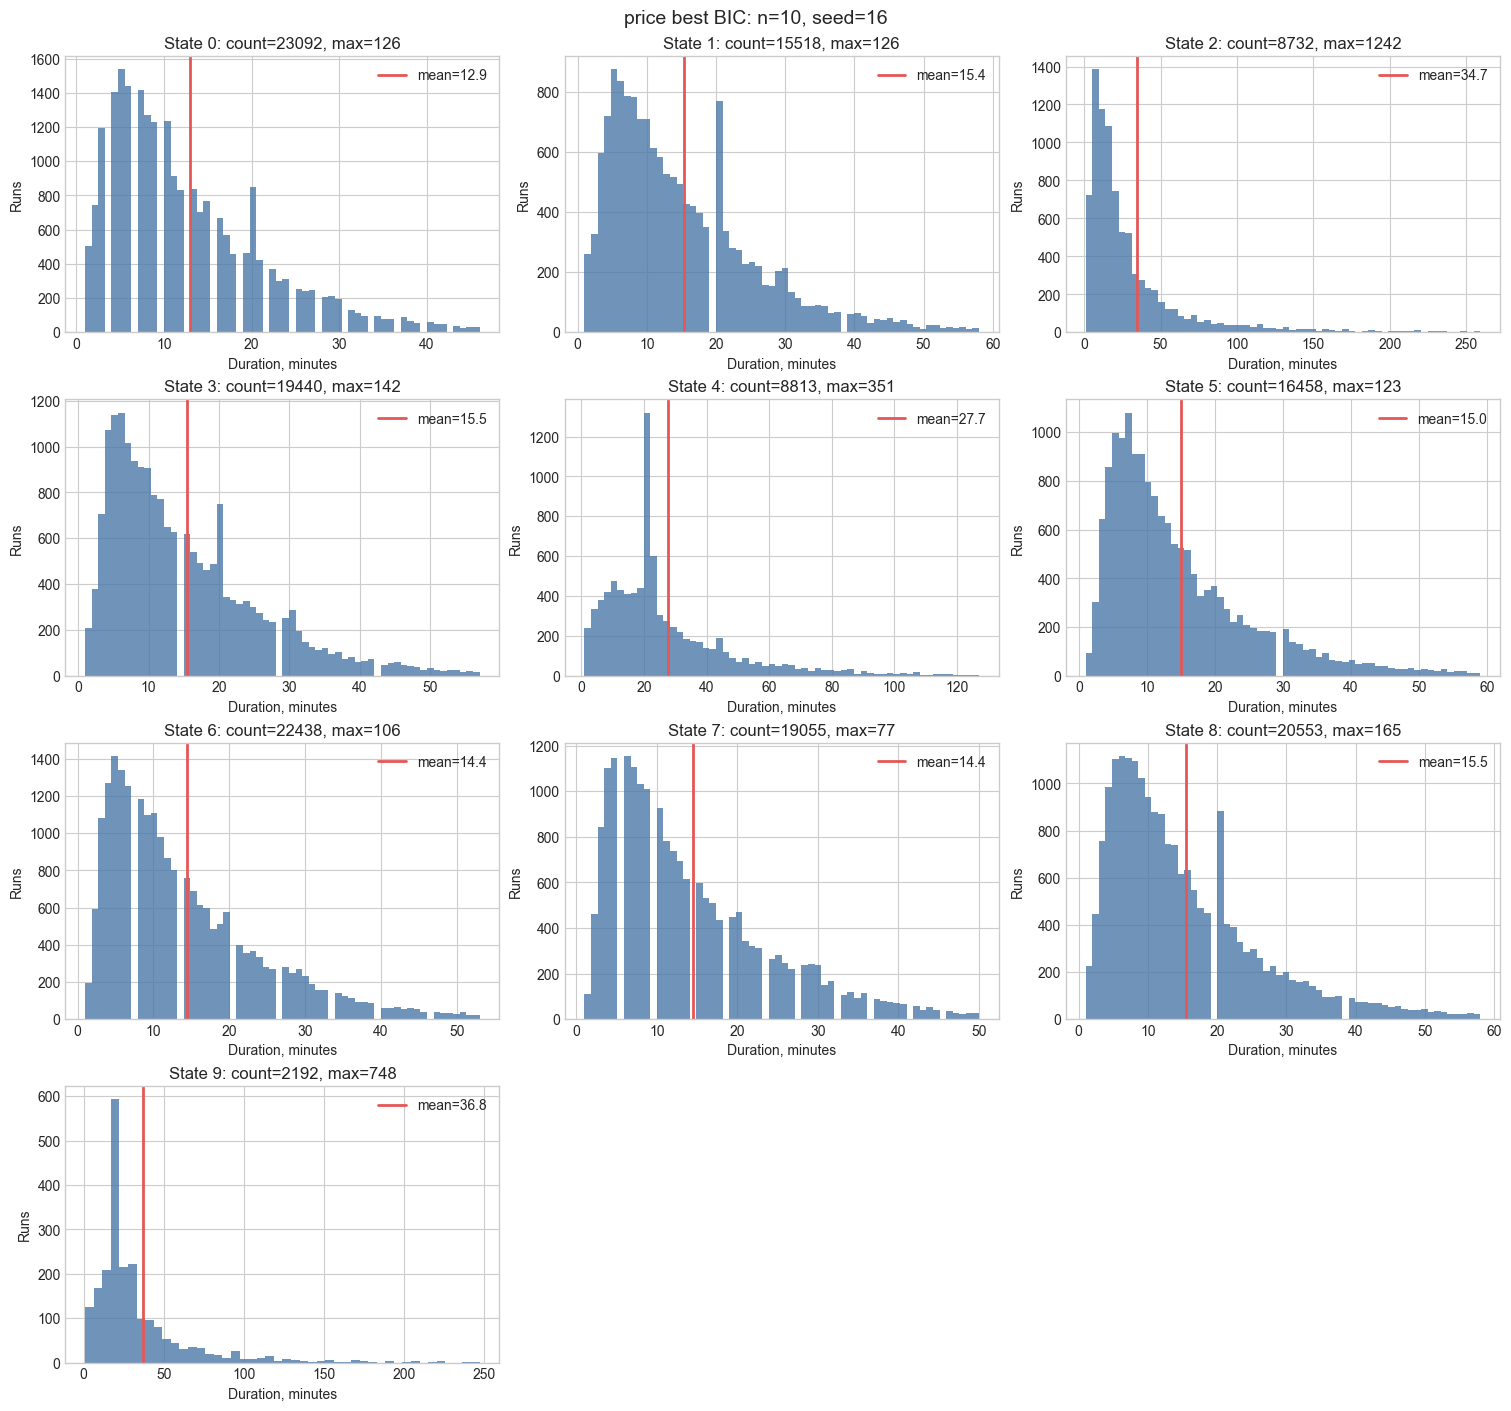

In [13]:
def plot_duration_distribution(row: pd.Series, max_duration_quantile: float = 0.99) -> None:
    durations_by_state = parse_json(row["state_duration_distribution"])
    n_states = len(durations_by_state)
    ncols = min(3, n_states)
    nrows = int(np.ceil(n_states / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), constrained_layout=True, squeeze=False)
    fig.suptitle(
        f"{row['model_group']} best BIC: n={int(row['n_components'])}, seed={int(row['random_state'])}",
        fontsize=14,
    )

    for state_id, durations in enumerate(durations_by_state):
        axis = axes[state_id // ncols][state_id % ncols]
        values = np.asarray(durations, dtype="float64")
        if len(values) == 0:
            axis.set_title(f"State {state_id}: empty")
            continue
        upper = max(1, np.quantile(values, max_duration_quantile))
        clipped = values[values <= upper]
        axis.hist(clipped, bins=min(60, max(10, int(np.sqrt(len(clipped))))), color="#4C78A8", alpha=0.8)
        axis.axvline(values.mean(), color="#E45756", linewidth=2, label=f"mean={values.mean():.1f}")
        axis.set_title(f"State {state_id}: count={len(values)}, max={values.max():.0f}")
        axis.set_xlabel("Duration, minutes")
        axis.set_ylabel("Runs")
        axis.legend()

    for state_id in range(n_states, nrows * ncols):
        axes[state_id // ncols][state_id % ncols].set_axis_off()
    plt.show()


for _, row in selected_best.iterrows():
    plot_duration_distribution(row)

## Transition matrices

## Детальный просмотр распределения длительностей

В `state_duration_distribution` лежат полные списки run-length длительностей по каждому состоянию. В ячейках ниже можно выбрать конкретную модель и посмотреть не только средние, но и форму распределения: гистограммы и survival curve `P(duration >= x)`.

In [14]:
# Настройте выбор модели. Если SELECT_RANDOM_STATE = None, берётся лучшая BIC
# модель внутри пары SELECT_MODEL_GROUP + SELECT_N_COMPONENTS.
SELECT_MODEL_GROUP = "flow"
SELECT_N_COMPONENTS = 10
SELECT_RANDOM_STATE = None


def get_selected_model_row(
    model_group: str,
    n_components: int,
    random_state: int | None = None,
) -> pd.Series:
    frame = successful[
        successful["model_group"].eq(model_group)
        & successful["n_components"].eq(n_components)
    ].copy()
    if random_state is not None:
        frame = frame[frame["random_state"].eq(random_state)]
    if frame.empty:
        raise ValueError("No model matches the selected group/n_components/random_state")
    return frame.sort_values("bic", ascending=True).iloc[0]


selected_duration_row = get_selected_model_row(
    SELECT_MODEL_GROUP,
    SELECT_N_COMPONENTS,
    SELECT_RANDOM_STATE,
)

selected_duration_row.loc[
    [
        "model_group",
        "n_components",
        "random_state",
        "bic",
        "aic",
        "log_likelihood",
        "converged",
        "n_iter",
    ]
]

model_group                  flow
n_components                   10
random_state                   15
bic              -19883294.865429
aic              -19887116.910827
log_likelihood     9943857.455413
converged                    True
n_iter                        165
Name: 43, dtype: object

In [15]:
def duration_distribution_table(row: pd.Series) -> pd.DataFrame:
    durations_by_state = parse_json(row["state_duration_distribution"])
    occupancy = parse_array(row["state_occupancy"])
    rows = []
    for state_id, durations in enumerate(durations_by_state):
        values = np.asarray(durations, dtype="float64")
        if len(values) == 0:
            rows.append(
                {
                    "state": state_id,
                    "occupancy": occupancy[state_id],
                    "runs": 0,
                    "mean": np.nan,
                    "std": np.nan,
                    "min": np.nan,
                    "p25": np.nan,
                    "p50": np.nan,
                    "p75": np.nan,
                    "p90": np.nan,
                    "p95": np.nan,
                    "p99": np.nan,
                    "max": np.nan,
                }
            )
            continue
        rows.append(
            {
                "state": state_id,
                "occupancy": occupancy[state_id],
                "runs": len(values),
                "mean": values.mean(),
                "std": values.std(ddof=1) if len(values) > 1 else 0.0,
                "min": values.min(),
                "p25": np.quantile(values, 0.25),
                "p50": np.quantile(values, 0.50),
                "p75": np.quantile(values, 0.75),
                "p90": np.quantile(values, 0.90),
                "p95": np.quantile(values, 0.95),
                "p99": np.quantile(values, 0.99),
                "max": values.max(),
            }
        )
    return pd.DataFrame(rows).sort_values("occupancy", ascending=False).reset_index(drop=True)


selected_duration_table = duration_distribution_table(selected_duration_row)
selected_duration_table

,state,occupancy,runs,mean,std,min,p25,p50,p75,p90,p95,p99,max
0,7,1.772140e-01,37332,12.487866,11.922360,1.0,4.0,8.0,17.0,29.0,36.0,55.0,133.0
1,9,1.639659e-01,27051,15.945621,13.899237,1.0,6.0,12.0,23.0,33.0,42.0,64.0,159.0
2,0,1.580165e-01,28789,14.439334,12.600262,1.0,5.0,11.0,20.0,31.0,39.0,59.0,126.0
3,6,1.428593e-01,25680,14.634735,11.838089,1.0,5.0,11.0,21.0,30.0,37.0,55.0,101.0
4,5,1.109298e-01,15773,18.501426,19.096896,1.0,6.0,12.0,26.0,41.0,55.0,89.0,294.0
5,1,8.270878e-02,77383,2.811755,2.600901,1.0,1.0,2.0,4.0,6.0,8.0,12.0,119.0
6,4,8.165773e-02,23289,9.223968,17.236887,1.0,1.0,3.0,7.0,29.0,42.0,85.0,276.0
7,8,7.273197e-02,43507,4.397821,3.769848,1.0,2.0,3.0,6.0,9.0,12.0,19.0,42.0
8,3,9.915612e-03,21498,1.213369,0.755876,1.0,1.0,1.0,1.0,2.0,2.0,4.0,34.0
9,2,3.801270e-07,1,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


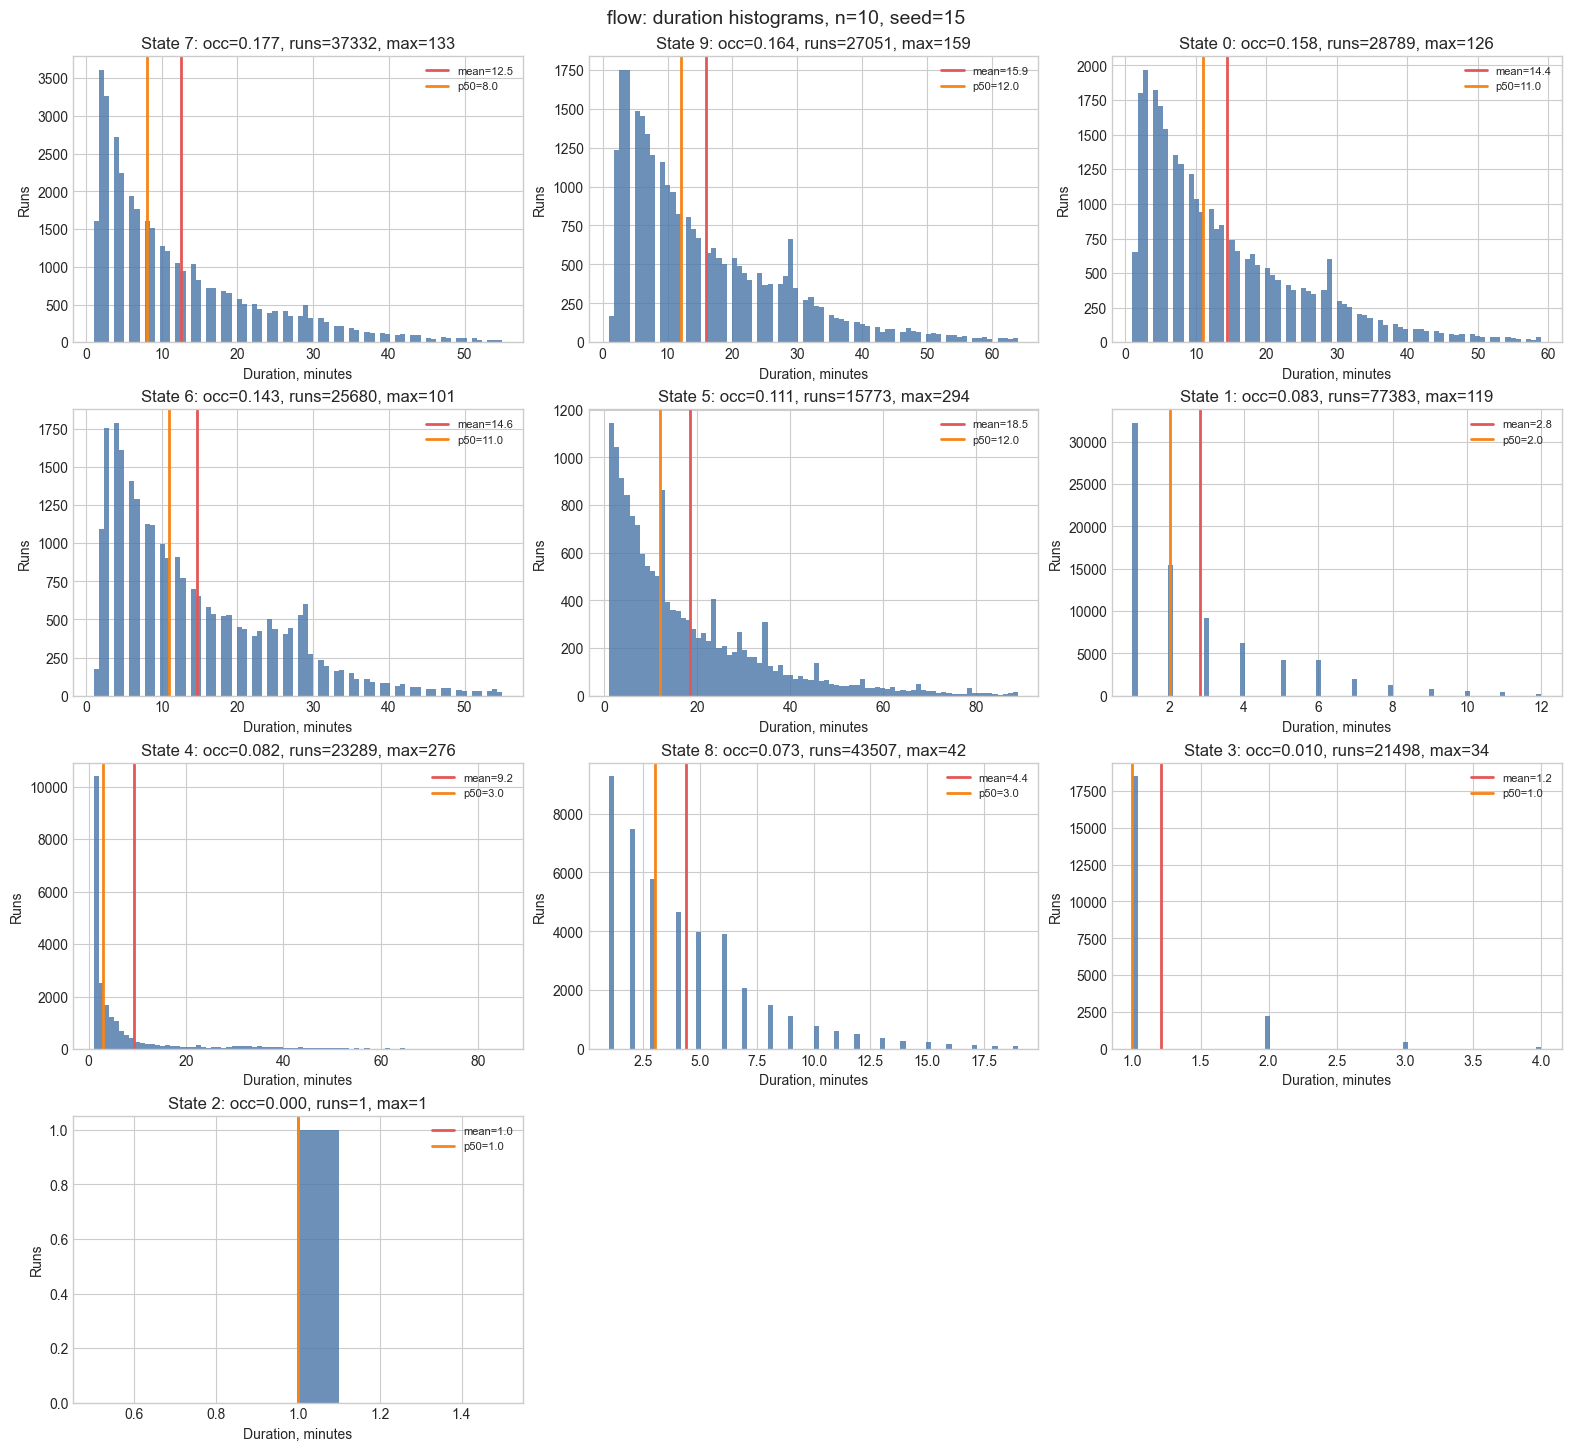

In [16]:
def plot_duration_histograms(
    row: pd.Series,
    max_duration_quantile: float = 0.99,
    max_states: int | None = None,
) -> None:
    durations_by_state = parse_json(row["state_duration_distribution"])
    occupancy = parse_array(row["state_occupancy"])
    state_order = np.argsort(-occupancy)
    if max_states is not None:
        state_order = state_order[:max_states]

    n_states = len(state_order)
    ncols = min(3, n_states)
    nrows = int(np.ceil(n_states / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), constrained_layout=True, squeeze=False)
    fig.suptitle(
        f"{row['model_group']}: duration histograms, n={int(row['n_components'])}, seed={int(row['random_state'])}",
        fontsize=14,
    )

    for plot_idx, state_id in enumerate(state_order):
        axis = axes[plot_idx // ncols][plot_idx % ncols]
        values = np.asarray(durations_by_state[state_id], dtype="float64")
        if len(values) == 0:
            axis.set_title(f"State {state_id}: empty")
            continue
        upper = max(1.0, np.quantile(values, max_duration_quantile))
        clipped = values[values <= upper]
        bins = min(80, max(10, int(np.sqrt(len(clipped)))))
        axis.hist(clipped, bins=bins, color="#4C78A8", alpha=0.82)
        axis.axvline(values.mean(), color="#E45756", linewidth=2, label=f"mean={values.mean():.1f}")
        axis.axvline(np.median(values), color="#F58518", linewidth=2, label=f"p50={np.median(values):.1f}")
        axis.set_title(f"State {state_id}: occ={occupancy[state_id]:.3f}, runs={len(values)}, max={values.max():.0f}")
        axis.set_xlabel("Duration, minutes")
        axis.set_ylabel("Runs")
        axis.legend(fontsize=8)

    for plot_idx in range(n_states, nrows * ncols):
        axes[plot_idx // ncols][plot_idx % ncols].set_axis_off()
    plt.show()


plot_duration_histograms(selected_duration_row, max_duration_quantile=0.99)

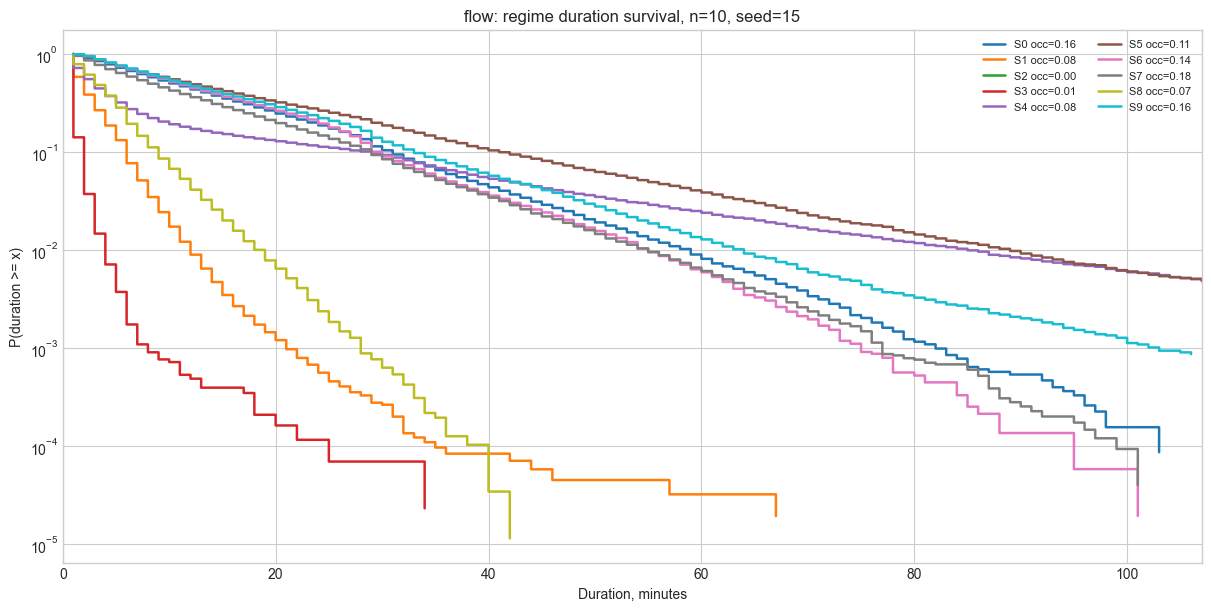

In [17]:
def plot_duration_survival(row: pd.Series, max_duration_quantile: float = 0.995) -> None:
    durations_by_state = parse_json(row["state_duration_distribution"])
    occupancy = parse_array(row["state_occupancy"])
    fig, axis = plt.subplots(figsize=(12, 6), constrained_layout=True)

    global_upper = 1.0
    for durations in durations_by_state:
        values = np.asarray(durations, dtype="float64")
        if len(values):
            global_upper = max(global_upper, np.quantile(values, max_duration_quantile))

    for state_id, durations in enumerate(durations_by_state):
        values = np.sort(np.asarray(durations, dtype="float64"))
        if len(values) == 0:
            continue
        survival = 1.0 - (np.arange(1, len(values) + 1) - 0.5) / len(values)
        mask = values <= global_upper
        axis.step(values[mask], survival[mask], where="post", linewidth=1.8, label=f"S{state_id} occ={occupancy[state_id]:.2f}")

    axis.set_title(
        f"{row['model_group']}: regime duration survival, n={int(row['n_components'])}, seed={int(row['random_state'])}"
    )
    axis.set_xlabel("Duration, minutes")
    axis.set_ylabel("P(duration >= x)")
    axis.set_yscale("log")
    axis.set_xlim(left=0, right=global_upper)
    axis.legend(ncol=2, fontsize=8)
    plt.show()


plot_duration_survival(selected_duration_row)

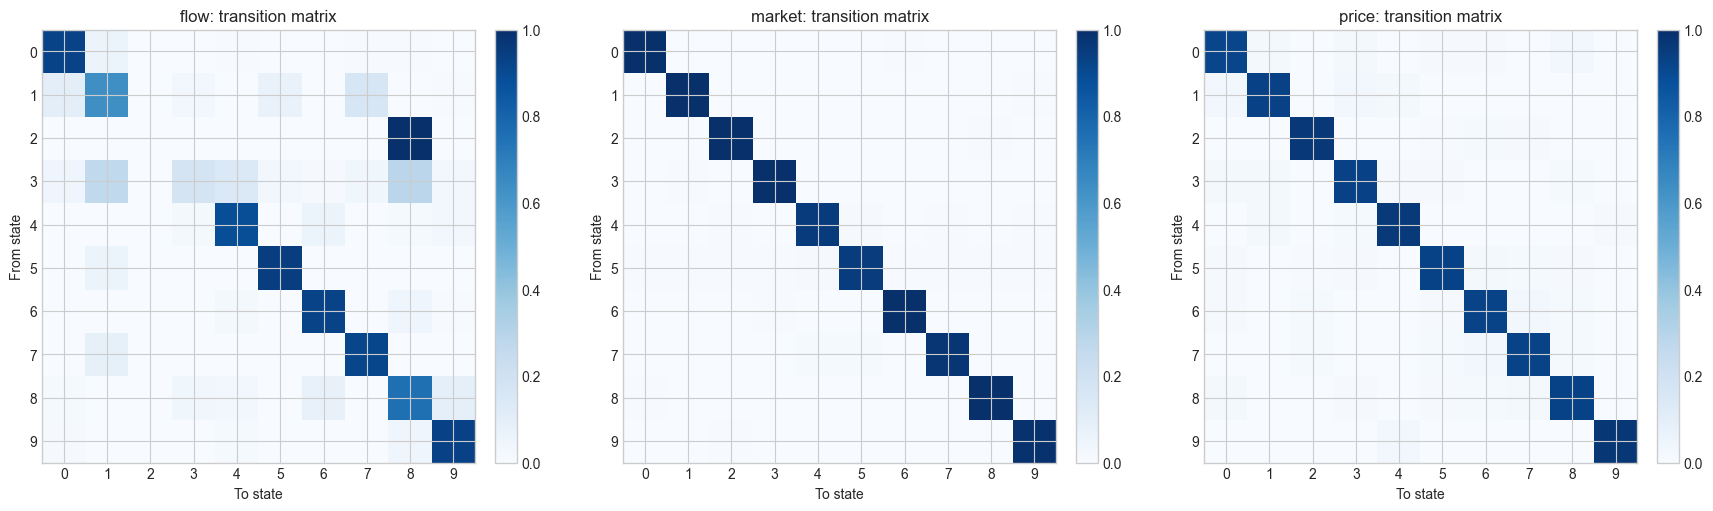

In [18]:
fig, axes = plt.subplots(1, len(groups), figsize=(5.8 * len(groups), 5), constrained_layout=True, squeeze=False)

for axis, (_, row) in zip(axes[0], selected_best.iterrows()):
    transition_matrix = parse_array(row["transition_matrix"])
    image = axis.imshow(transition_matrix, vmin=0, vmax=1, cmap="Blues")
    axis.set_title(f"{row['model_group']}: transition matrix")
    axis.set_xlabel("To state")
    axis.set_ylabel("From state")
    ticks = np.arange(transition_matrix.shape[0])
    axis.set_xticks(ticks)
    axis.set_yticks(ticks)
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

plt.show()

## State means и covariance matrices

In [19]:
state_mean_rows = []
for _, row in selected_best.iterrows():
    features = parse_json(row["features"])
    means = parse_array(row["state_means"])
    for state_id in range(means.shape[0]):
        state_mean_rows.append({"model_group": row["model_group"], "state": state_id, **dict(zip(features, means[state_id]))})

state_means_table = pd.DataFrame(state_mean_rows)
state_means_table

,model_group,state,ada_volume_zscore_60m,ada_trades_per_minute_30m,ada_aggression_delta_norm_20m,ada_large_trade_aggression_delta_norm_20m,ada_pressure_concentration_30m,btc_log_return_30m,btc_return_std_30m,btc_kaufman_efficiency_60m,time_of_day_sin,time_of_day_cos,ada_log_return_lag_1,ada_cum_return_30m,ada_return_std_20m,ada_kaufman_efficiency_90m,ada_close_position_30m
0,flow,0,-0.181411,-0.370821,0.011902,0.006953,-0.000864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,flow,1,0.877999,-0.542937,0.109886,0.110663,-0.000617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,flow,2,-0.011302,1.567285,0.189371,0.224921,1532.019653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,flow,3,0.053254,0.569725,0.130975,0.122014,0.023472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,flow,4,0.719092,2.203397,-0.079406,-0.087002,-0.000704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,flow,5,-0.146172,-0.713276,-0.038357,-0.000816,-0.000834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,flow,6,-0.264509,0.623059,-0.077808,-0.086144,-0.000921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,flow,7,-0.214413,-0.569290,0.023987,0.024536,-0.000864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,flow,8,0.137595,0.266649,0.146455,0.131491,-0.000775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,flow,9,-0.158621,-0.075575,-0.036987,-0.040139,-0.000862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


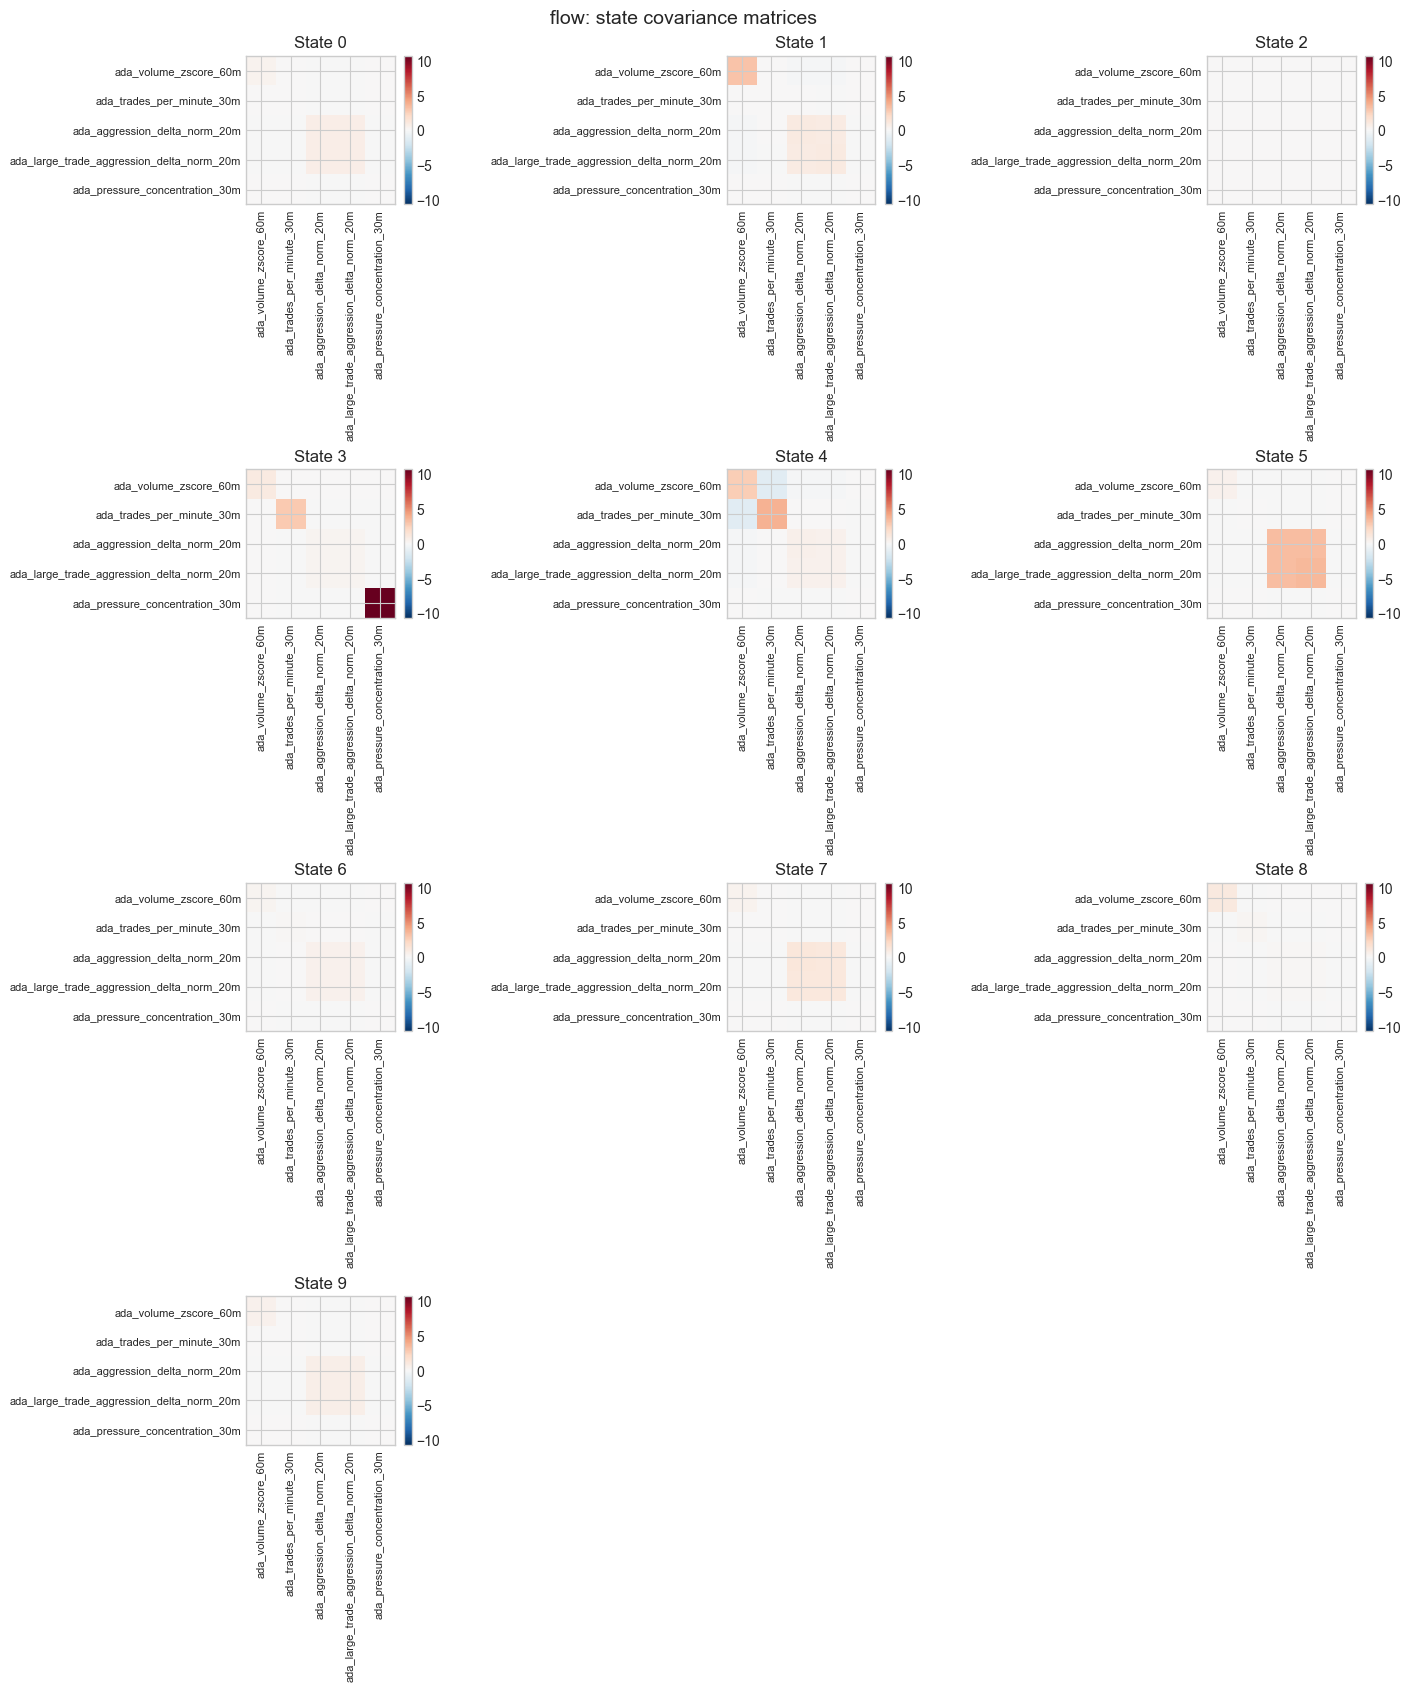

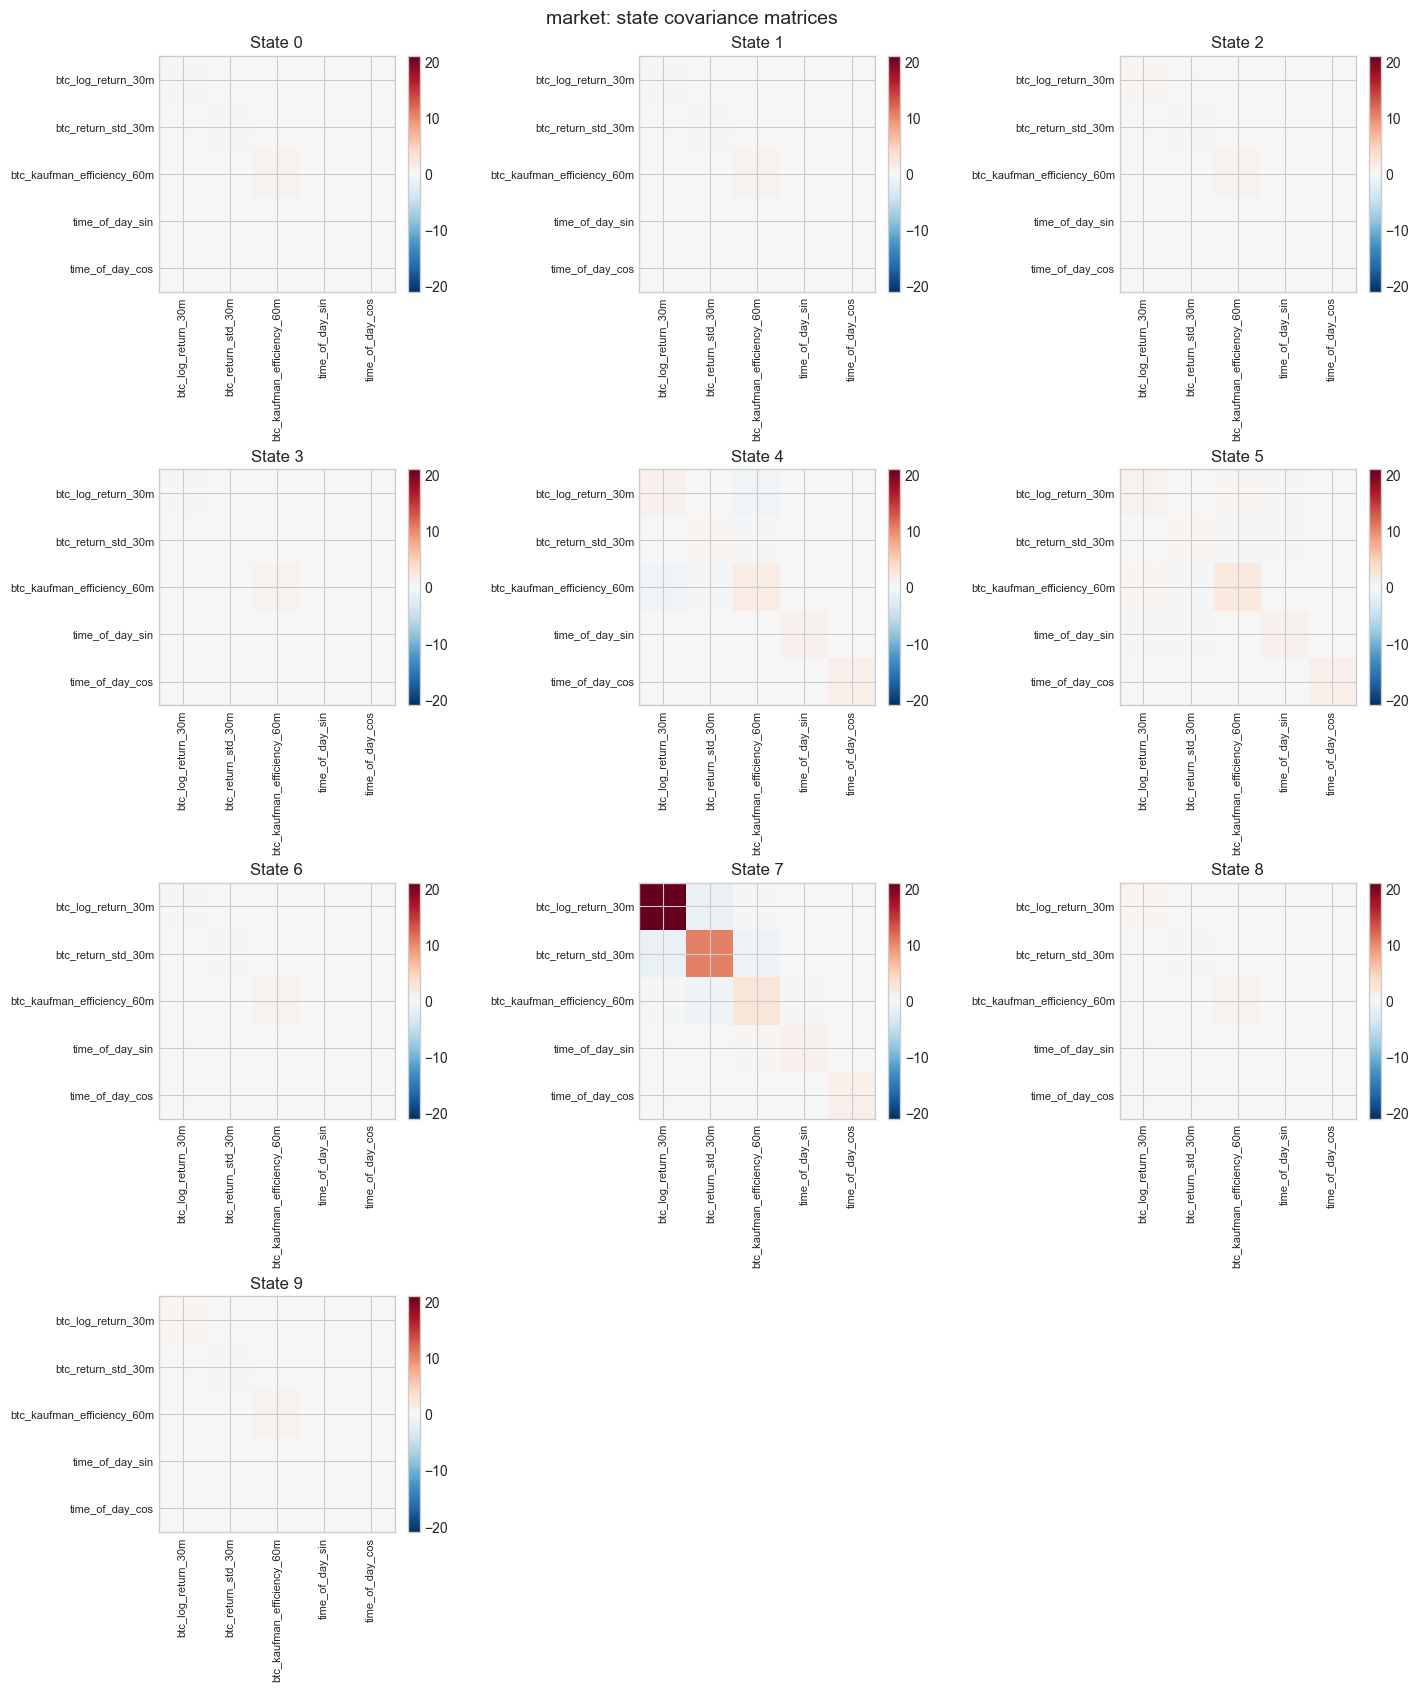

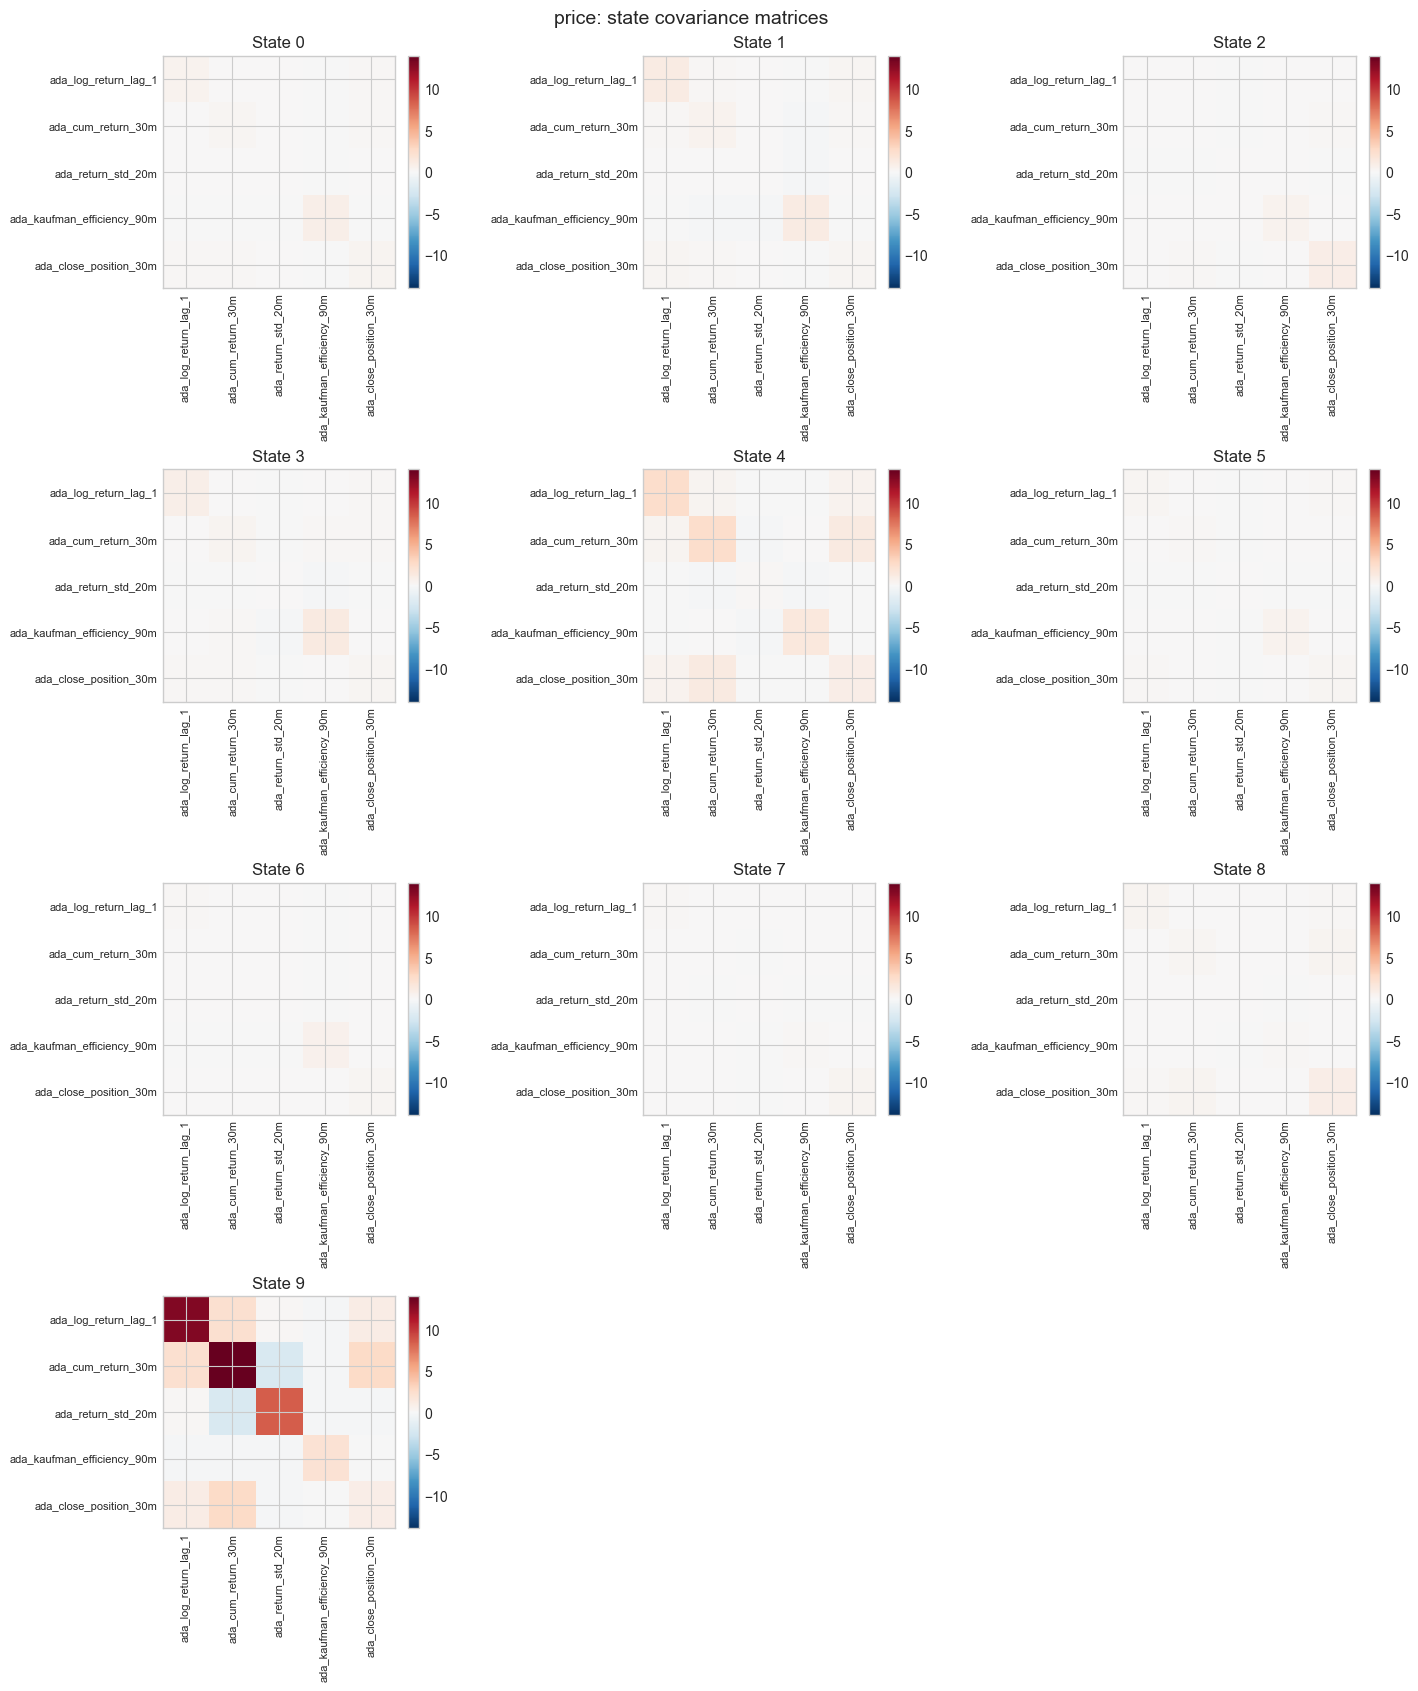

In [20]:
for _, row in selected_best.iterrows():
    features = parse_json(row["features"])
    covariances = parse_array(row["state_covariances"])
    n_states = covariances.shape[0]
    ncols = min(3, n_states)
    nrows = int(np.ceil(n_states / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.2 * nrows), constrained_layout=True, squeeze=False)
    fig.suptitle(f"{row['model_group']}: state covariance matrices", fontsize=14)
    vmax = np.nanmax(np.abs(covariances))
    for state_id in range(n_states):
        axis = axes[state_id // ncols][state_id % ncols]
        image = axis.imshow(covariances[state_id], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        axis.set_title(f"State {state_id}")
        axis.set_xticks(range(len(features)), features, rotation=90, fontsize=8)
        axis.set_yticks(range(len(features)), features, fontsize=8)
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    for state_id in range(n_states, nrows * ncols):
        axes[state_id // ncols][state_id % ncols].set_axis_off()
    plt.show()

## Экспорт таблиц

In [21]:
OUTPUT_DIR = PROJECT_ROOT / "analysis" / "hmm_grid_search" / "outputs" / f"refined_full_run_id={run_id}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

best_by_bic.to_csv(OUTPUT_DIR / "best_by_bic.csv", index=False)
best_by_aic.to_csv(OUTPUT_DIR / "best_by_aic.csv", index=False)
best_by_ll.to_csv(OUTPUT_DIR / "best_by_loglik.csv", index=False)
hyper_summary.to_csv(OUTPUT_DIR / "hyperparameter_summary.csv", index=False)
duration_stats_table.to_csv(OUTPUT_DIR / "best_bic_duration_stats.csv", index=False)
state_means_table.to_csv(OUTPUT_DIR / "best_bic_state_means.csv", index=False)
failed.to_csv(OUTPUT_DIR / "failed_models.csv", index=False)

print(f"Saved tables to: {OUTPUT_DIR}")

Saved tables to: c:\projects\binance-dowloader-3.0\analysis\hmm_grid_search\outputs\refined_full_run_id=refined_full_20260705_115031


n_components = 2


,model_group,n_components,random_state,bic,aic,log_likelihood
4,flow,2,16,-5.137057e+06,-5.137607e+06,2.568846e+06
46,market,2,5,3.025977e+07,3.025922e+07,-1.512957e+07
90,price,2,1,2.674905e+07,2.674850e+07,-1.337421e+07


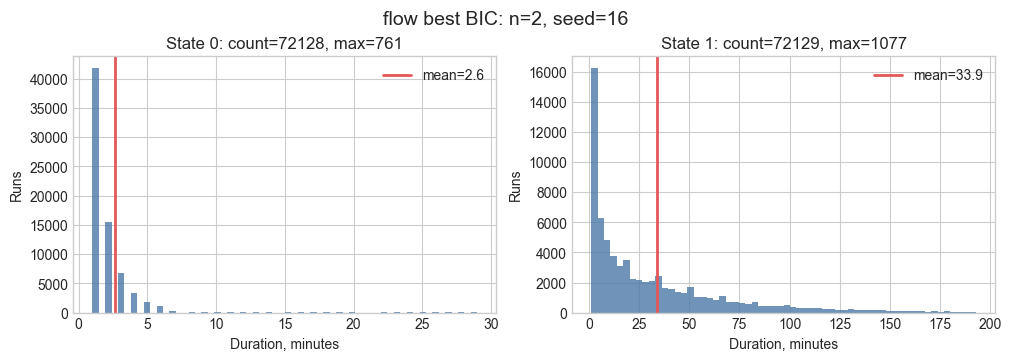

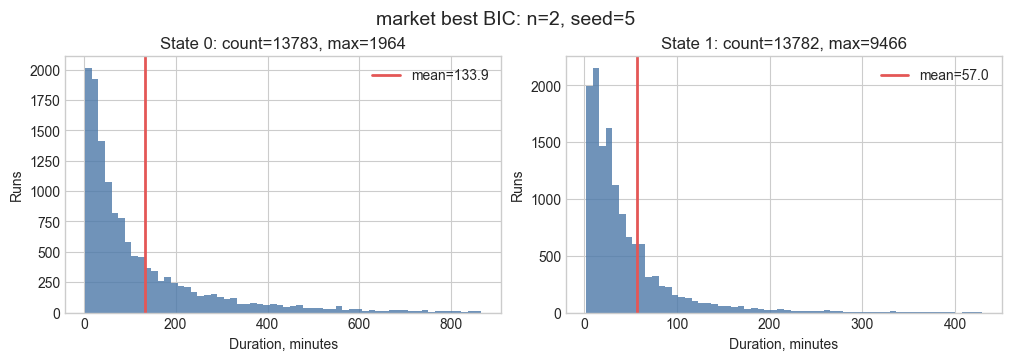

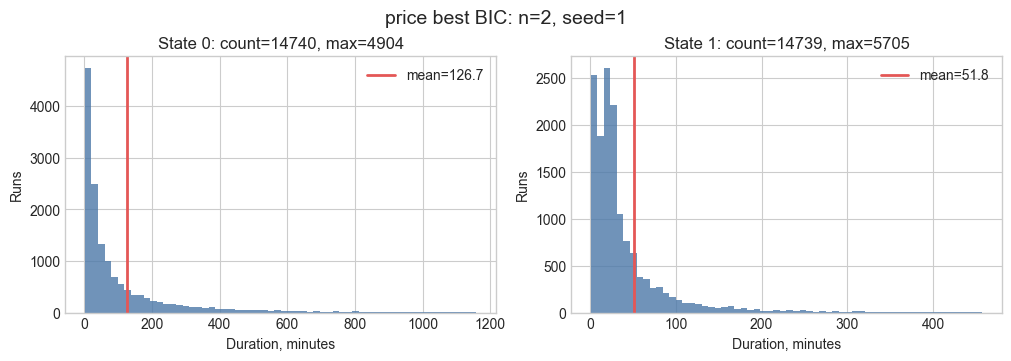

n_components = 3


,model_group,n_components,random_state,bic,aic,log_likelihood
9,flow,3,16,-5.920654e+06,-5.921523e+06,2.960830e+06
50,market,3,3,2.675396e+07,2.675309e+07,-1.337648e+07
99,price,3,19,2.355179e+07,2.355092e+07,-1.177539e+07


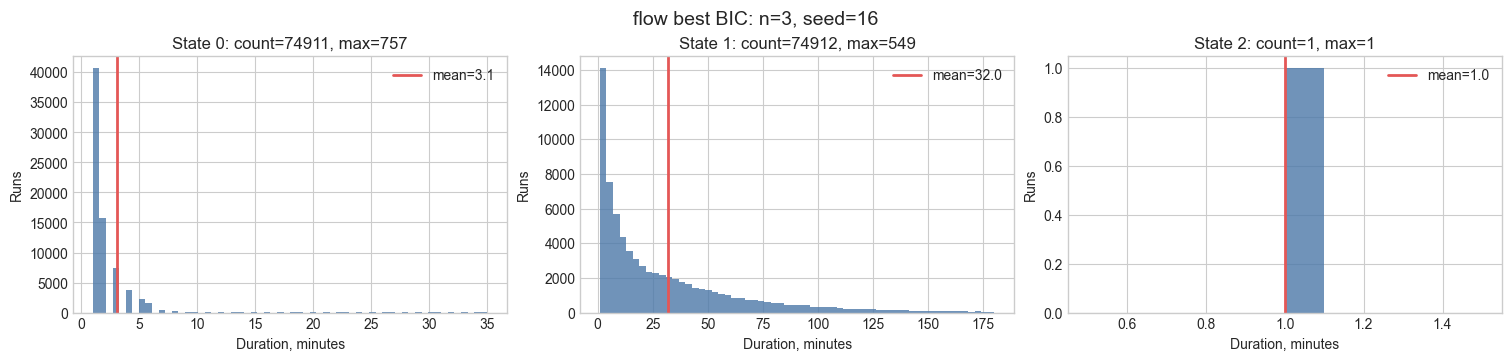

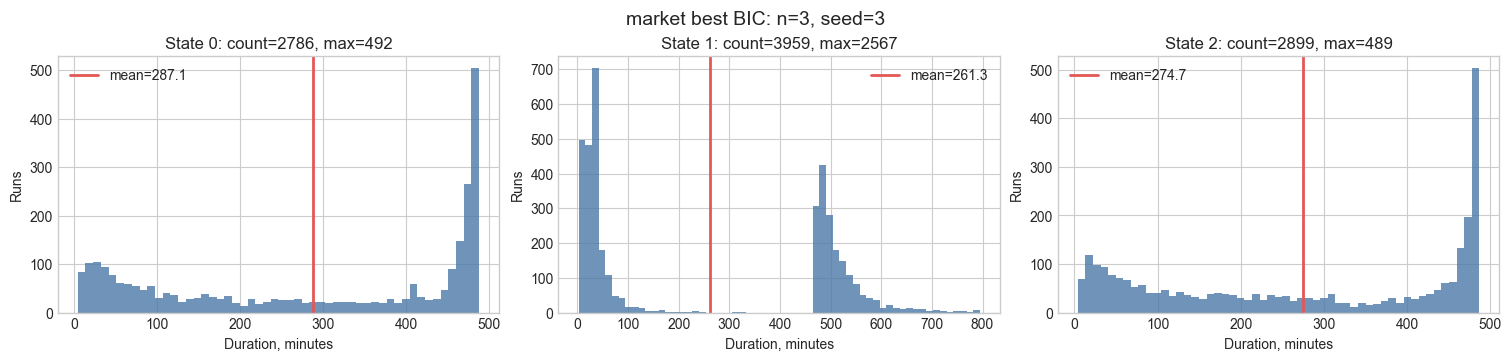

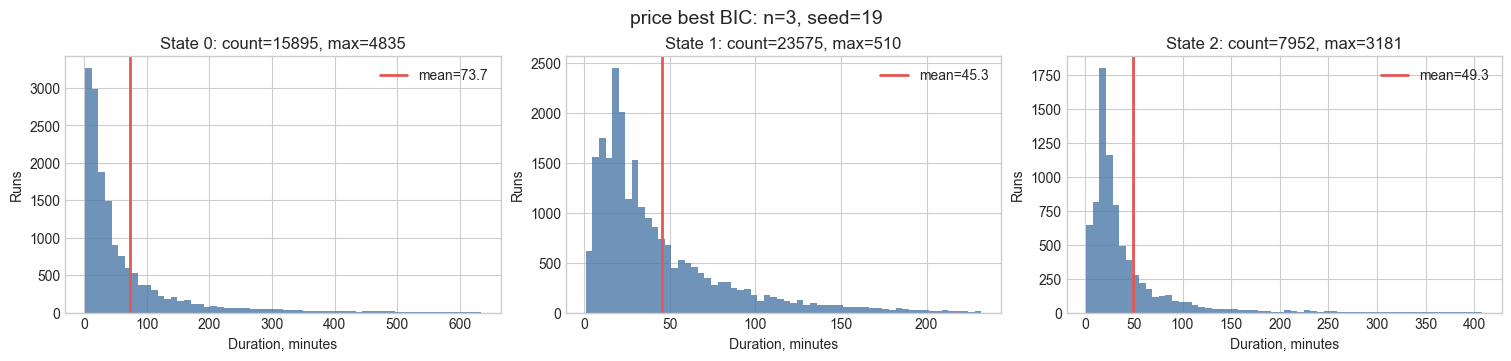

n_components = 4


,model_group,n_components,random_state,bic,aic,log_likelihood
11,flow,4,9,-1.079302e+07,-1.079424e+07,5.397213e+06
57,market,4,8,2.270362e+07,2.270241e+07,-1.135111e+07
102,price,4,15,2.175273e+07,2.175151e+07,-1.087566e+07


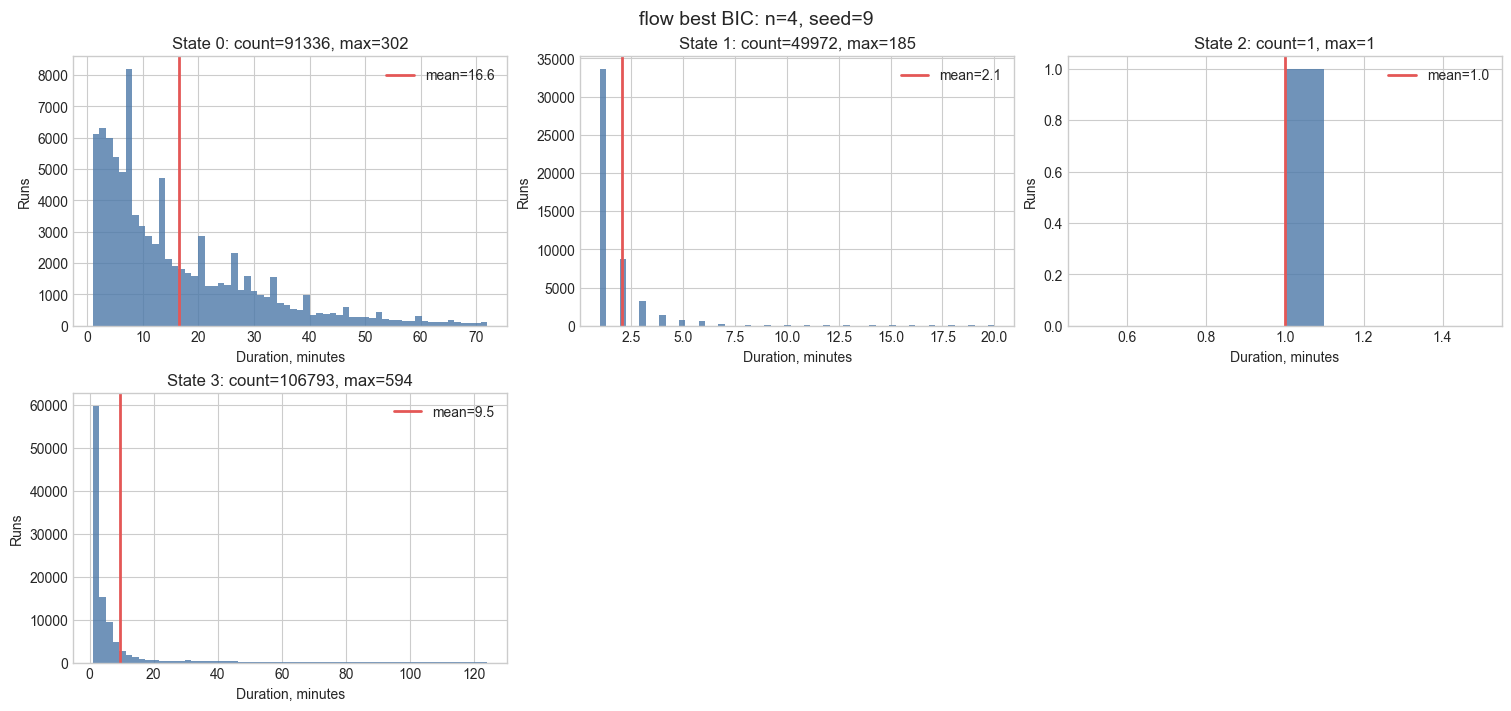

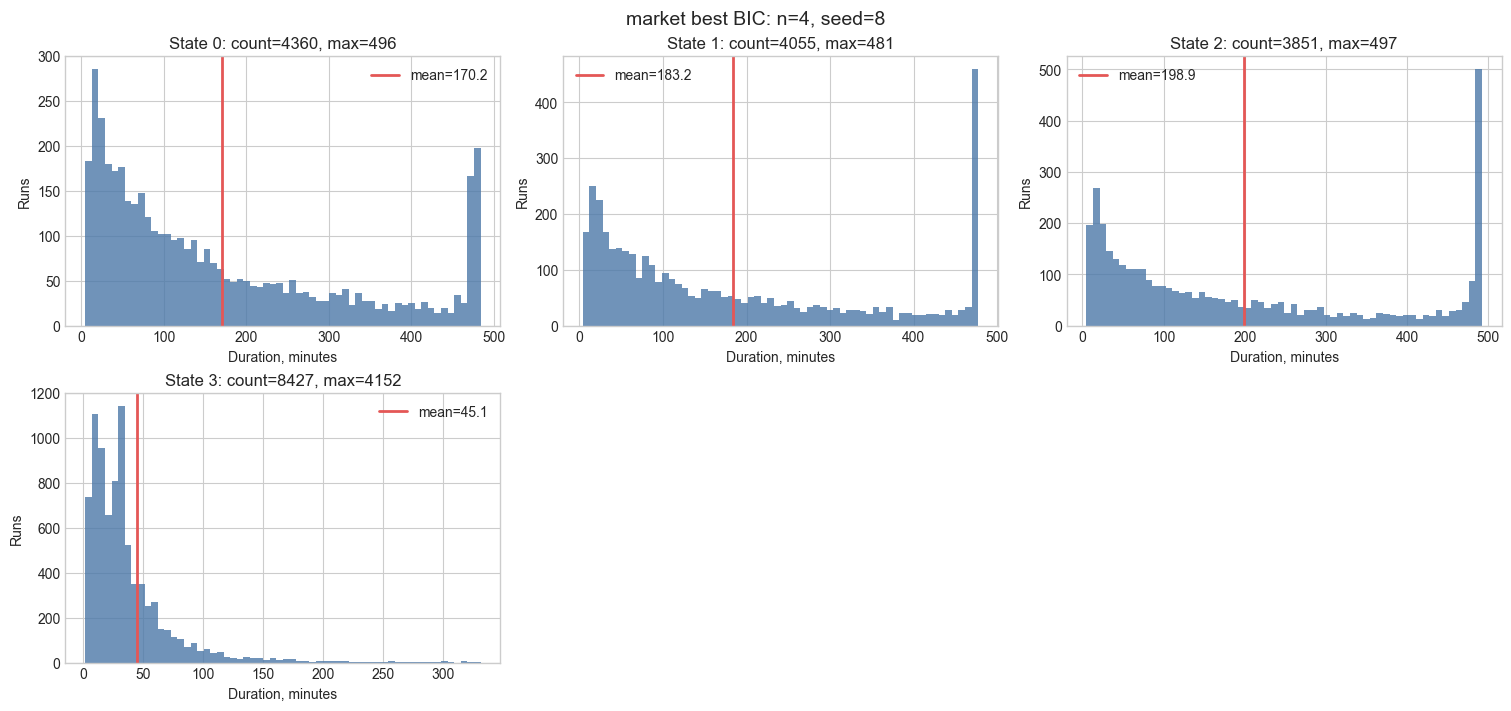

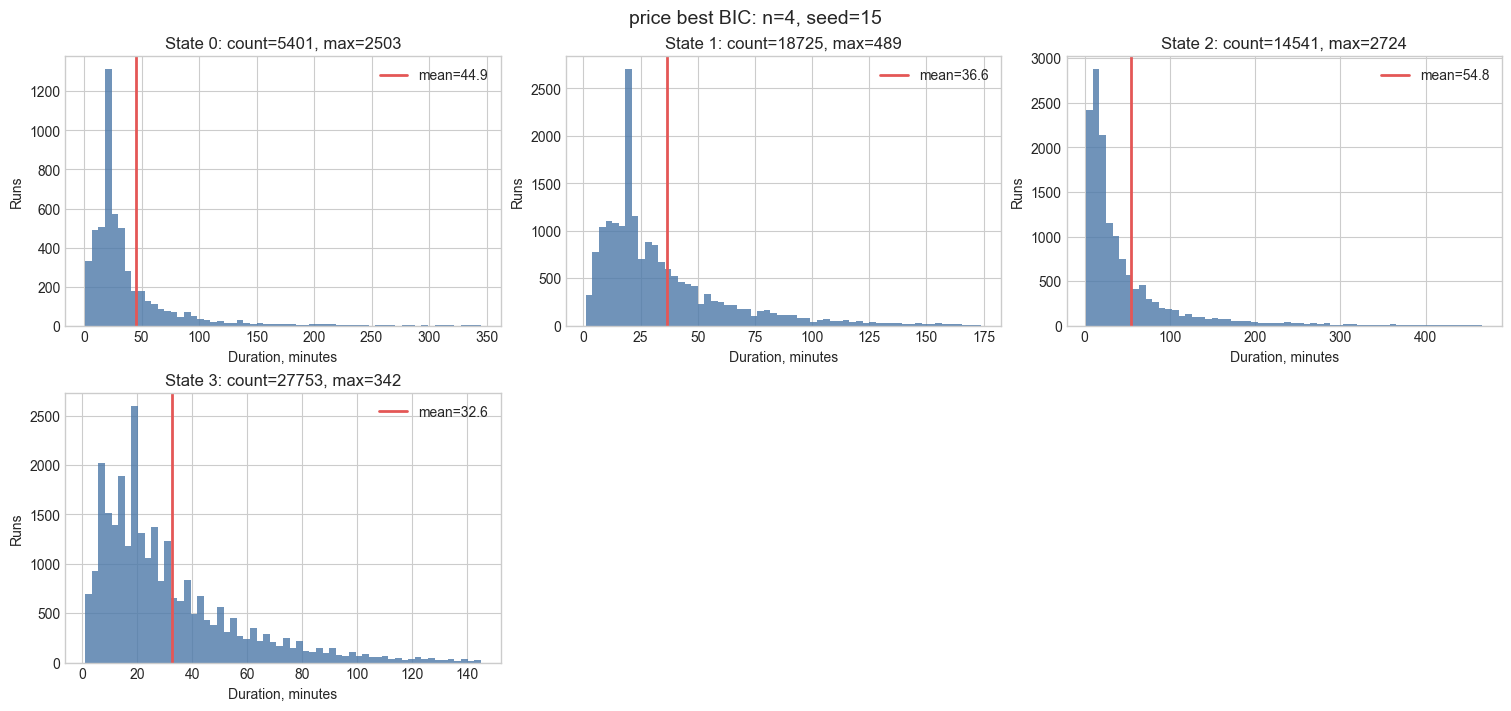

n_components = 5


,model_group,n_components,random_state,bic,aic,log_likelihood
17,flow,5,11,-1.377915e+07,-1.378074e+07,6.890494e+06
63,market,5,9,1.909379e+07,1.909221e+07,-9.545979e+06
106,price,5,12,2.050312e+07,2.050153e+07,-1.025064e+07


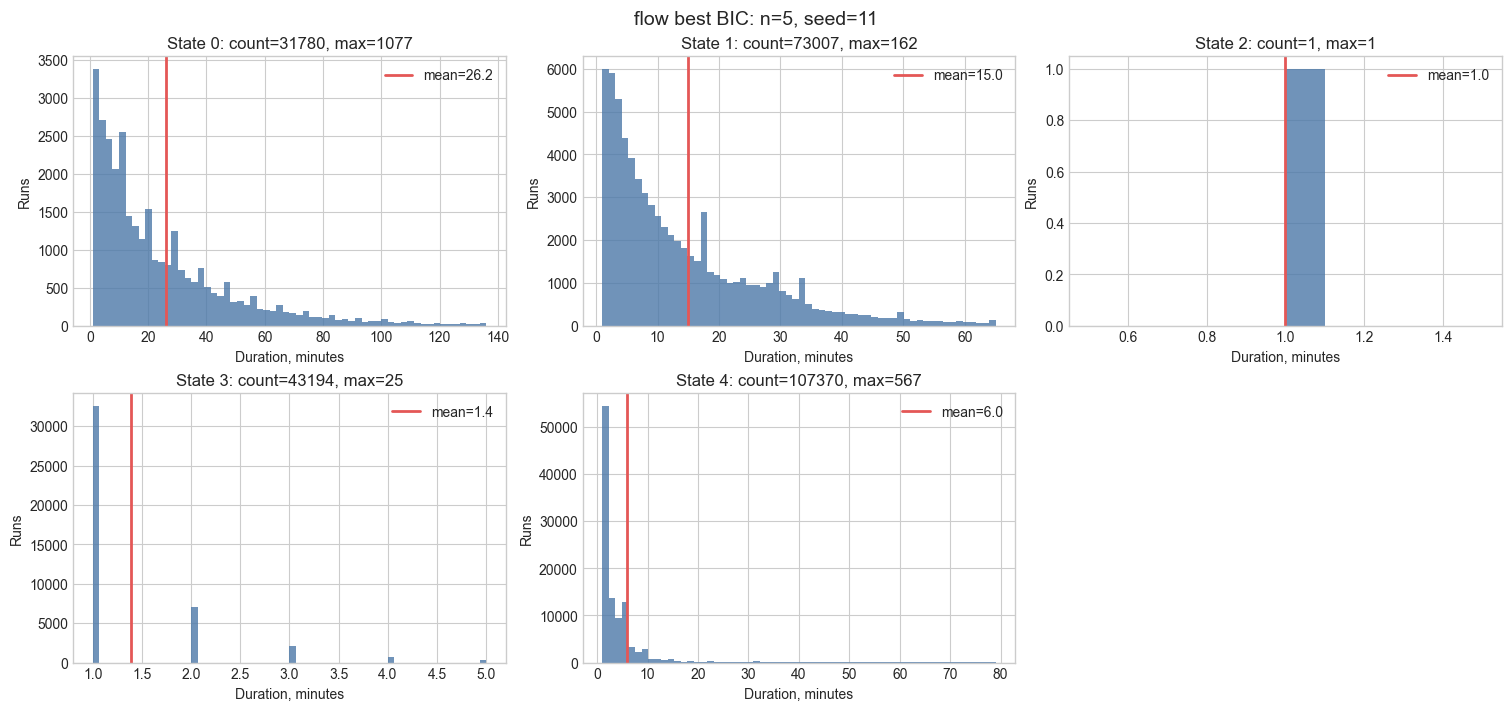

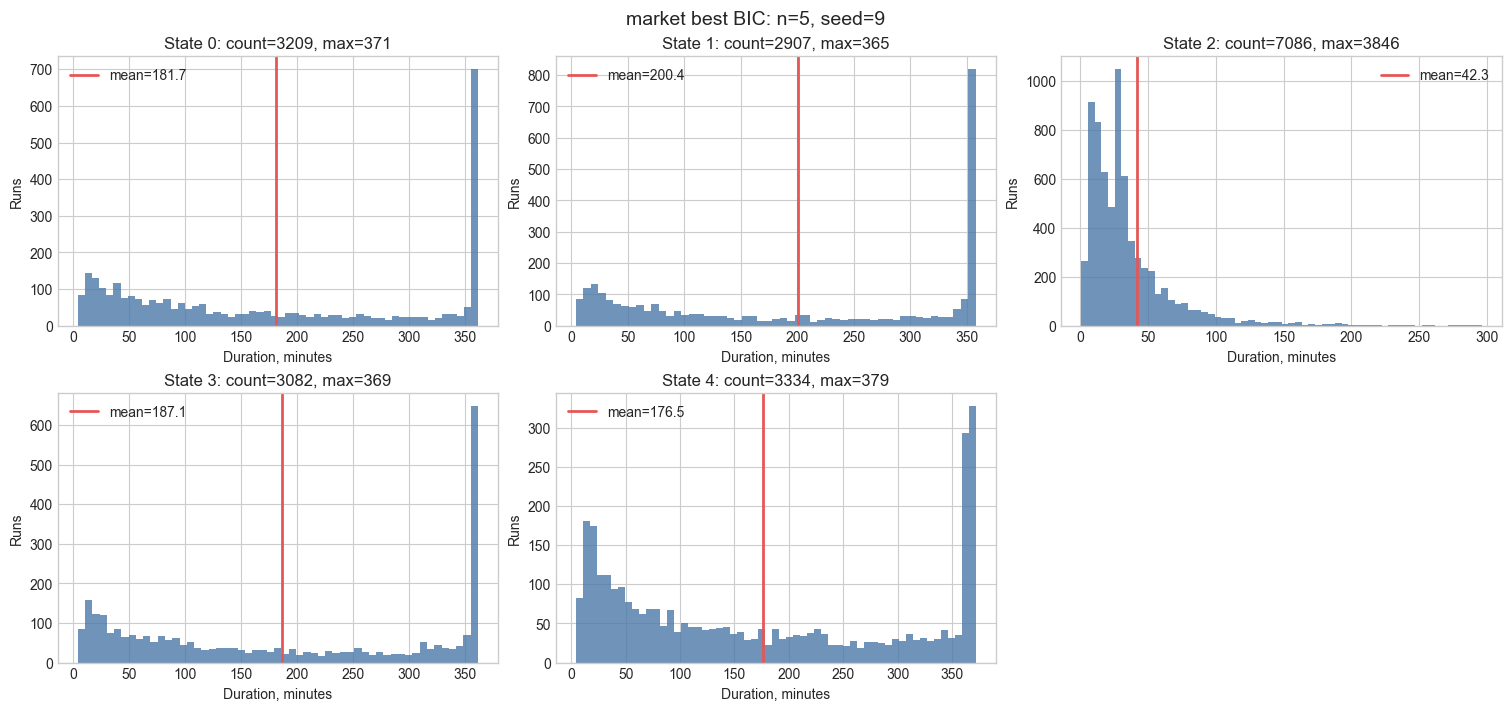

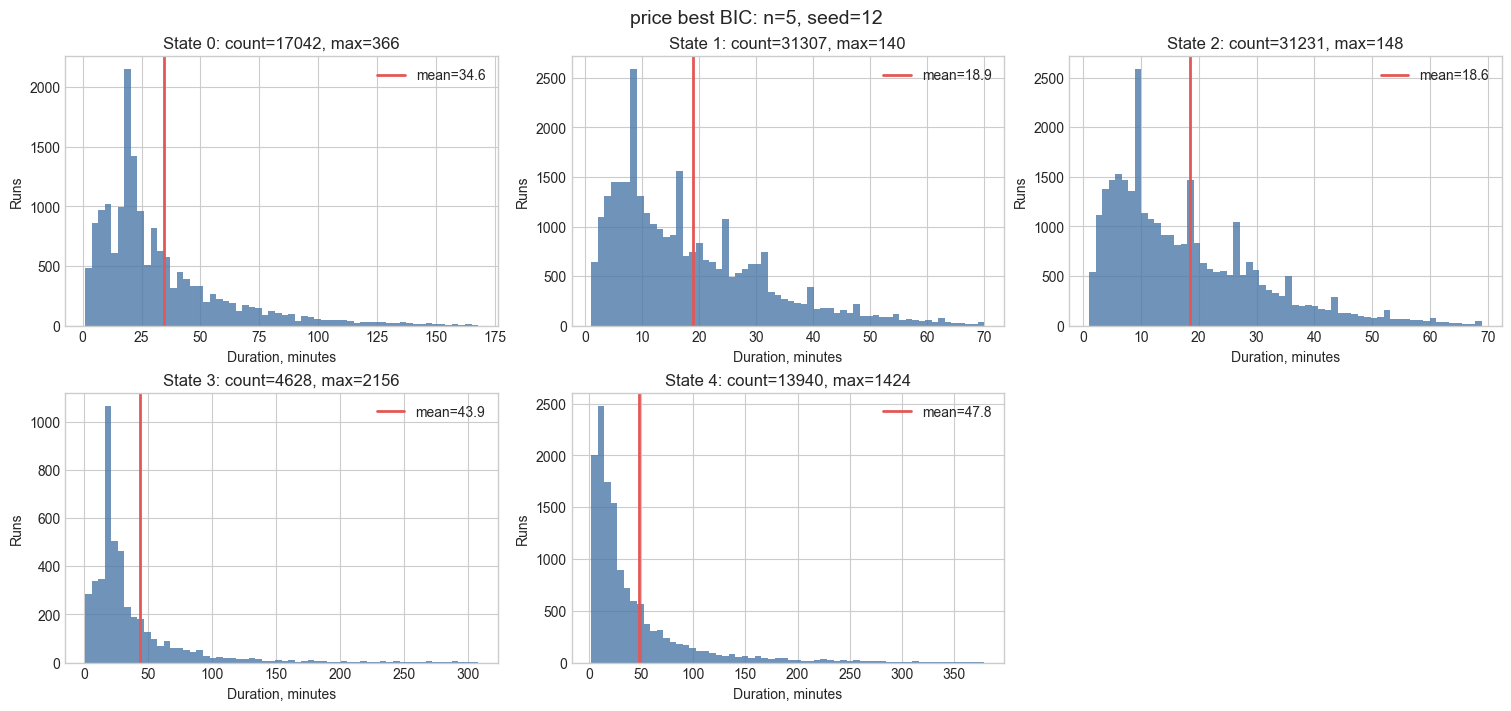

n_components = 6


,model_group,n_components,random_state,bic,aic,log_likelihood
21,flow,6,9,-1.580150e+07,-1.580348e+07,7.901896e+06
67,market,6,8,1.613647e+07,1.613448e+07,-8.067087e+06
113,price,6,16,1.950320e+07,1.950122e+07,-9.750454e+06


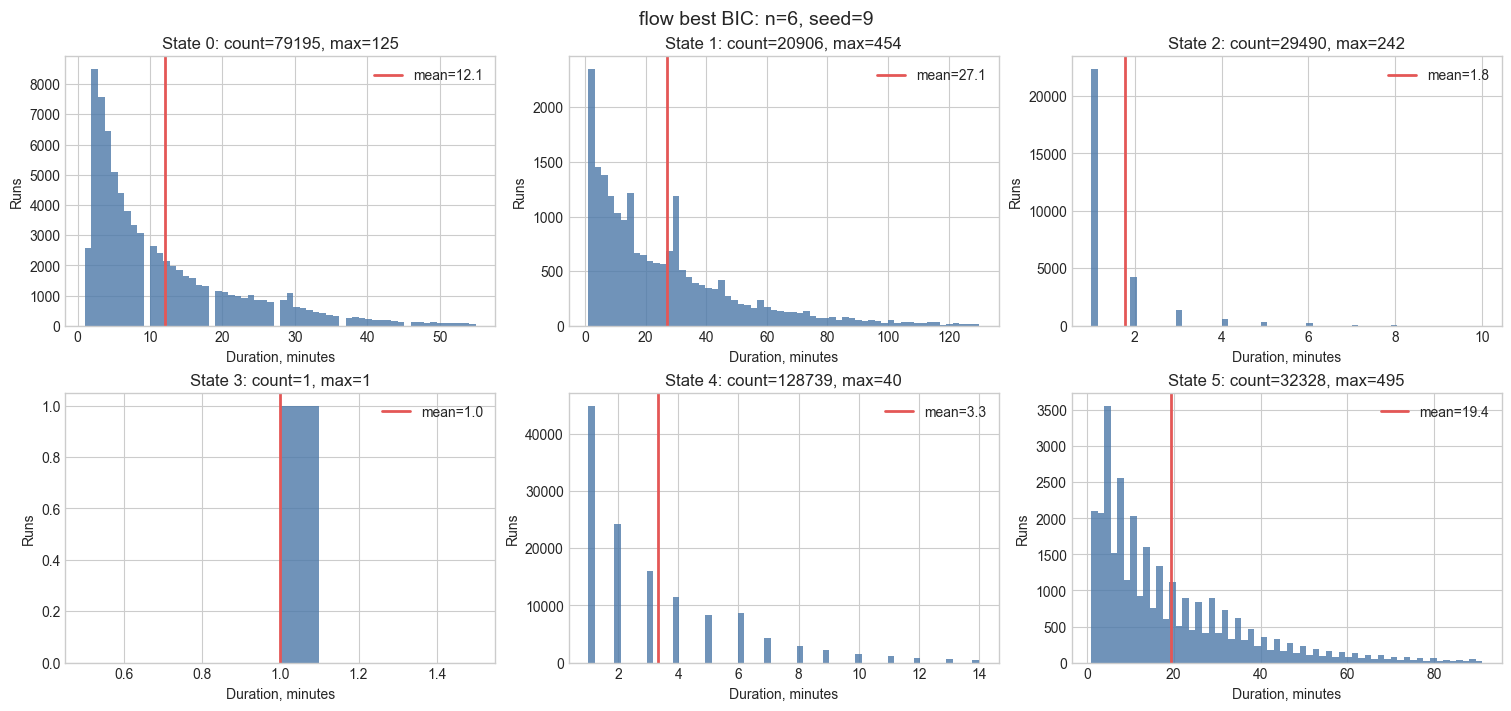

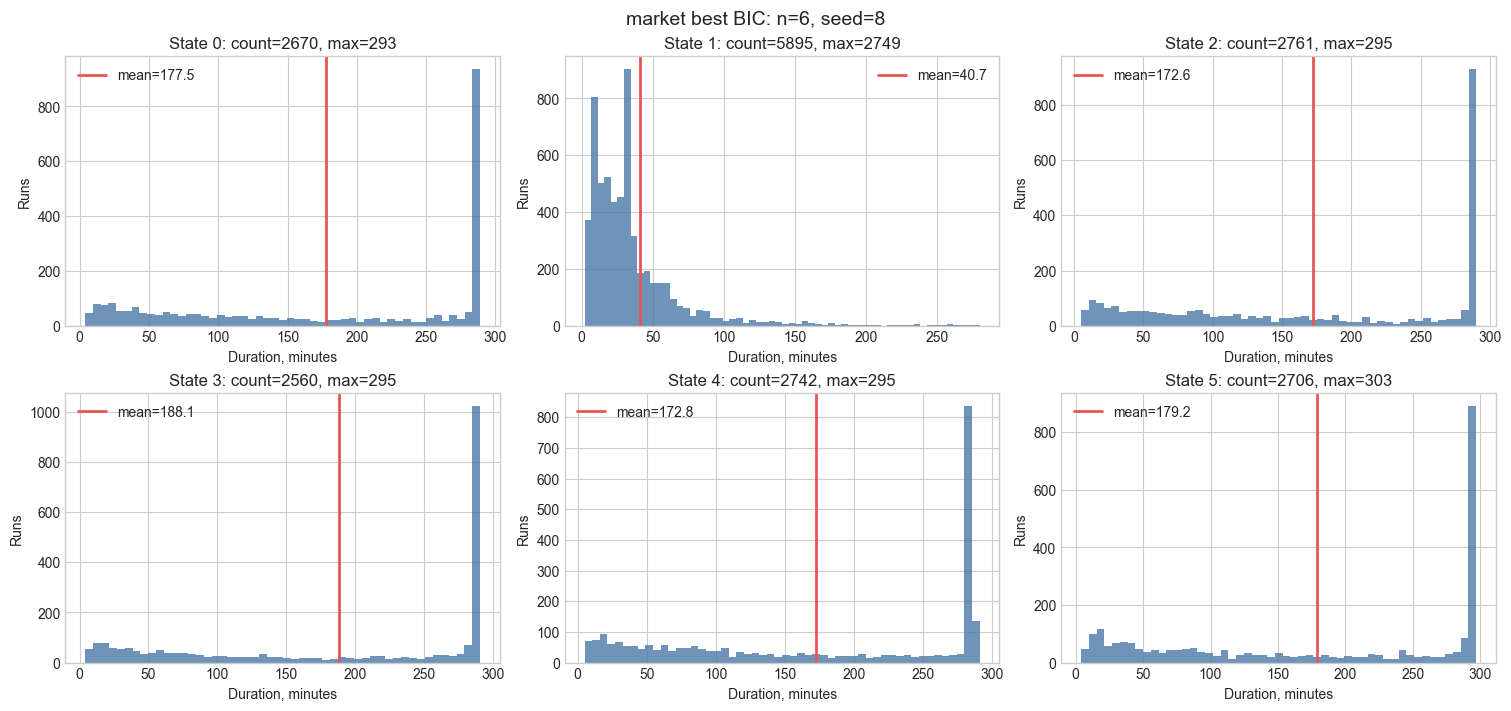

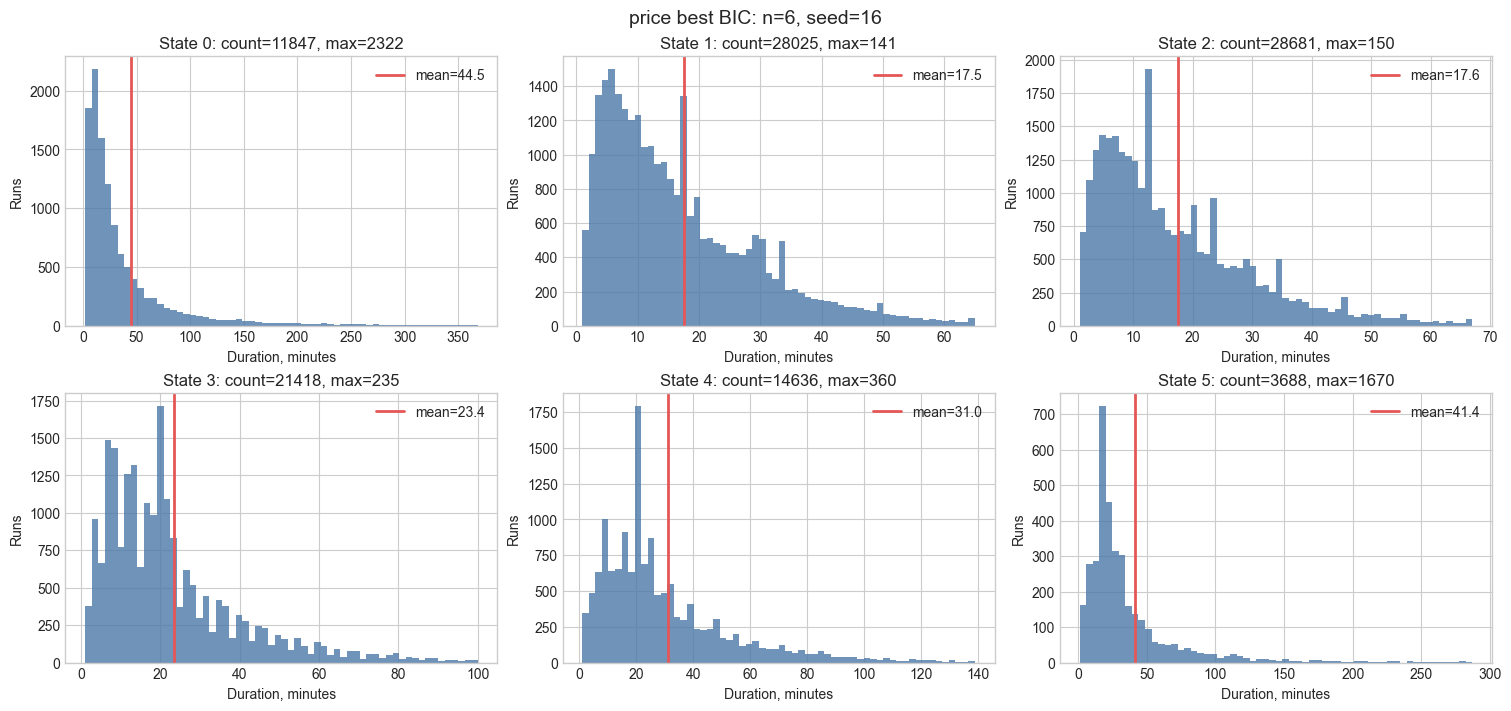

n_components = 7


,model_group,n_components,random_state,bic,aic,log_likelihood
27,flow,7,11,-1.730335e+07,-1.730575e+07,8.653065e+06
73,market,7,9,1.613618e+07,1.613378e+07,-8.066702e+06
115,price,7,1,1.874546e+07,1.874306e+07,-9.371343e+06


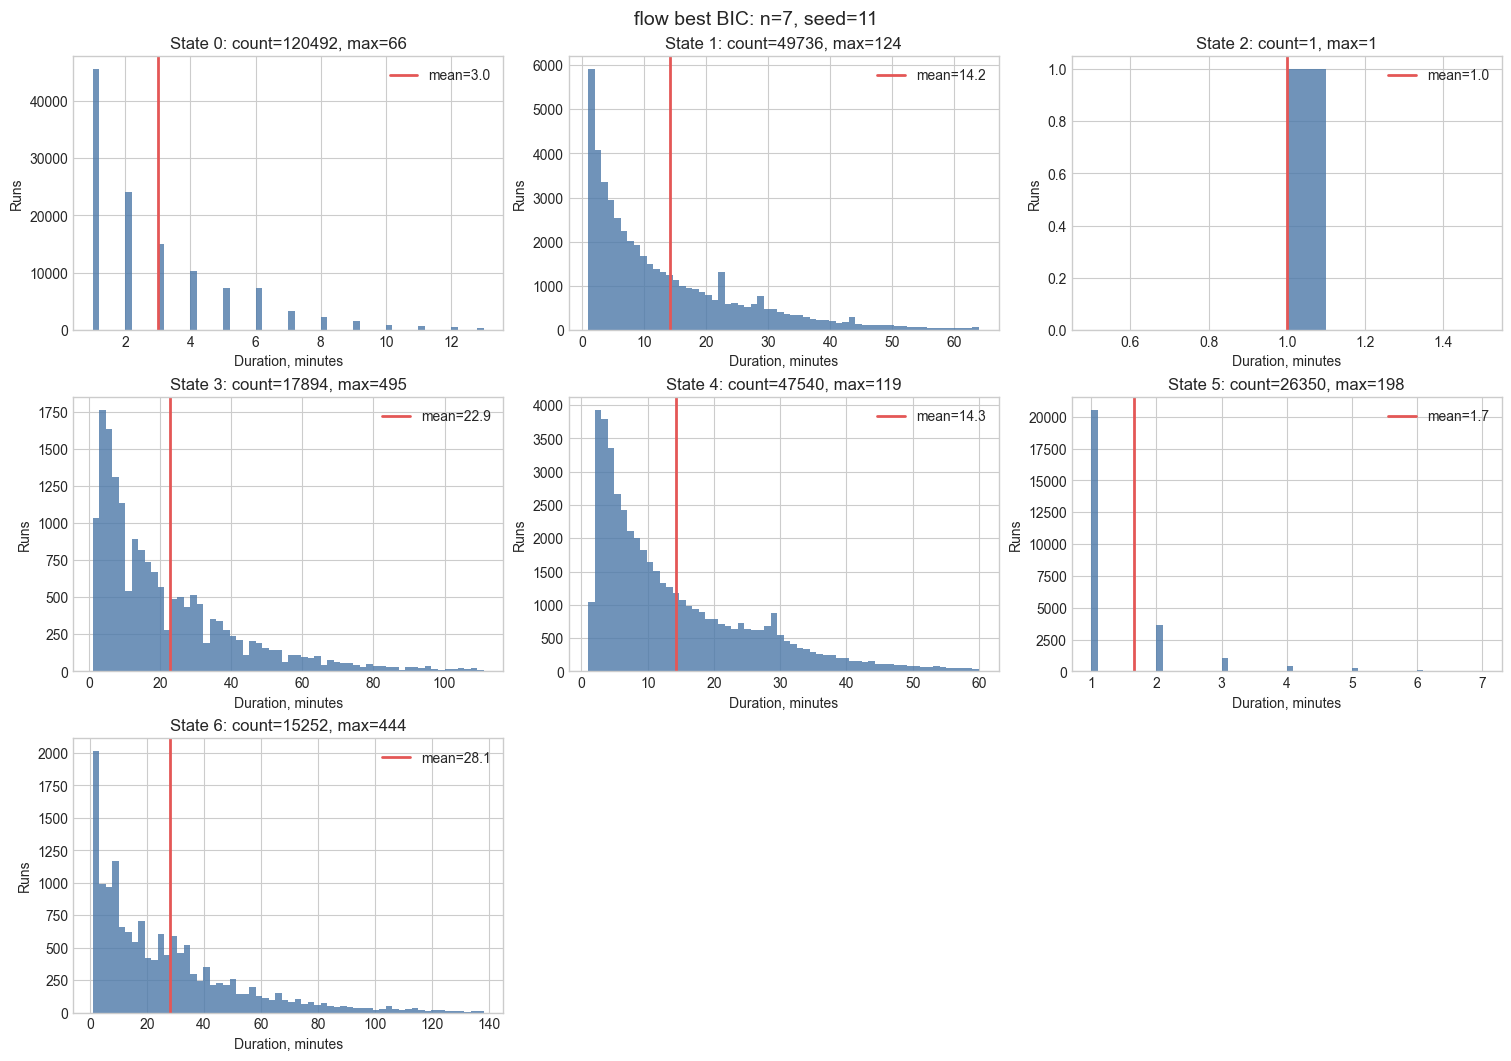

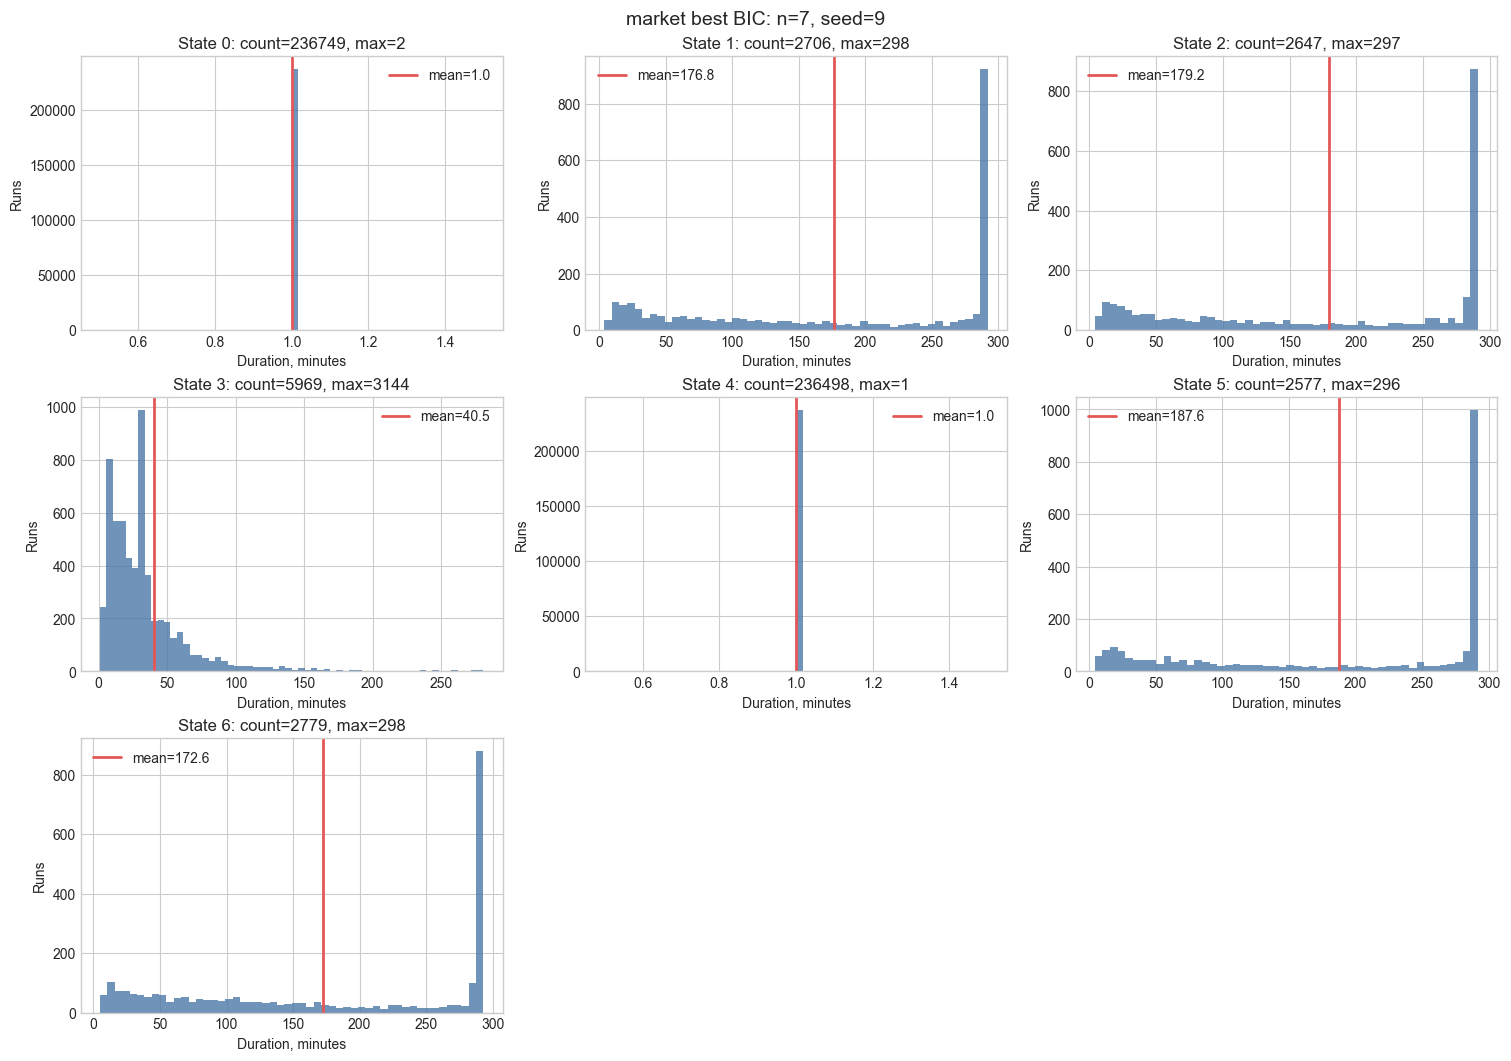

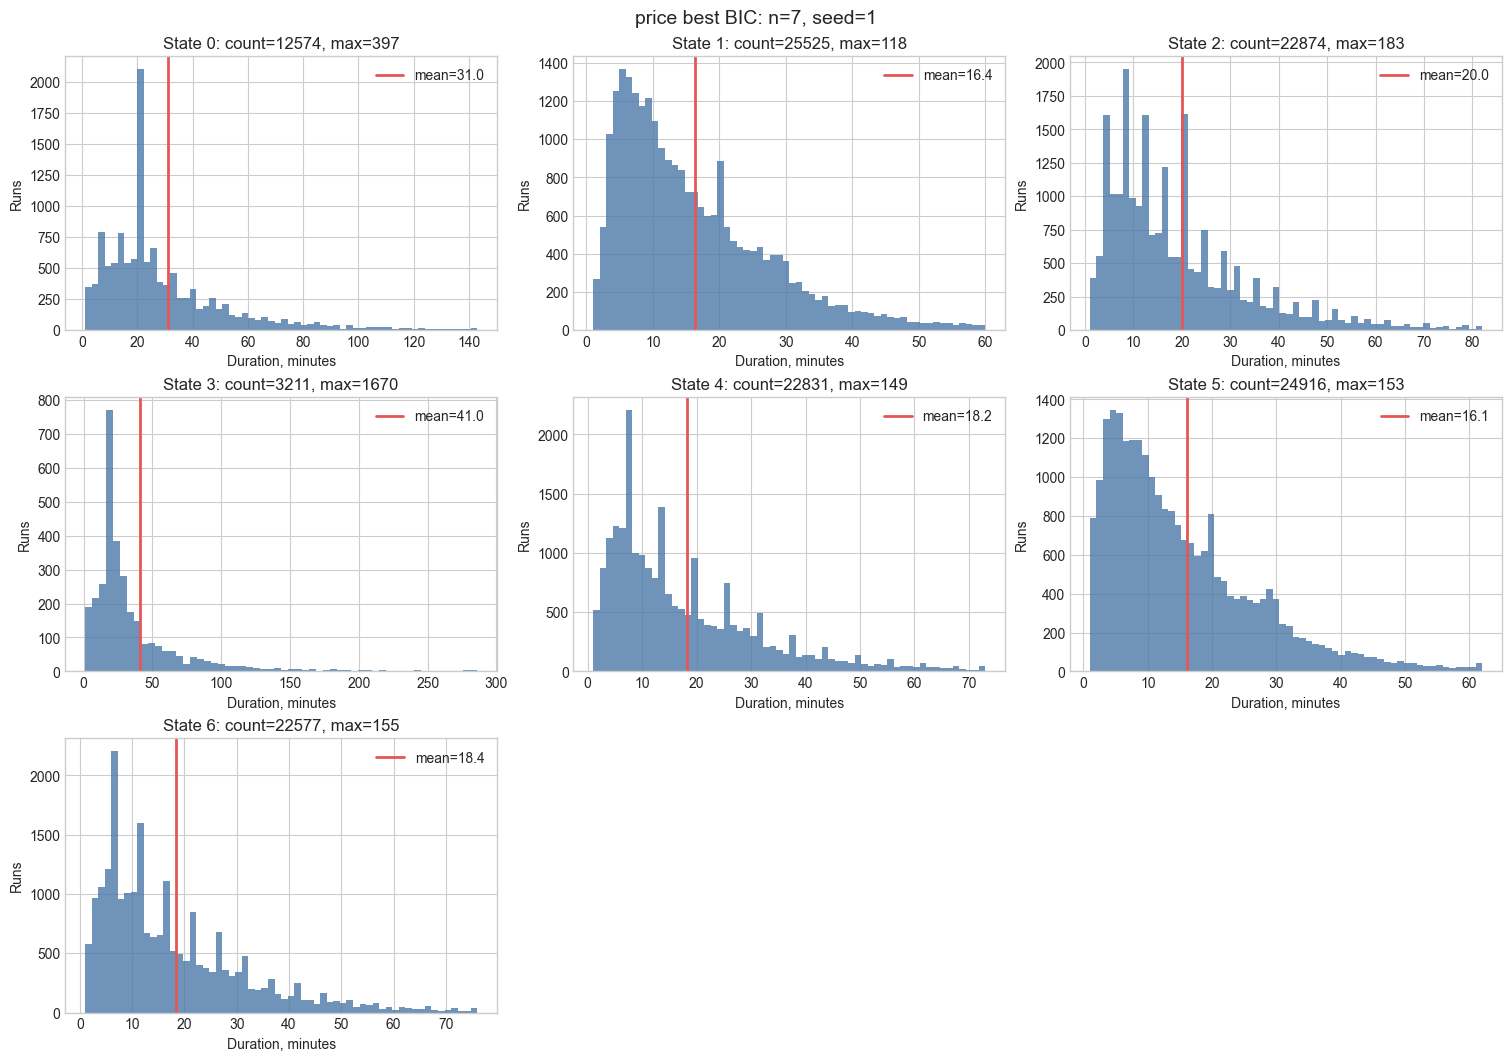

n_components = 8


,model_group,n_components,random_state,bic,aic,log_likelihood
30,flow,8,0,-1.838996e+07,-1.839281e+07,9.196630e+06
78,market,8,9,1.308379e+07,1.308094e+07,-6.540246e+06
122,price,8,15,1.815625e+07,1.815340e+07,-9.076475e+06


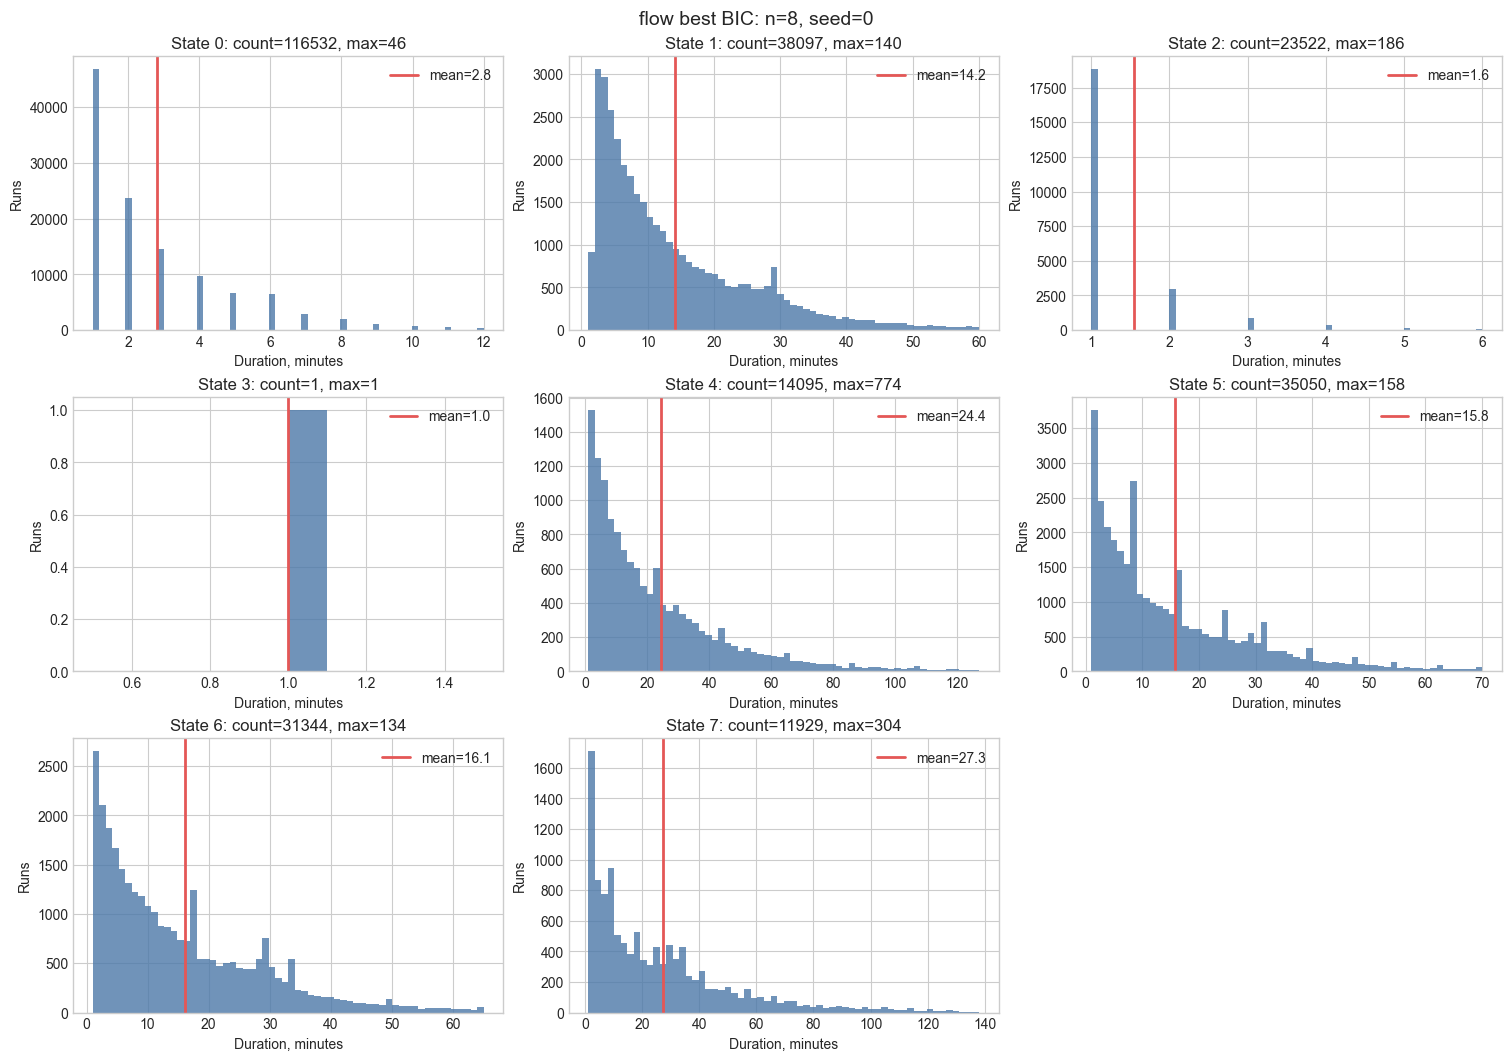

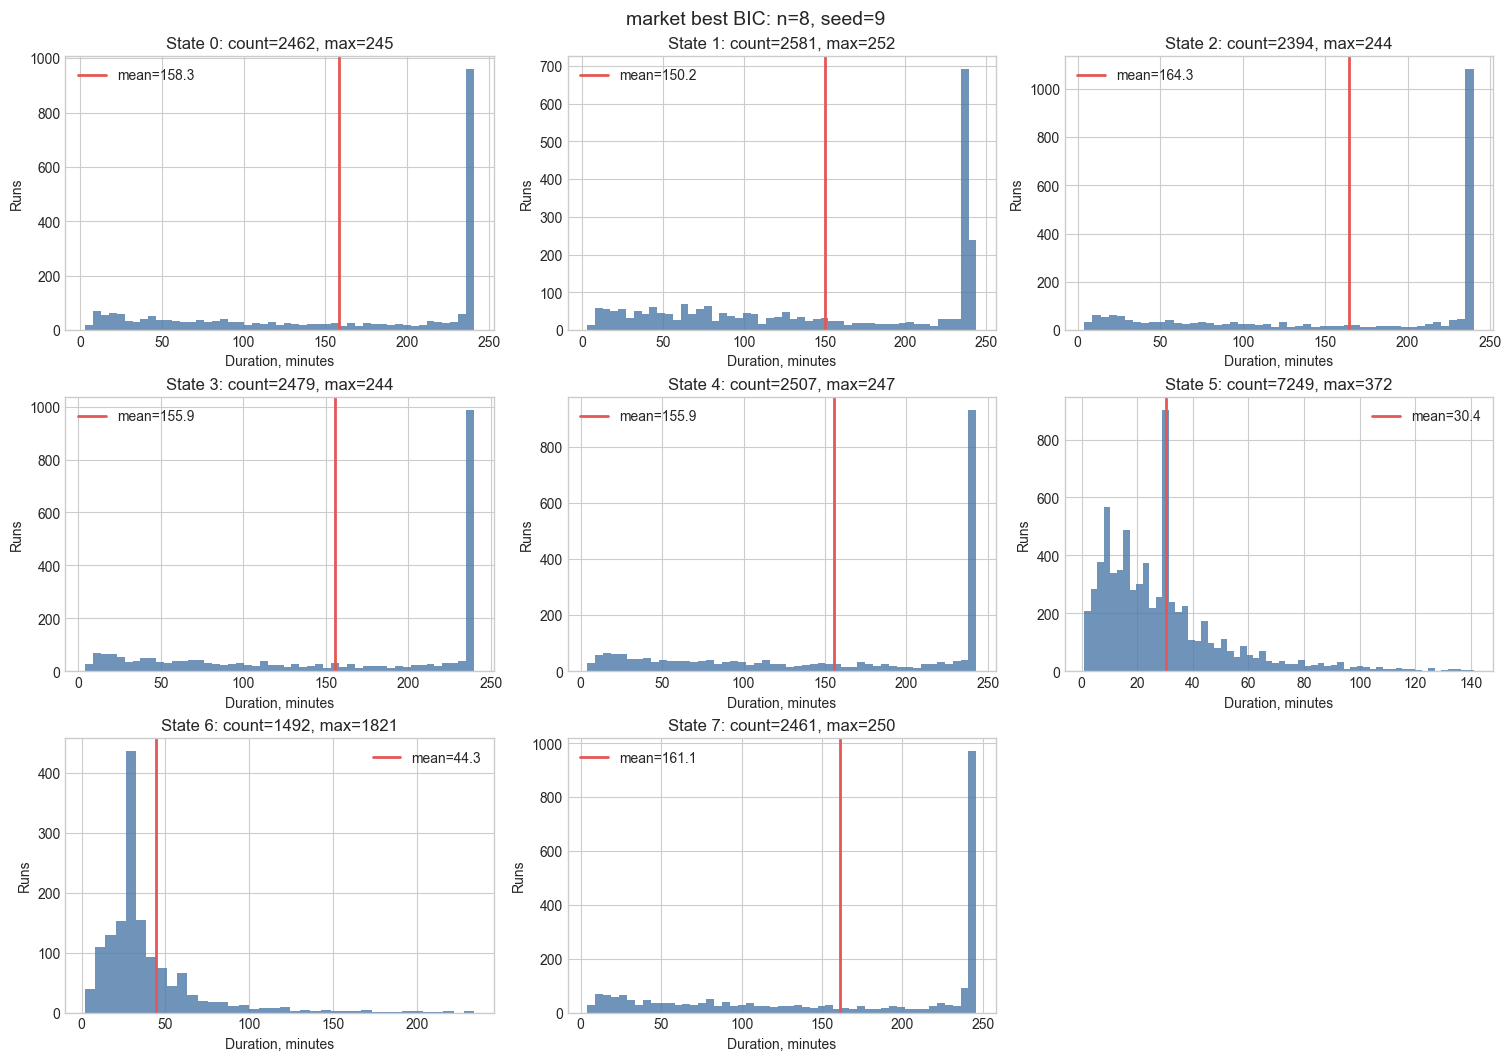

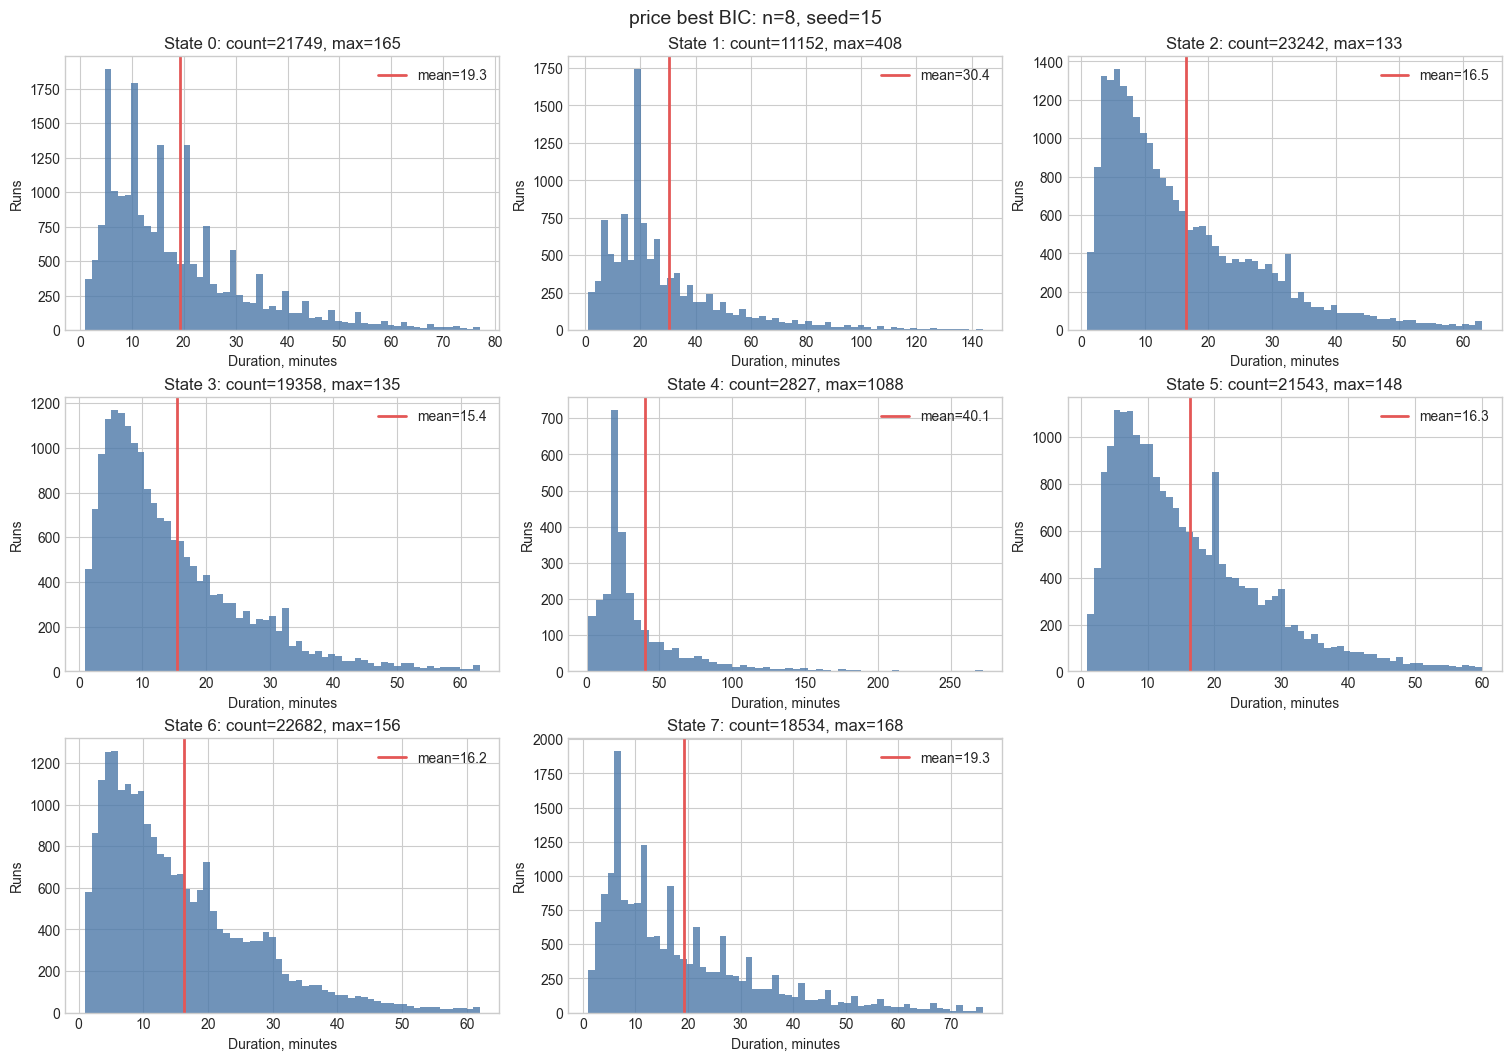

n_components = 9


,model_group,n_components,random_state,bic,aic,log_likelihood
35,flow,9,0,-1.922299e+07,-1.922631e+07,9.613416e+06
82,market,9,8,1.143542e+07,1.143210e+07,-5.715790e+06
129,price,9,19,1.757054e+07,1.756721e+07,-8.783347e+06


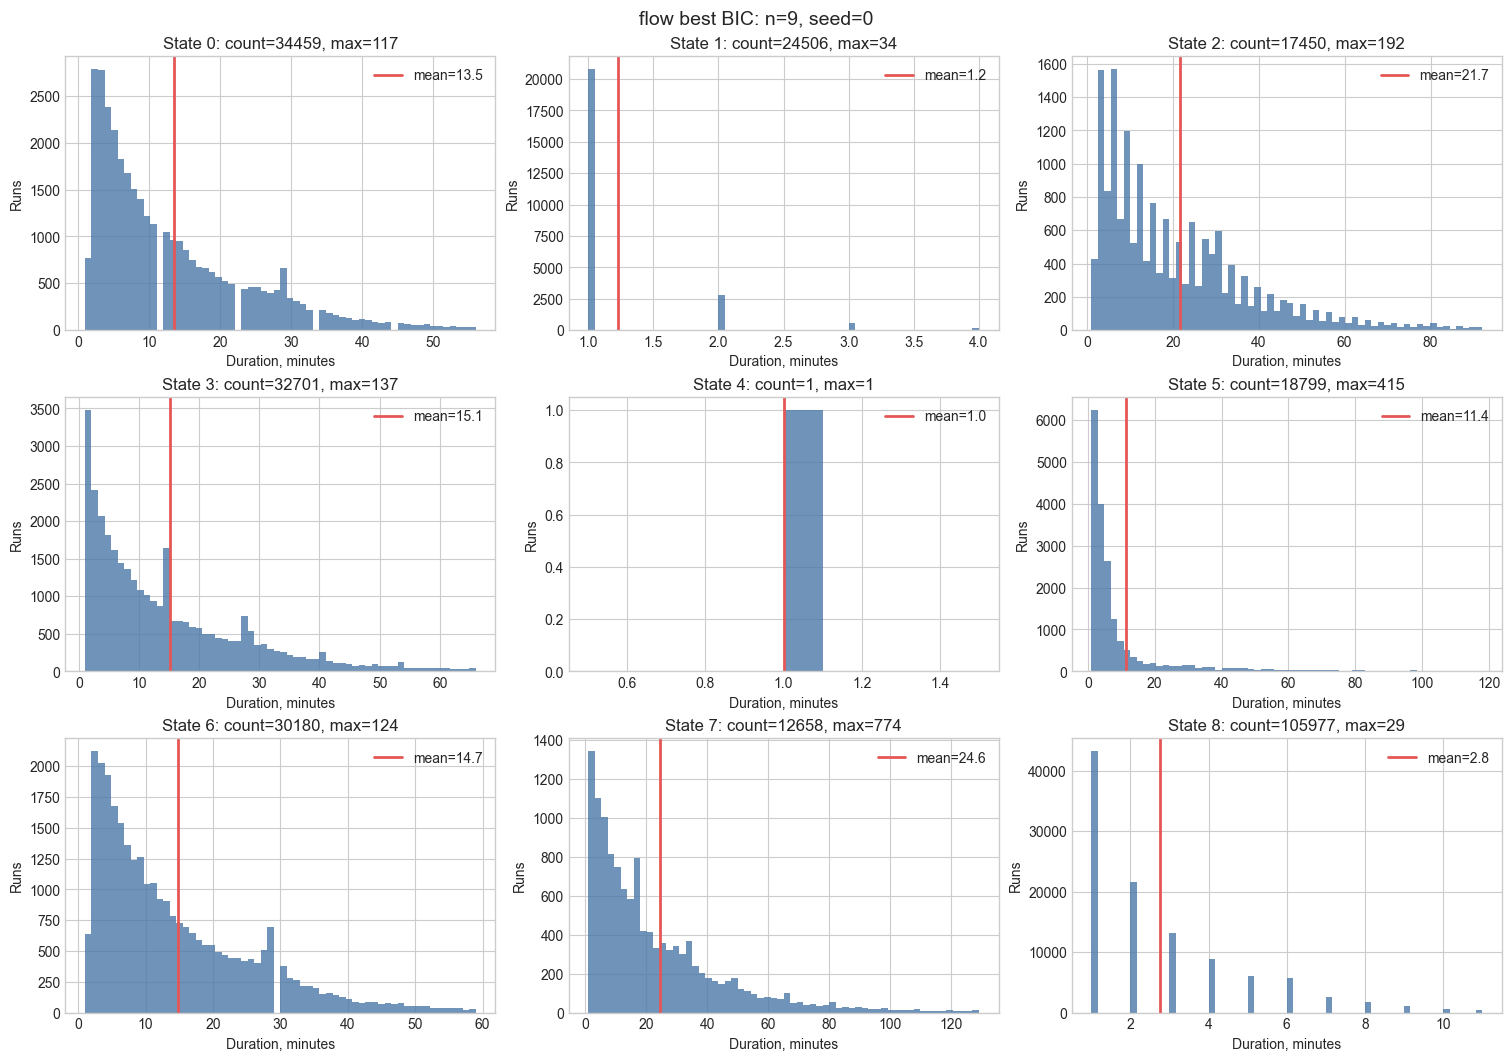

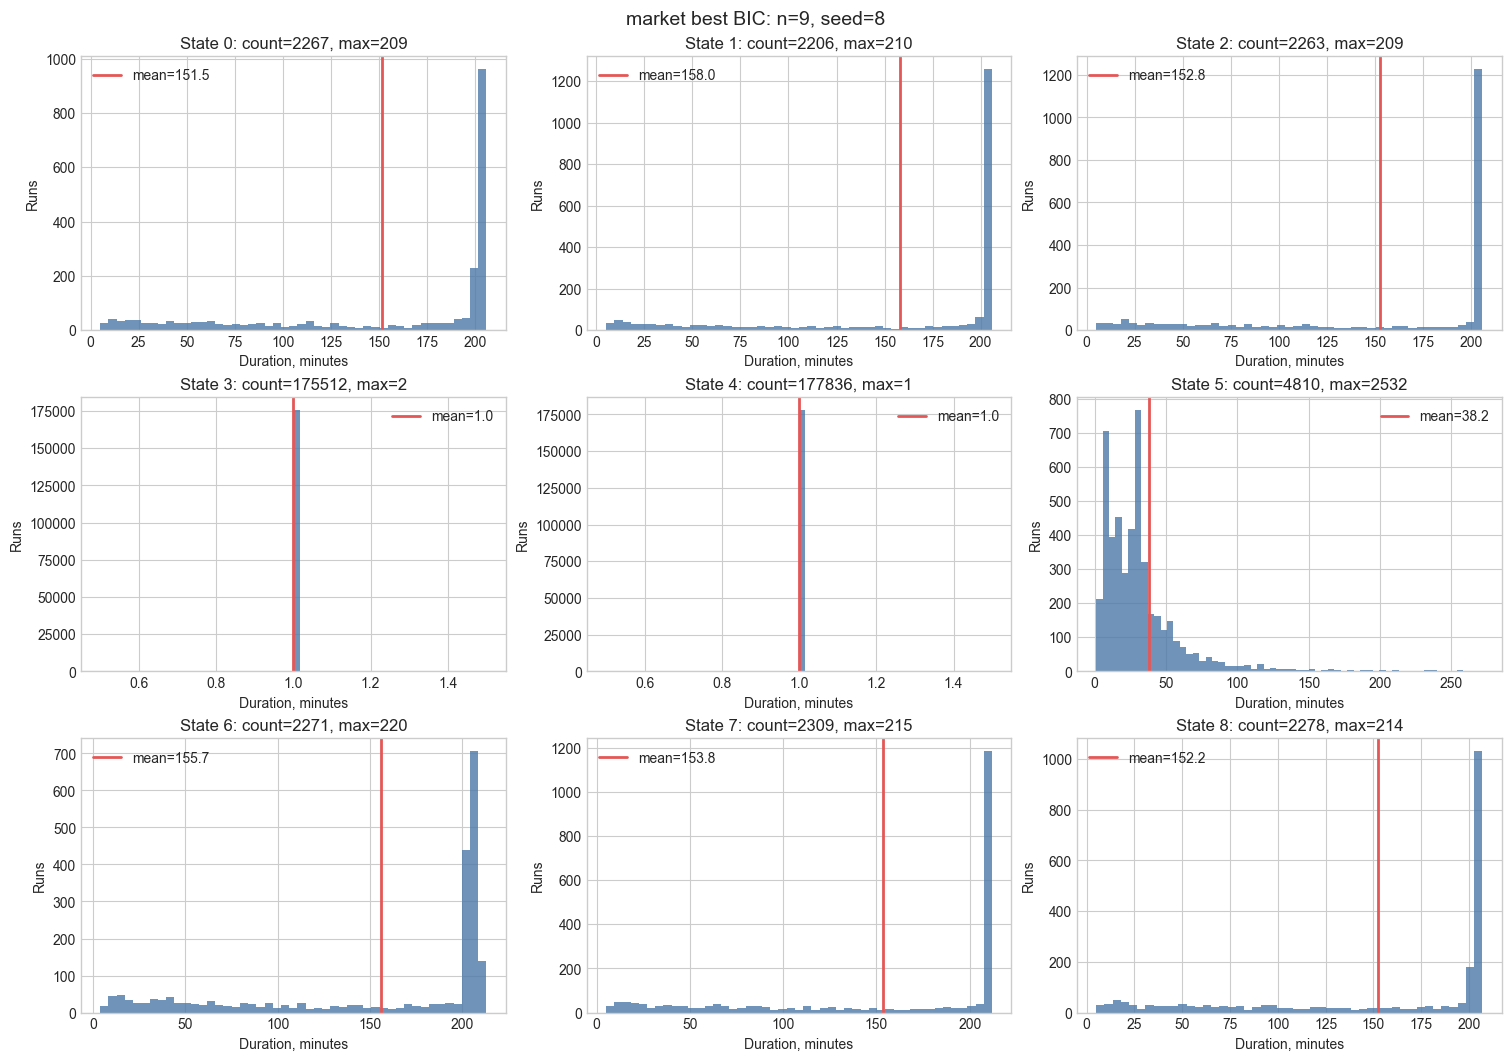

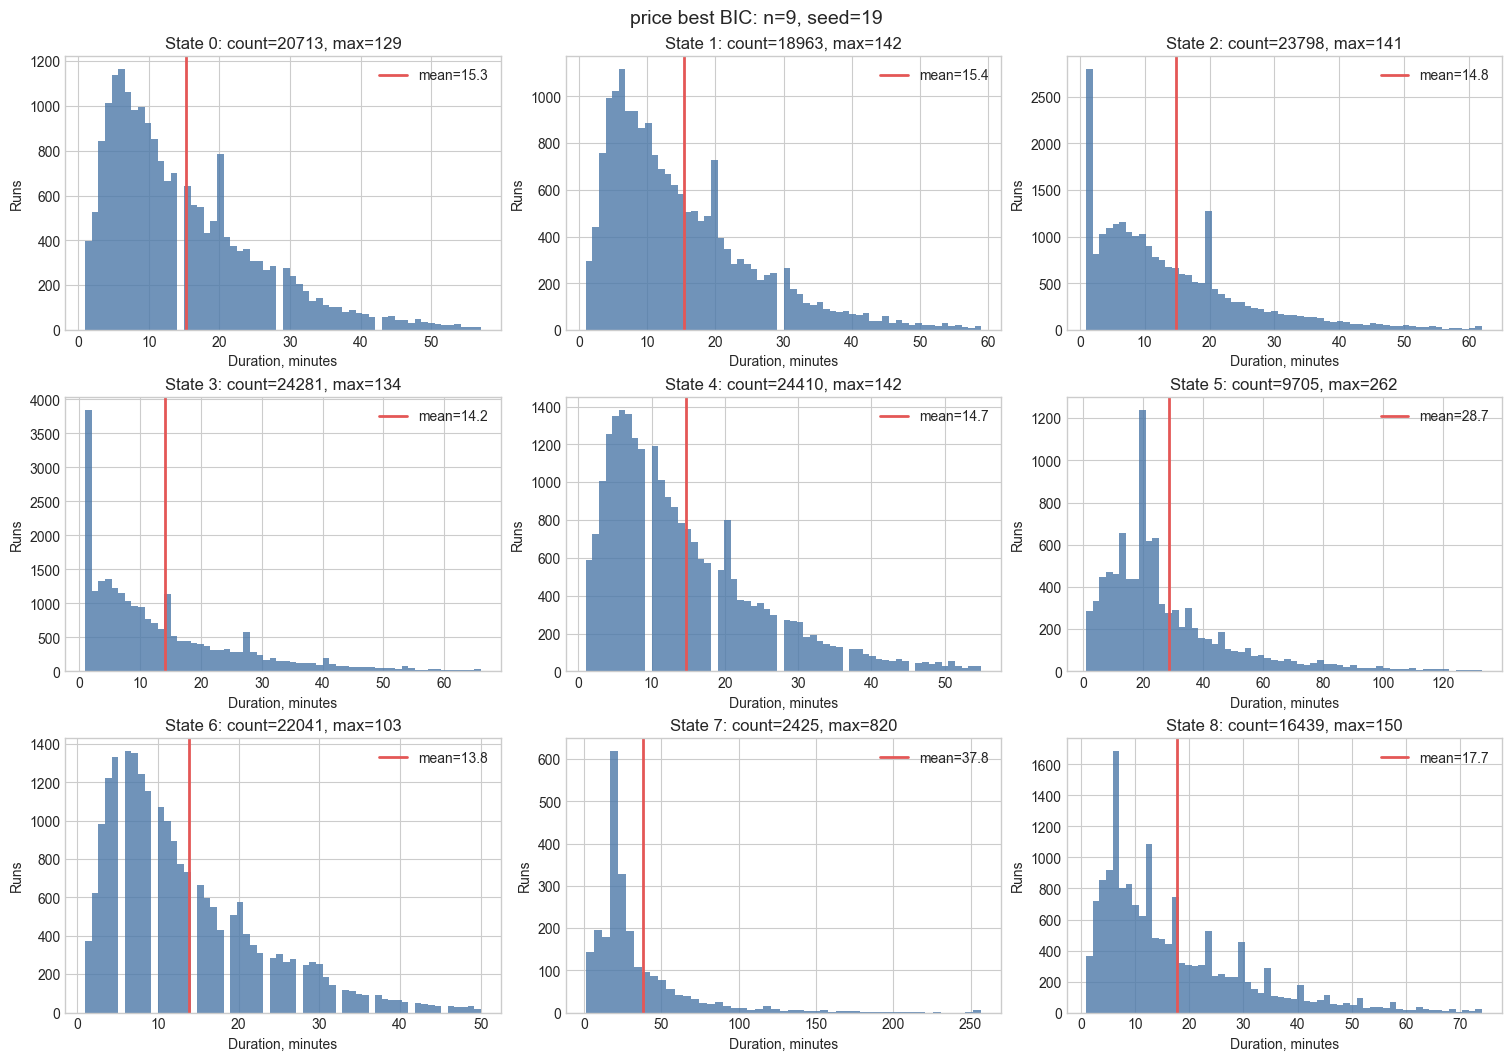

n_components = 10


,model_group,n_components,random_state,bic,aic,log_likelihood
43,flow,10,15,-1.988329e+07,-1.988712e+07,9.943857e+06
89,market,10,14,1.068067e+07,1.067685e+07,-5.338127e+06
133,price,10,16,1.702541e+07,1.702159e+07,-8.510495e+06


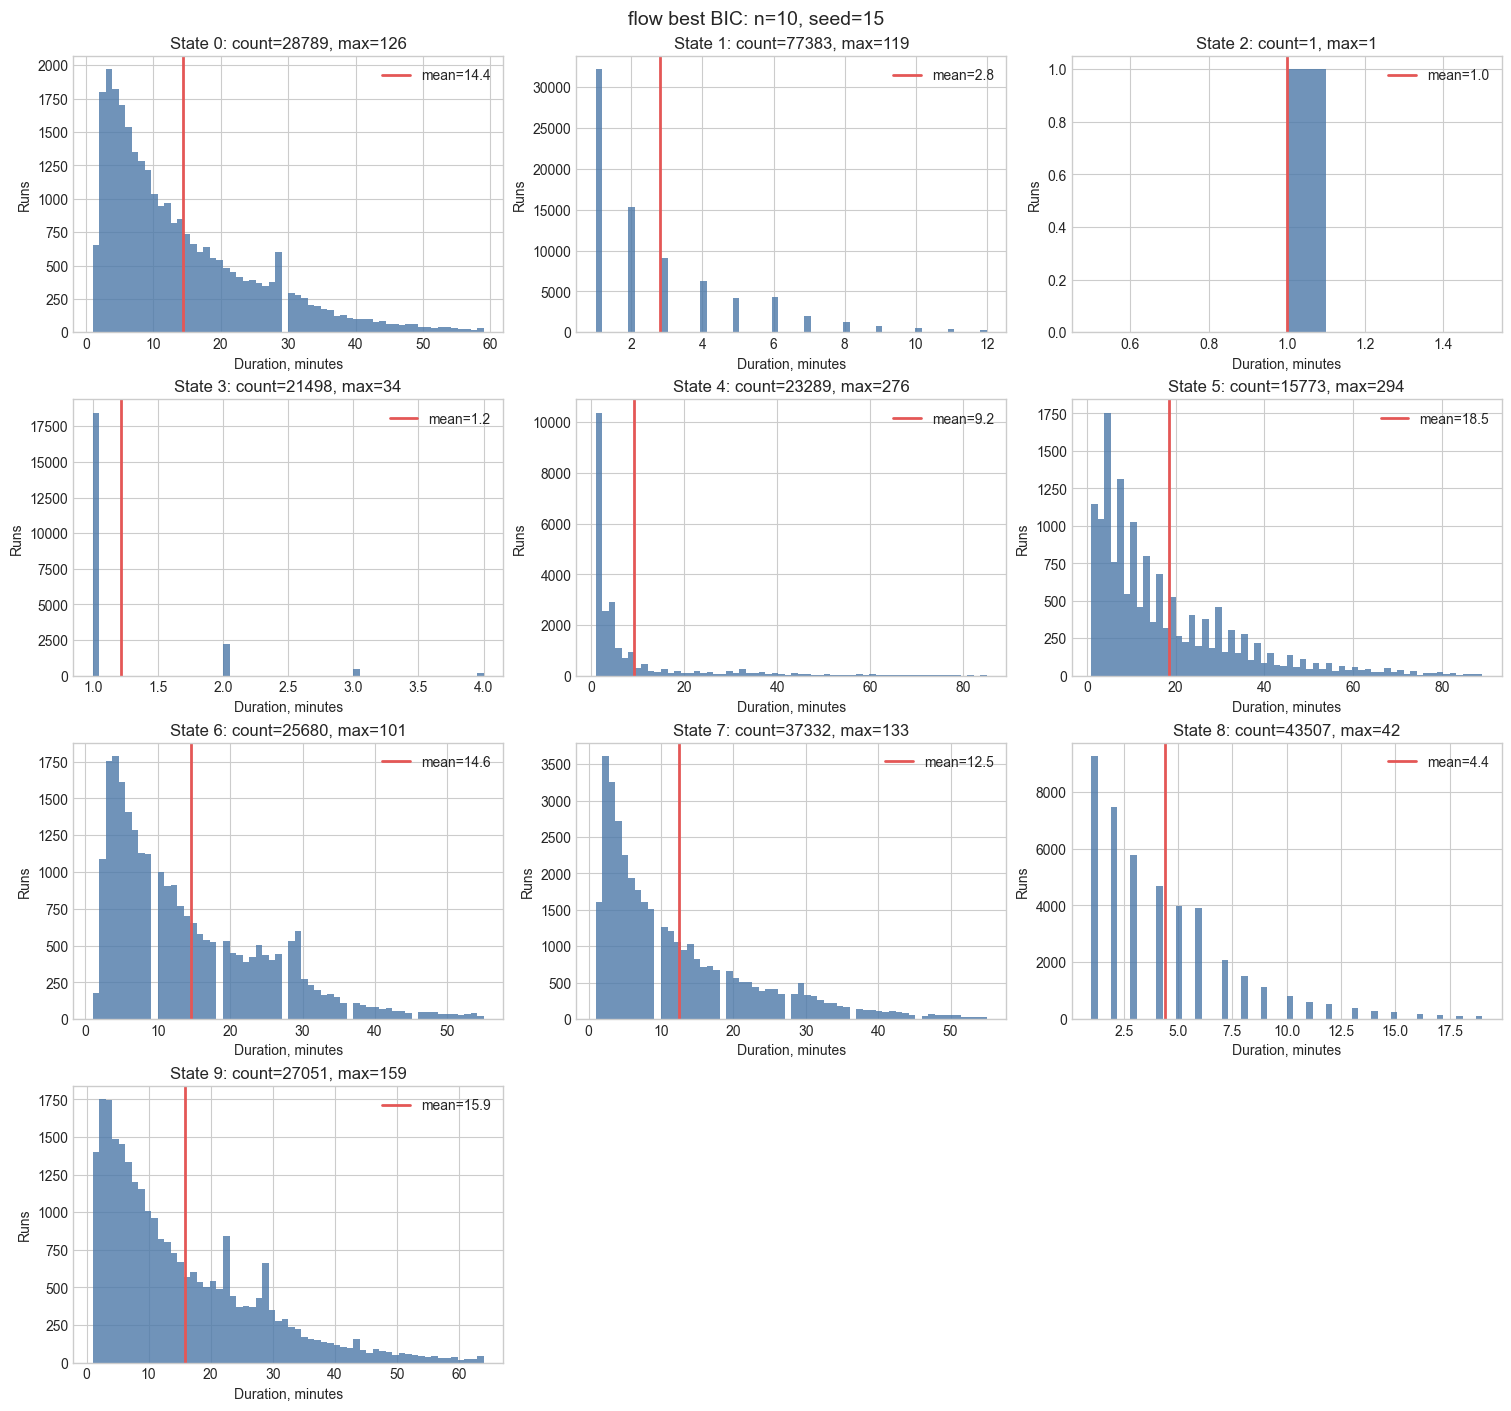

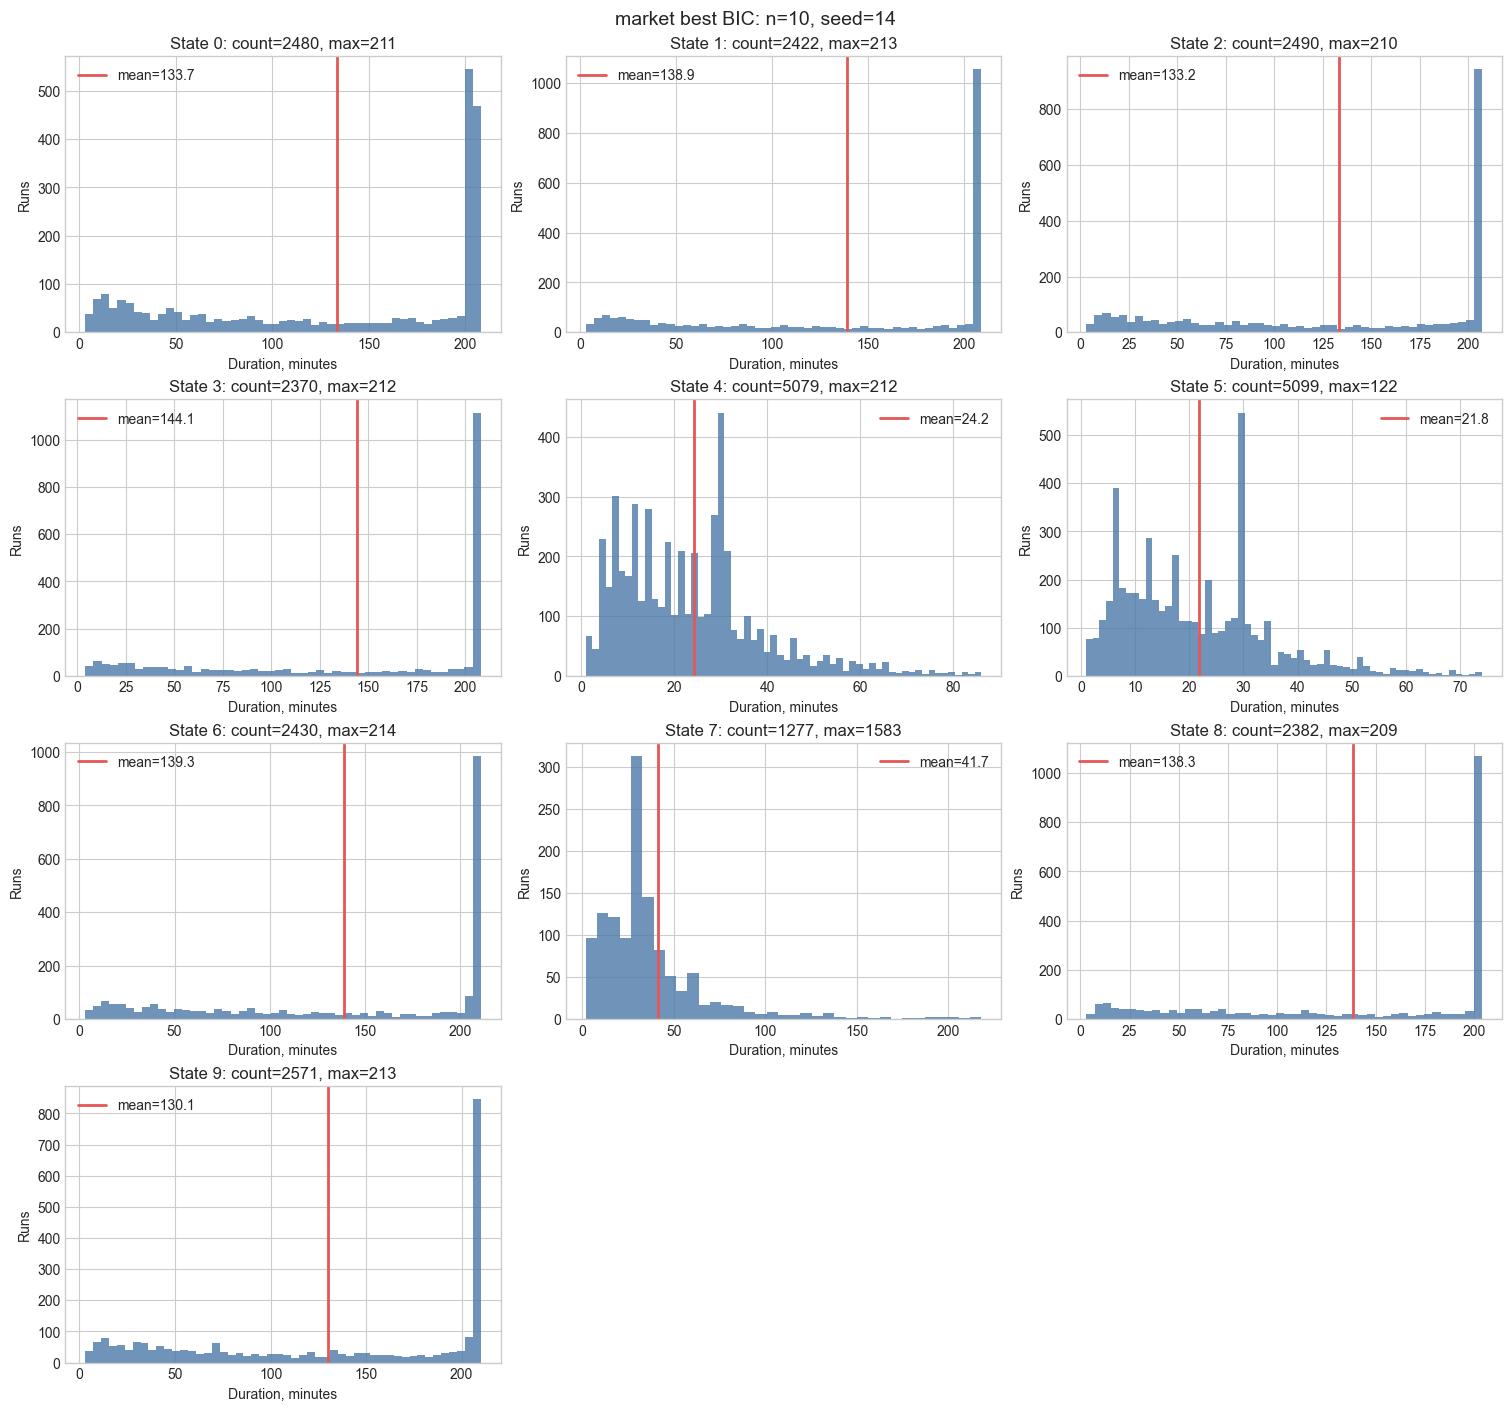

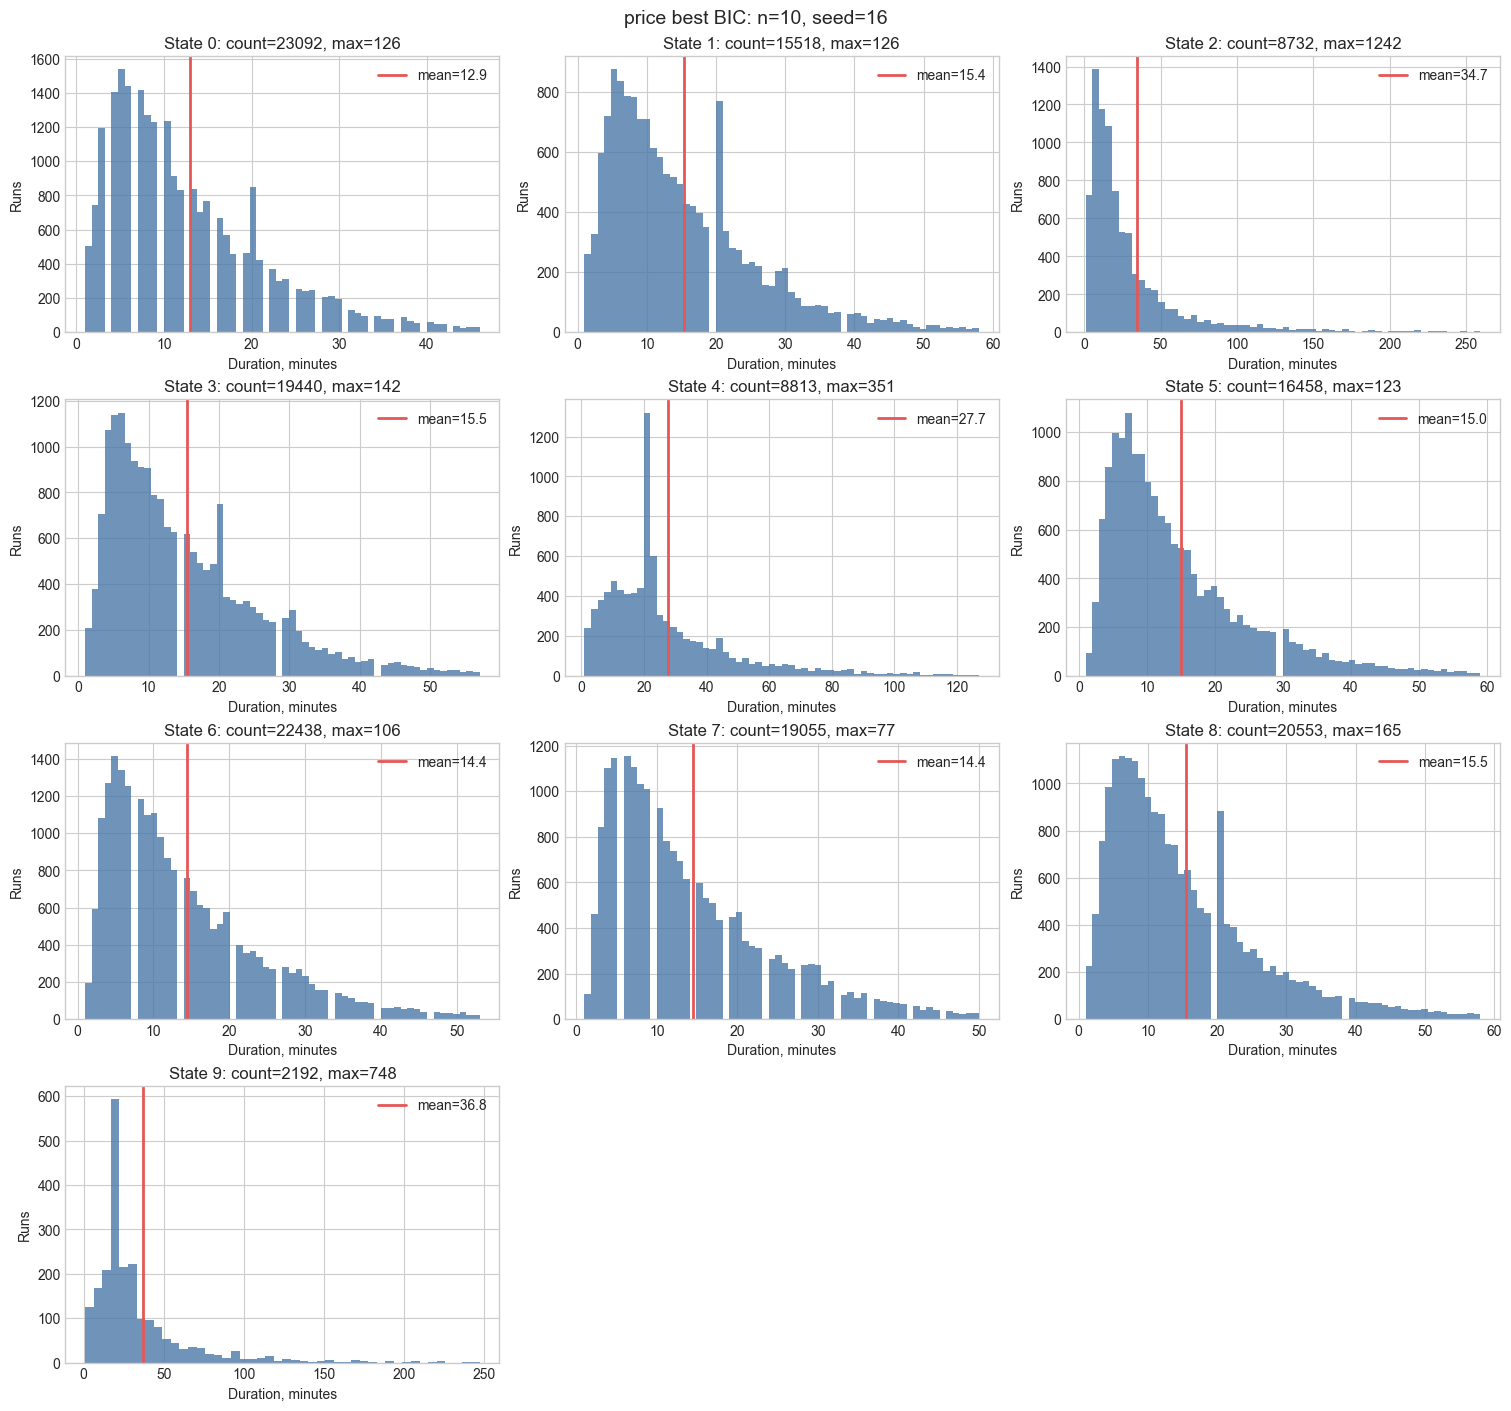

In [22]:
for n in sorted(successful["n_components"].unique()):
    rows_to_plot = (
        successful[successful["n_components"].eq(n)]
        .sort_values("bic", ascending=True)
        .groupby("model_group", as_index=False)
        .head(1)
        .sort_values("model_group")
    )

    print(f"n_components = {n}")
    display(rows_to_plot[["model_group", "n_components", "random_state", "bic", "aic", "log_likelihood"]])

    for _, row in rows_to_plot.iterrows():
        plot_duration_distribution(row)

In [23]:
MODEL_GROUP_TO_CHECK = "flow"  # "price", "flow", "market"
DEGENERATE_SCORE_WEIGHTS = {
    "low_occupancy": 1.0,
    "short_median": 1.0,
    "low_self_transition": 1.0,
}

def suspicious_state_for_row(row: pd.Series) -> dict:
    durations_by_state = parse_json(row["state_duration_distribution"])
    occupancy = parse_array(row["state_occupancy"])
    transition_matrix = parse_array(row["transition_matrix"])

    candidates = []

    for state_id, durations in enumerate(durations_by_state):
        values = np.asarray(durations, dtype="float64")

        if len(values) == 0:
            candidates.append(
                {
                    "state": state_id,
                    "occupancy": occupancy[state_id],
                    "runs": 0,
                    "mean": np.nan,
                    "p50": np.nan,
                    "p90": np.nan,
                    "max": np.nan,
                    "self_transition": transition_matrix[state_id, state_id],
                    "degenerate_score": np.inf,
                }
            )
            continue

        p50 = np.quantile(values, 0.50)
        p90 = np.quantile(values, 0.90)
        mean = values.mean()
        self_transition = transition_matrix[state_id, state_id]

        # Чем score меньше, тем state подозрительнее.
        # Низкая occupancy, короткая медиана и низкий self-transition тянут score вниз.
        score = (
            DEGENERATE_SCORE_WEIGHTS["low_occupancy"] * occupancy[state_id]
            + DEGENERATE_SCORE_WEIGHTS["short_median"] * (p50 / 100.0)
            + DEGENERATE_SCORE_WEIGHTS["low_self_transition"] * self_transition
        )

        candidates.append(
            {
                "state": state_id,
                "occupancy": occupancy[state_id],
                "runs": len(values),
                "mean": mean,
                "p50": p50,
                "p90": p90,
                "p95": np.quantile(values, 0.95),
                "p99": np.quantile(values, 0.99),
                "max": values.max(),
                "self_transition": self_transition,
                "degenerate_score": score,
            }
        )

    return (
        pd.DataFrame(candidates)
        .sort_values(
            ["occupancy", "p50", "self_transition"],
            ascending=[True, True, True],
        )
        .iloc[0]
        .to_dict()
    )


rows = []

for n in sorted(successful["n_components"].unique()):
    row = (
        successful[
            successful["model_group"].eq(MODEL_GROUP_TO_CHECK)
            & successful["n_components"].eq(n)
        ]
        .sort_values("bic", ascending=True)
        .iloc[0]
    )

    suspicious = suspicious_state_for_row(row)

    rows.append(
        {
            "model_group": row["model_group"],
            "n_components": int(row["n_components"]),
            "random_state": int(row["random_state"]),
            "bic": row["bic"],
            "aic": row["aic"],
            "log_likelihood": row["log_likelihood"],
            **suspicious,
        }
    )

degenerate_by_n = pd.DataFrame(rows)
degenerate_by_n

,model_group,n_components,random_state,bic,aic,log_likelihood,state,occupancy,runs,mean,p50,p90,p95,p99,max,self_transition,degenerate_score
0,flow,2,16,-5.137057e+06,-5.137607e+06,2.568846e+06,0.0,7.153761e-02,72128.0,2.609167,1.0,4.0,5.0,29.0,761.0,0.615542,0.69708
1,flow,3,16,-5.920654e+06,-5.921523e+06,2.960830e+06,2.0,3.801270e-07,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,0.000000,0.01000
2,flow,4,9,-1.079302e+07,-1.079424e+07,5.397213e+06,2.0,3.801270e-07,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,0.000000,0.01000
3,flow,5,11,-1.377915e+07,-1.378074e+07,6.890494e+06,2.0,3.801270e-07,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,0.000000,0.01000
4,flow,6,9,-1.580150e+07,-1.580348e+07,7.901896e+06,3.0,3.801270e-07,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,0.000000,0.01000
5,flow,7,11,-1.730335e+07,-1.730575e+07,8.653065e+06,2.0,3.801270e-07,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,0.000000,0.01000
6,flow,8,0,-1.838996e+07,-1.839281e+07,9.196630e+06,3.0,3.801270e-07,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,0.000000,0.01000
7,flow,9,0,-1.922299e+07,-1.922631e+07,9.613416e+06,4.0,3.801270e-07,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,0.000000,0.01000
8,flow,10,15,-1.988329e+07,-1.988712e+07,9.943857e+06,2.0,3.801270e-07,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,0.000000,0.01000


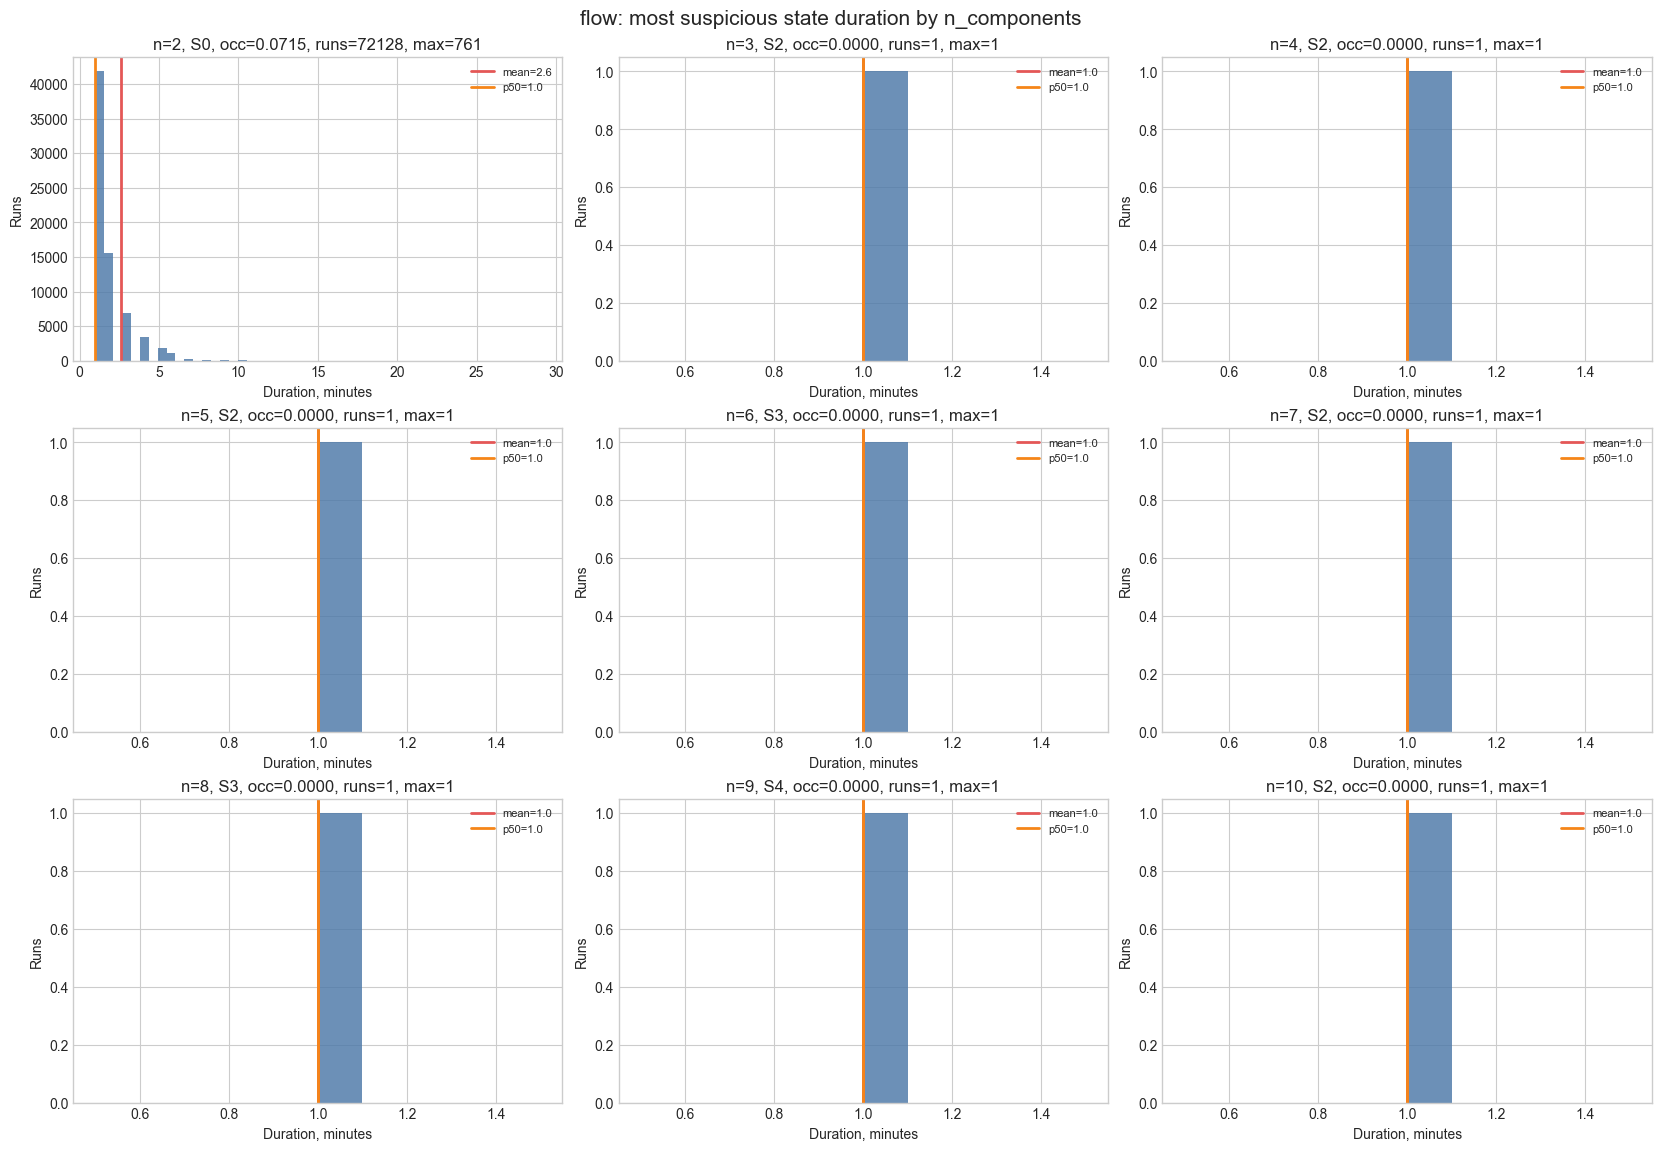

In [24]:
def plot_one_state_duration(row: pd.Series, state_id: int, axis, max_duration_quantile: float = 0.99):
    durations_by_state = parse_json(row["state_duration_distribution"])
    values = np.asarray(durations_by_state[state_id], dtype="float64")

    if len(values) == 0:
        axis.set_title(f"n={int(row['n_components'])}, state={state_id}: empty")
        axis.set_axis_off()
        return

    upper = max(1, np.quantile(values, max_duration_quantile))
    clipped = values[values <= upper]

    axis.hist(
        clipped,
        bins=min(50, max(10, int(np.sqrt(len(clipped))))),
        color="#4C78A8",
        alpha=0.82,
    )
    axis.axvline(values.mean(), color="#E45756", linewidth=2, label=f"mean={values.mean():.1f}")
    axis.axvline(np.median(values), color="#F58518", linewidth=2, label=f"p50={np.median(values):.1f}")

    axis.set_title(
        f"n={int(row['n_components'])}, S{state_id}, "
        f"occ={parse_array(row['state_occupancy'])[state_id]:.4f}, "
        f"runs={len(values)}, max={values.max():.0f}"
    )
    axis.set_xlabel("Duration, minutes")
    axis.set_ylabel("Runs")
    axis.legend(fontsize=8)


n_values = sorted(successful["n_components"].unique())
ncols = 3
nrows = int(np.ceil(len(n_values) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.5 * ncols, 3.8 * nrows),
    constrained_layout=True,
    squeeze=False,
)

for plot_idx, n in enumerate(n_values):
    axis = axes[plot_idx // ncols][plot_idx % ncols]

    model_row = (
        successful[
            successful["model_group"].eq(MODEL_GROUP_TO_CHECK)
            & successful["n_components"].eq(n)
        ]
        .sort_values("bic", ascending=True)
        .iloc[0]
    )

    state_id = int(
        degenerate_by_n.loc[
            degenerate_by_n["n_components"].eq(n),
            "state",
        ].iloc[0]
    )

    plot_one_state_duration(model_row, state_id, axis)

for plot_idx in range(len(n_values), nrows * ncols):
    axes[plot_idx // ncols][plot_idx % ncols].set_axis_off()

fig.suptitle(
    f"{MODEL_GROUP_TO_CHECK}: most suspicious state duration by n_components",
    fontsize=15,
)

plt.show()

In [25]:
MODEL_GROUP_TO_CHECK = "flow"  # "price", "flow", "market"

BAD_STATE_RULES = {
    "min_occupancy": 0.01,
    "min_p50_duration": 2.0,
    "min_mean_duration": 3.0,
    "min_self_transition": 0.50,
}

# Лучший seed берём по лучшему BIC среди всех n для выбранной группы.
best_seed_row = (
    successful[successful["model_group"].eq(MODEL_GROUP_TO_CHECK)]
    .sort_values("bic", ascending=True)
    .iloc[0]
)

BEST_SEED = int(best_seed_row["random_state"])

print(
    f"Selected seed for {MODEL_GROUP_TO_CHECK}: {BEST_SEED} "
    f"(best BIC at n={int(best_seed_row['n_components'])}, "
    f"BIC={best_seed_row['bic']:.2f})"
)


def state_health_table(row: pd.Series) -> pd.DataFrame:
    durations_by_state = parse_json(row["state_duration_distribution"])
    occupancy = parse_array(row["state_occupancy"])
    transition_matrix = parse_array(row["transition_matrix"])

    rows = []

    for state_id, durations in enumerate(durations_by_state):
        values = np.asarray(durations, dtype="float64")

        if len(values) == 0:
            mean_duration = np.nan
            p50_duration = np.nan
            p90_duration = np.nan
            max_duration = np.nan
            runs = 0
        else:
            mean_duration = values.mean()
            p50_duration = np.quantile(values, 0.50)
            p90_duration = np.quantile(values, 0.90)
            max_duration = values.max()
            runs = len(values)

        self_transition = transition_matrix[state_id, state_id]

        bad_reasons = []
        if occupancy[state_id] < BAD_STATE_RULES["min_occupancy"]:
            bad_reasons.append("low_occupancy")
        if np.isnan(p50_duration) or p50_duration <= BAD_STATE_RULES["min_p50_duration"]:
            bad_reasons.append("short_p50")
        if np.isnan(mean_duration) or mean_duration <= BAD_STATE_RULES["min_mean_duration"]:
            bad_reasons.append("short_mean")
        if self_transition < BAD_STATE_RULES["min_self_transition"]:
            bad_reasons.append("low_self_transition")

        rows.append(
            {
                "n_components": int(row["n_components"]),
                "random_state": int(row["random_state"]),
                "state": state_id,
                "occupancy": occupancy[state_id],
                "runs": runs,
                "mean_duration": mean_duration,
                "p50_duration": p50_duration,
                "p90_duration": p90_duration,
                "max_duration": max_duration,
                "self_transition": self_transition,
                "is_bad": len(bad_reasons) > 0,
                "bad_reasons": ", ".join(bad_reasons),
                "bic": row["bic"],
                "aic": row["aic"],
                "log_likelihood": row["log_likelihood"],
            }
        )

    return pd.DataFrame(rows)


health_frames = []

for n in sorted(successful["n_components"].unique()):
    frame = successful[
        successful["model_group"].eq(MODEL_GROUP_TO_CHECK)
        & successful["random_state"].eq(BEST_SEED)
        & successful["n_components"].eq(n)
    ]

    if frame.empty:
        continue

    row = frame.iloc[0]
    health_frames.append(state_health_table(row))

seed_state_health = pd.concat(health_frames, ignore_index=True)

seed_state_health.sort_values(["n_components", "state"])

Selected seed for flow: 15 (best BIC at n=10, BIC=-19883294.87)


,n_components,random_state,state,occupancy,runs,mean_duration,p50_duration,p90_duration,max_duration,self_transition,is_bad,bad_reasons,bic,aic,log_likelihood
0,2,15,0,9.341673e-01,74399,33.031546,18.0,84.0,581.0,0.969308,False,,-4.847565e+06,-4.848115e+06,2.424101e+06
1,2,15,1,6.583267e-02,74398,2.327831,1.0,4.0,198.0,0.569278,True,"short_p50, short_mean",-4.847565e+06,-4.848115e+06,2.424101e+06
2,3,15,0,9.368917e-01,83710,29.443089,15.0,75.0,1077.0,0.965558,False,,-4.654166e+06,-4.655035e+06,2.327586e+06
3,3,15,1,6.310792e-02,83709,1.983275,1.0,4.0,16.0,0.499141,True,"short_p50, short_mean, low_self_transition",-4.654166e+06,-4.655035e+06,2.327586e+06
4,3,15,2,3.801270e-07,1,1.000000,1.0,1.0,1.0,0.000000,True,"low_occupancy, short_p50, short_mean, low_self...",-4.654166e+06,-4.655035e+06,2.327586e+06
5,4,15,0,5.984795e-02,91558,1.719588,1.0,3.0,28.0,0.419391,True,"short_p50, short_mean, low_self_transition",-1.065919e+07,-1.066040e+07,5.330295e+06
6,4,15,1,3.801270e-07,1,1.000000,1.0,1.0,1.0,0.000000,True,"low_occupancy, short_p50, short_mean, low_self...",-1.065919e+07,-1.066040e+07,5.330295e+06
7,4,15,2,5.054947e-01,51459,25.842030,16.0,63.0,774.0,0.960643,False,,-1.065919e+07,-1.066040e+07,5.330295e+06
8,4,15,3,4.346569e-01,44557,25.662679,17.0,61.0,517.0,0.959546,False,,-1.065919e+07,-1.066040e+07,5.330295e+06
9,5,15,0,4.157707e-01,60629,18.040344,12.0,41.0,163.0,0.940630,False,,-1.349880e+07,-1.350038e+07,6.750314e+06


In [26]:
bad_state_summary_by_n = (
    seed_state_health
    .groupby("n_components", as_index=False)
    .agg(
        states=("state", "count"),
        bad_states=("is_bad", "sum"),
        min_occupancy=("occupancy", "min"),
        min_p50_duration=("p50_duration", "min"),
        min_mean_duration=("mean_duration", "min"),
        min_self_transition=("self_transition", "min"),
        bic=("bic", "first"),
        aic=("aic", "first"),
        log_likelihood=("log_likelihood", "first"),
    )
)

bad_state_summary_by_n["bad_state_share"] = (
    bad_state_summary_by_n["bad_states"] / bad_state_summary_by_n["states"]
)

bad_state_summary_by_n

,n_components,states,bad_states,min_occupancy,min_p50_duration,min_mean_duration,min_self_transition,bic,aic,log_likelihood,bad_state_share
0,2,2,1,6.583267e-02,1.0,2.327831,0.569278,-4.847565e+06,-4.848115e+06,2.424101e+06,0.500000
1,3,3,2,3.801270e-07,1.0,1.000000,0.000000,-4.654166e+06,-4.655035e+06,2.327586e+06,0.666667
2,4,4,2,3.801270e-07,1.0,1.000000,0.000000,-1.065919e+07,-1.066040e+07,5.330295e+06,0.500000
3,5,5,2,3.801270e-07,1.0,1.000000,0.000000,-1.349880e+07,-1.350038e+07,6.750314e+06,0.400000
4,6,6,3,3.801270e-07,1.0,1.000000,0.000000,-1.580150e+07,-1.580348e+07,7.901896e+06,0.500000
5,7,7,3,3.801270e-07,1.0,1.000000,0.000000,-1.724184e+07,-1.724424e+07,8.622308e+06,0.428571
6,8,8,3,3.801270e-07,1.0,1.000000,0.000000,-1.838934e+07,-1.839219e+07,9.196316e+06,0.375000
7,9,9,3,3.801270e-07,1.0,1.000000,0.000000,-1.910422e+07,-1.910754e+07,9.554031e+06,0.333333
8,10,10,3,3.801270e-07,1.0,1.000000,0.000000,-1.988329e+07,-1.988712e+07,9.943857e+06,0.300000


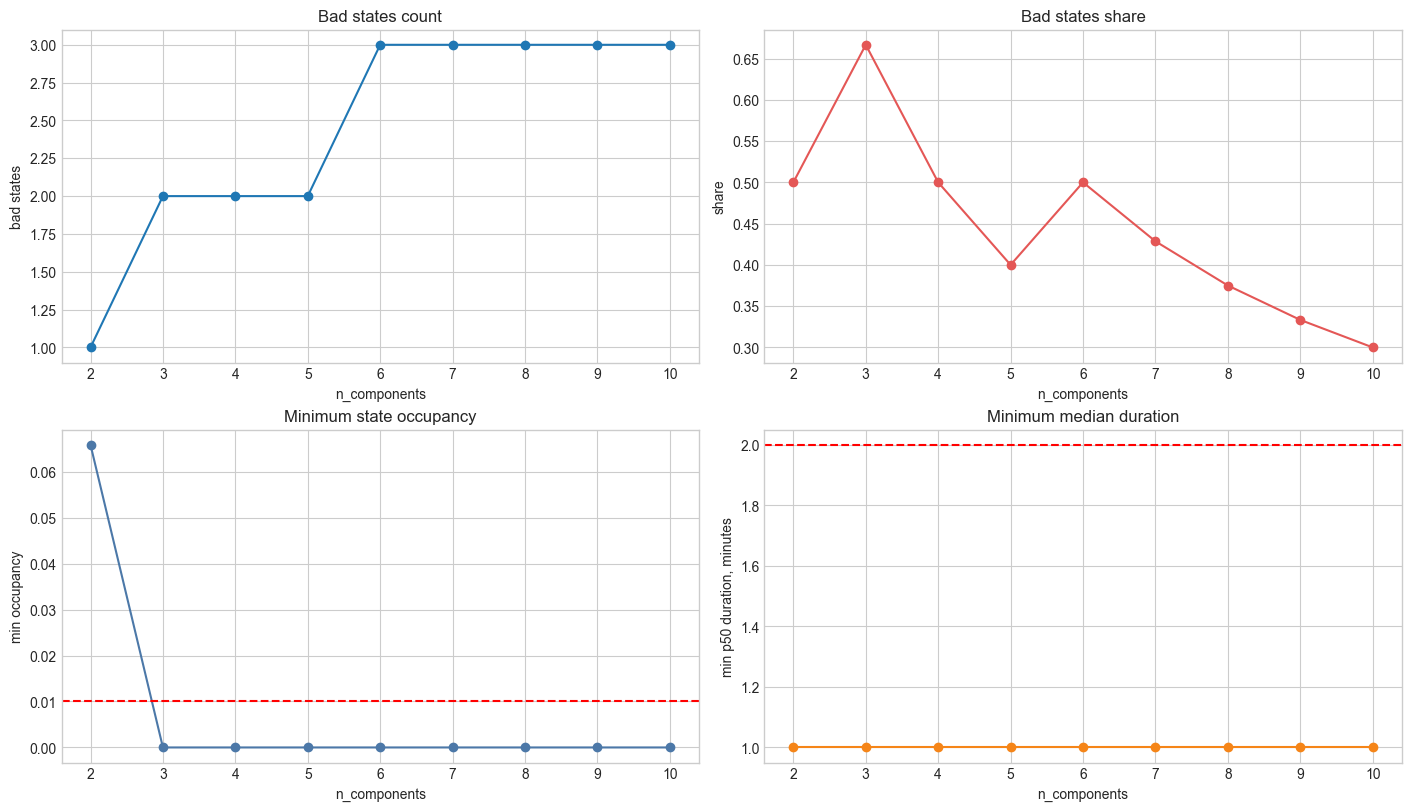

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(
    bad_state_summary_by_n["n_components"],
    bad_state_summary_by_n["bad_states"],
    marker="o",
)
axes[0, 0].set_title("Bad states count")
axes[0, 0].set_xlabel("n_components")
axes[0, 0].set_ylabel("bad states")

axes[0, 1].plot(
    bad_state_summary_by_n["n_components"],
    bad_state_summary_by_n["bad_state_share"],
    marker="o",
    color="#E45756",
)
axes[0, 1].set_title("Bad states share")
axes[0, 1].set_xlabel("n_components")
axes[0, 1].set_ylabel("share")

axes[1, 0].plot(
    bad_state_summary_by_n["n_components"],
    bad_state_summary_by_n["min_occupancy"],
    marker="o",
    color="#4C78A8",
)
axes[1, 0].axhline(BAD_STATE_RULES["min_occupancy"], color="red", linestyle="--")
axes[1, 0].set_title("Minimum state occupancy")
axes[1, 0].set_xlabel("n_components")
axes[1, 0].set_ylabel("min occupancy")

axes[1, 1].plot(
    bad_state_summary_by_n["n_components"],
    bad_state_summary_by_n["min_p50_duration"],
    marker="o",
    color="#F58518",
)
axes[1, 1].axhline(BAD_STATE_RULES["min_p50_duration"], color="red", linestyle="--")
axes[1, 1].set_title("Minimum median duration")
axes[1, 1].set_xlabel("n_components")
axes[1, 1].set_ylabel("min p50 duration, minutes")

plt.show()

In [31]:
MODEL_GROUP_TO_CHECK = "price"  # "price", "flow", "market"
N_COMPONENTS_TO_PLOT = sorted(successful["n_components"].unique())

best_seed_by_n = (
    successful[successful["model_group"].eq(MODEL_GROUP_TO_CHECK)]
    .sort_values("bic", ascending=True)
    .groupby("n_components", as_index=False)
    .head(1)
    .sort_values("n_components")
    .reset_index(drop=True)
)

best_seed_by_n[
    [
        "model_group",
        "n_components",
        "random_state",
        "bic",
        "aic",
        "log_likelihood",
        "converged",
        "n_iter",
    ]
]

,model_group,n_components,random_state,bic,aic,log_likelihood,converged,n_iter
0,price,2,1,2.674905e+07,2.674850e+07,-1.337421e+07,True,46
1,price,3,19,2.355179e+07,2.355092e+07,-1.177539e+07,True,73
2,price,4,15,2.175273e+07,2.175151e+07,-1.087566e+07,True,150
3,price,5,12,2.050312e+07,2.050153e+07,-1.025064e+07,True,120
4,price,6,16,1.950320e+07,1.950122e+07,-9.750454e+06,True,195
5,price,7,1,1.874546e+07,1.874306e+07,-9.371343e+06,True,209
6,price,8,15,1.815625e+07,1.815340e+07,-9.076475e+06,True,305
7,price,9,19,1.757054e+07,1.756721e+07,-8.783347e+06,True,400
8,price,10,16,1.702541e+07,1.702159e+07,-8.510495e+06,True,400


price | n=2 | best seed=1 | BIC=26749053.53


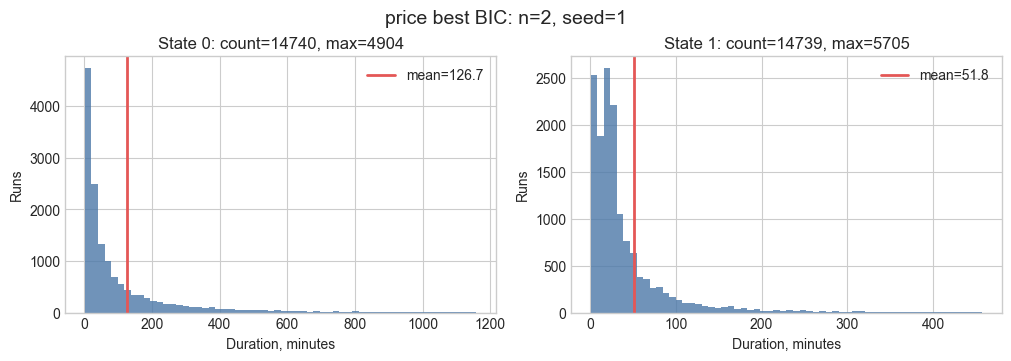

price | n=3 | best seed=19 | BIC=23551793.30


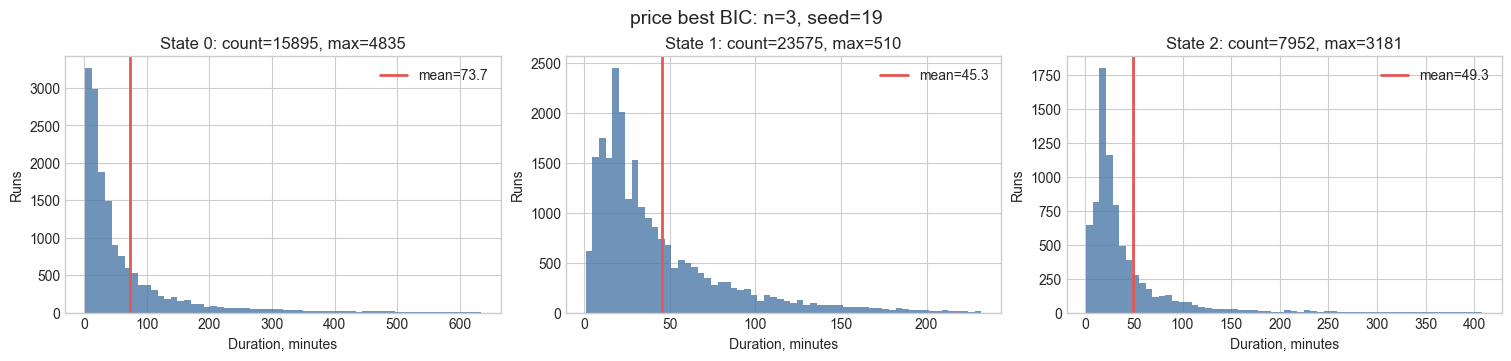

price | n=4 | best seed=15 | BIC=21752727.14


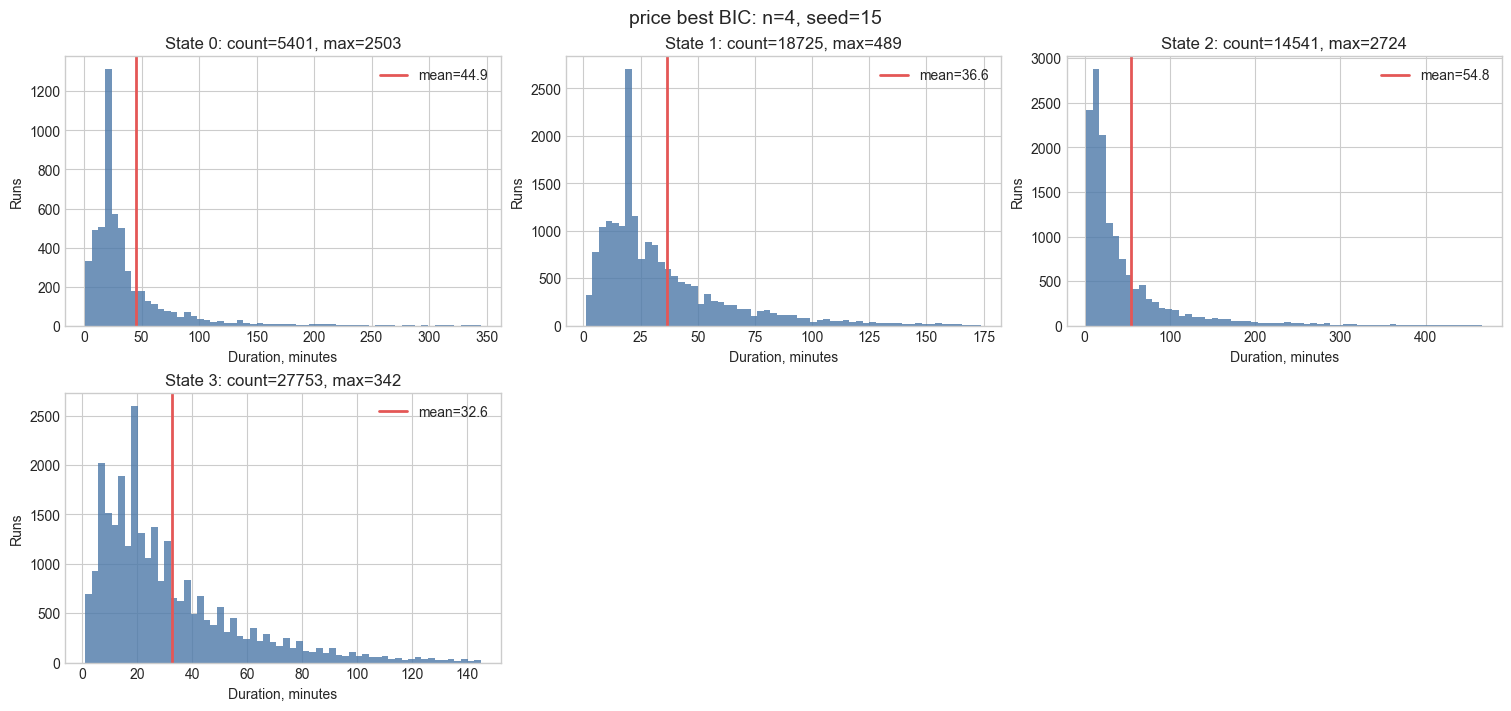

price | n=5 | best seed=12 | BIC=20503115.03


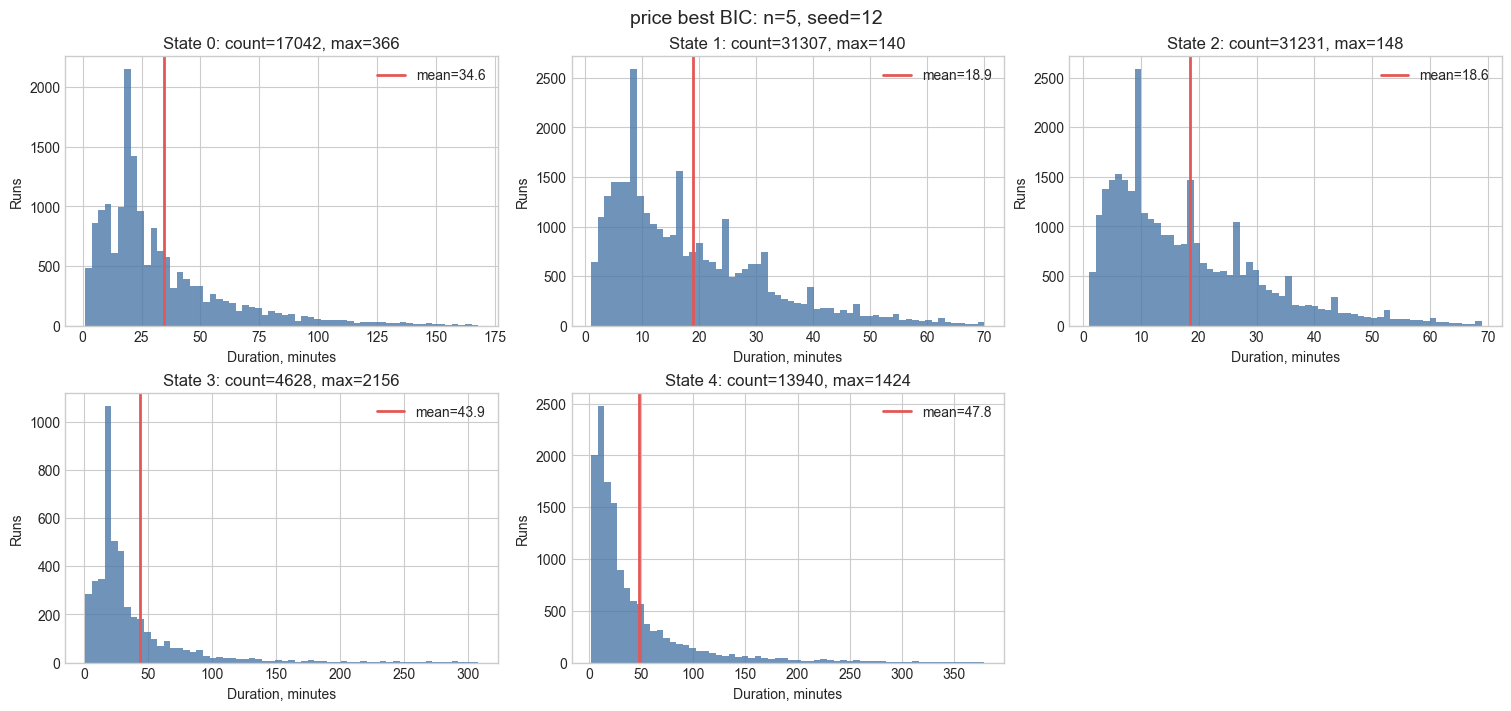

price | n=6 | best seed=16 | BIC=19503199.47


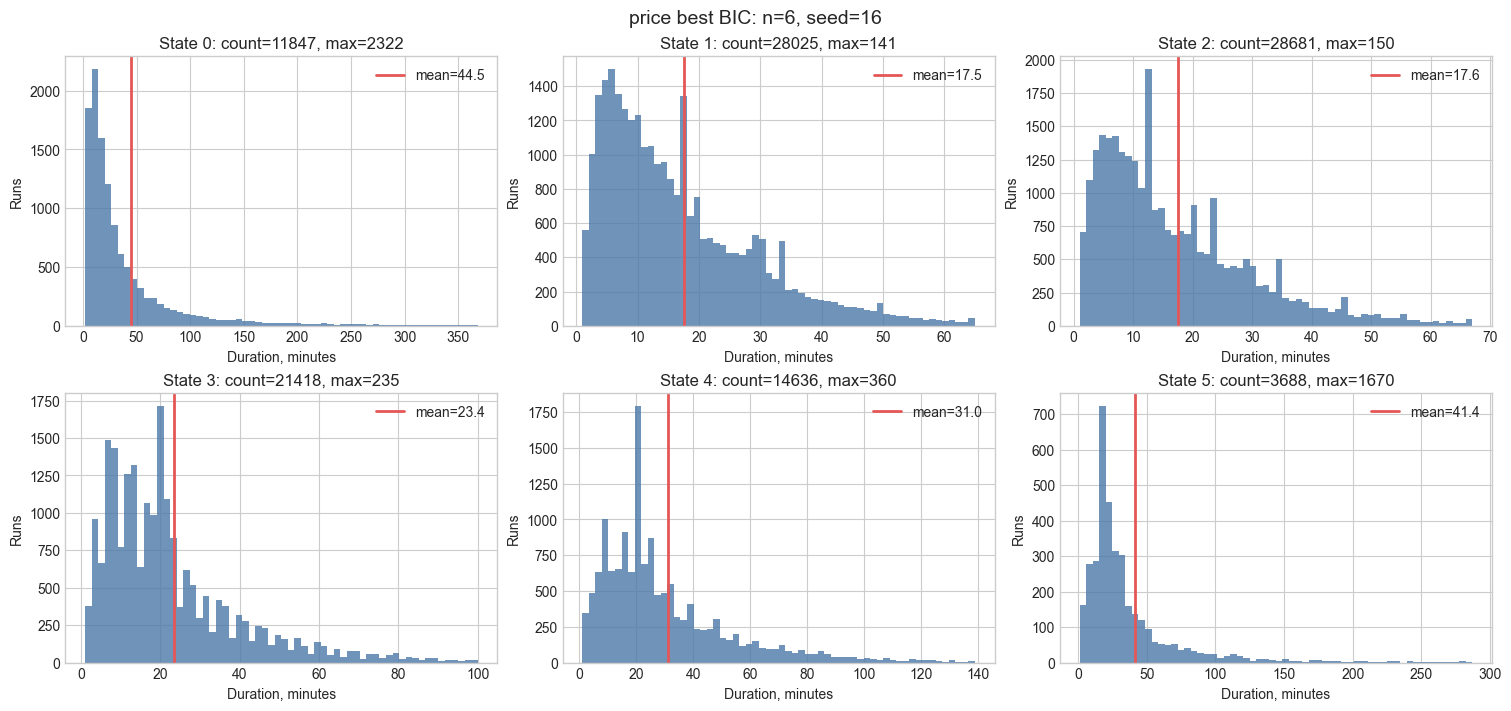

price | n=7 | best seed=1 | BIC=18745464.27


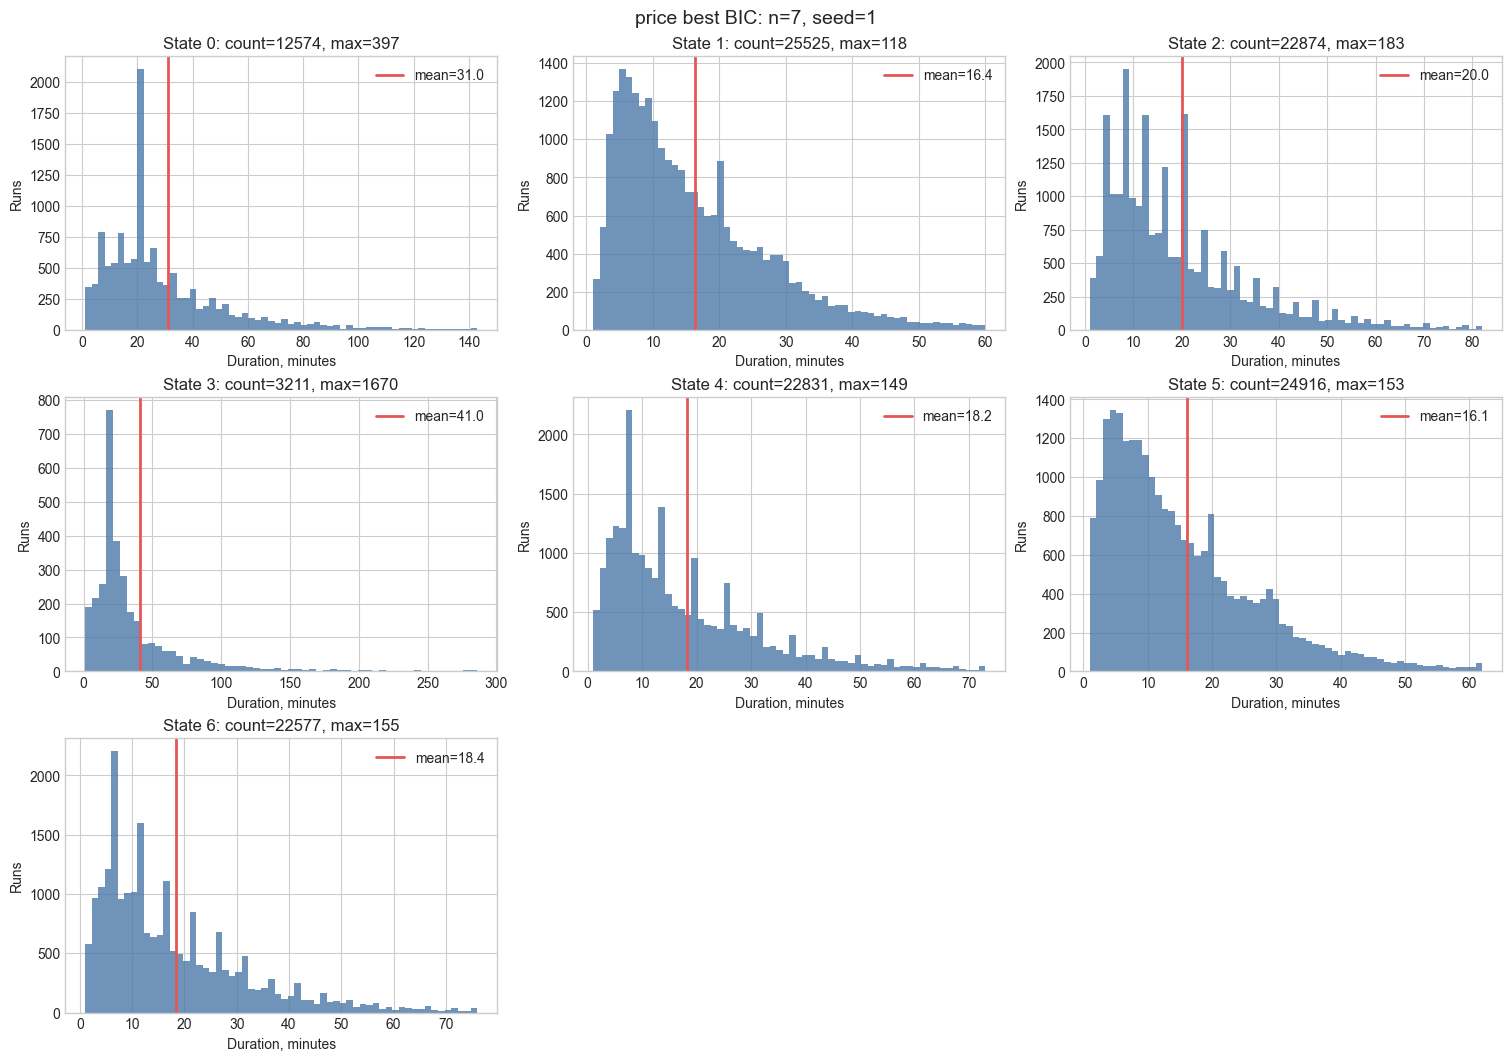

price | n=8 | best seed=15 | BIC=18156247.23


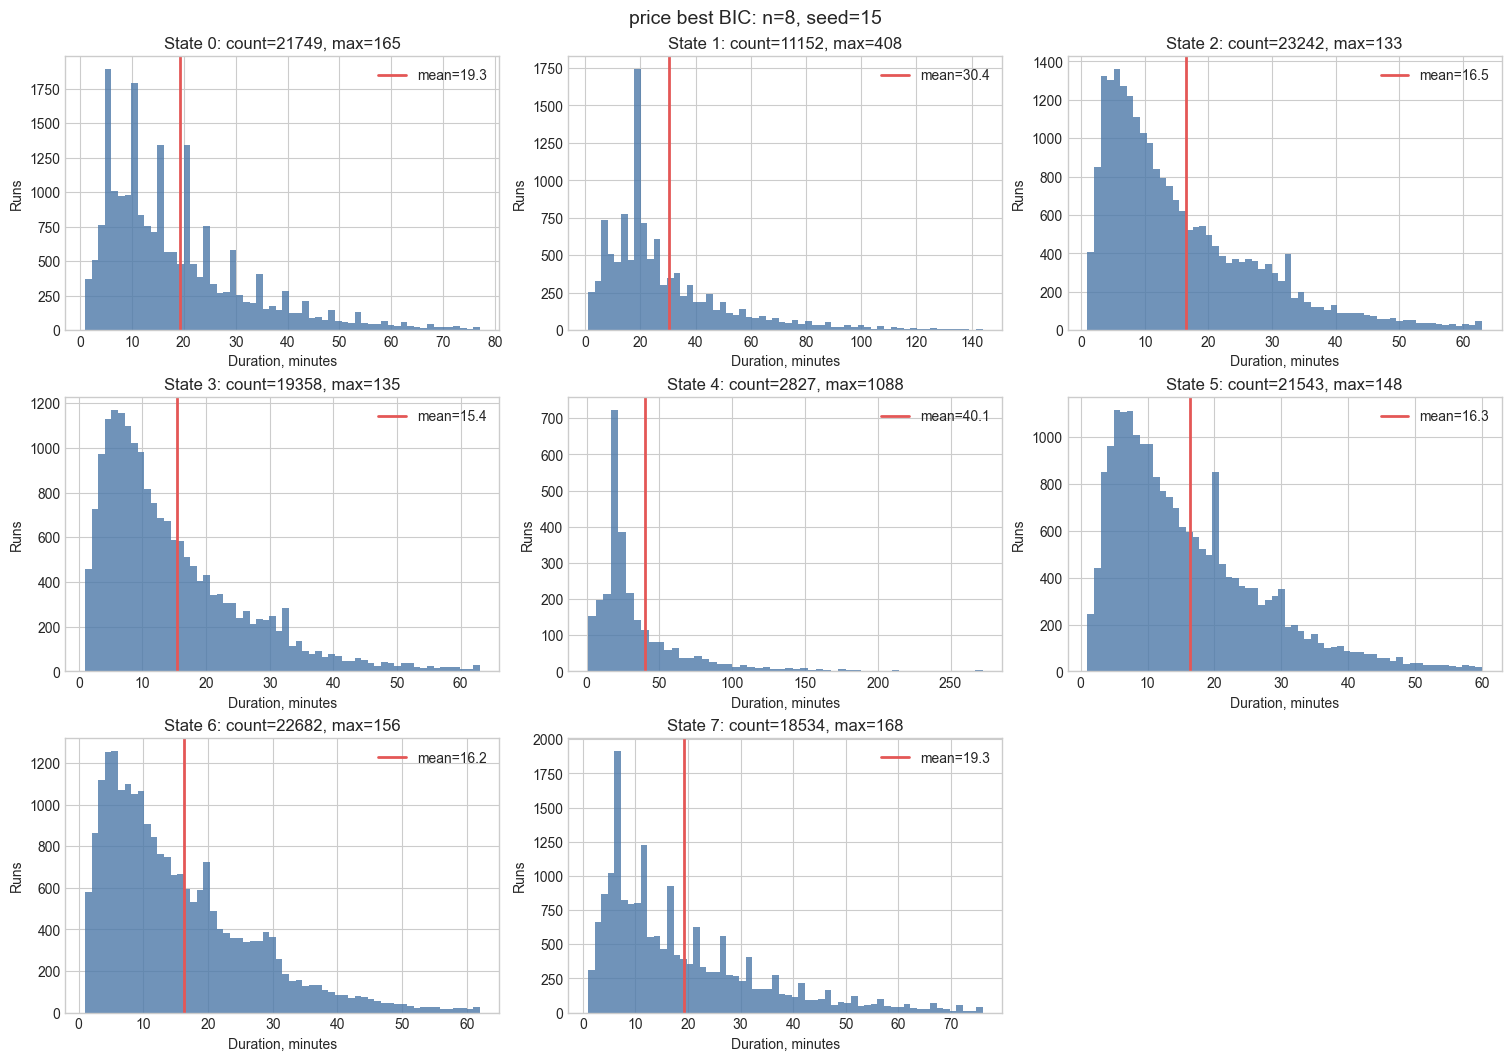

price | n=9 | best seed=19 | BIC=17570538.16


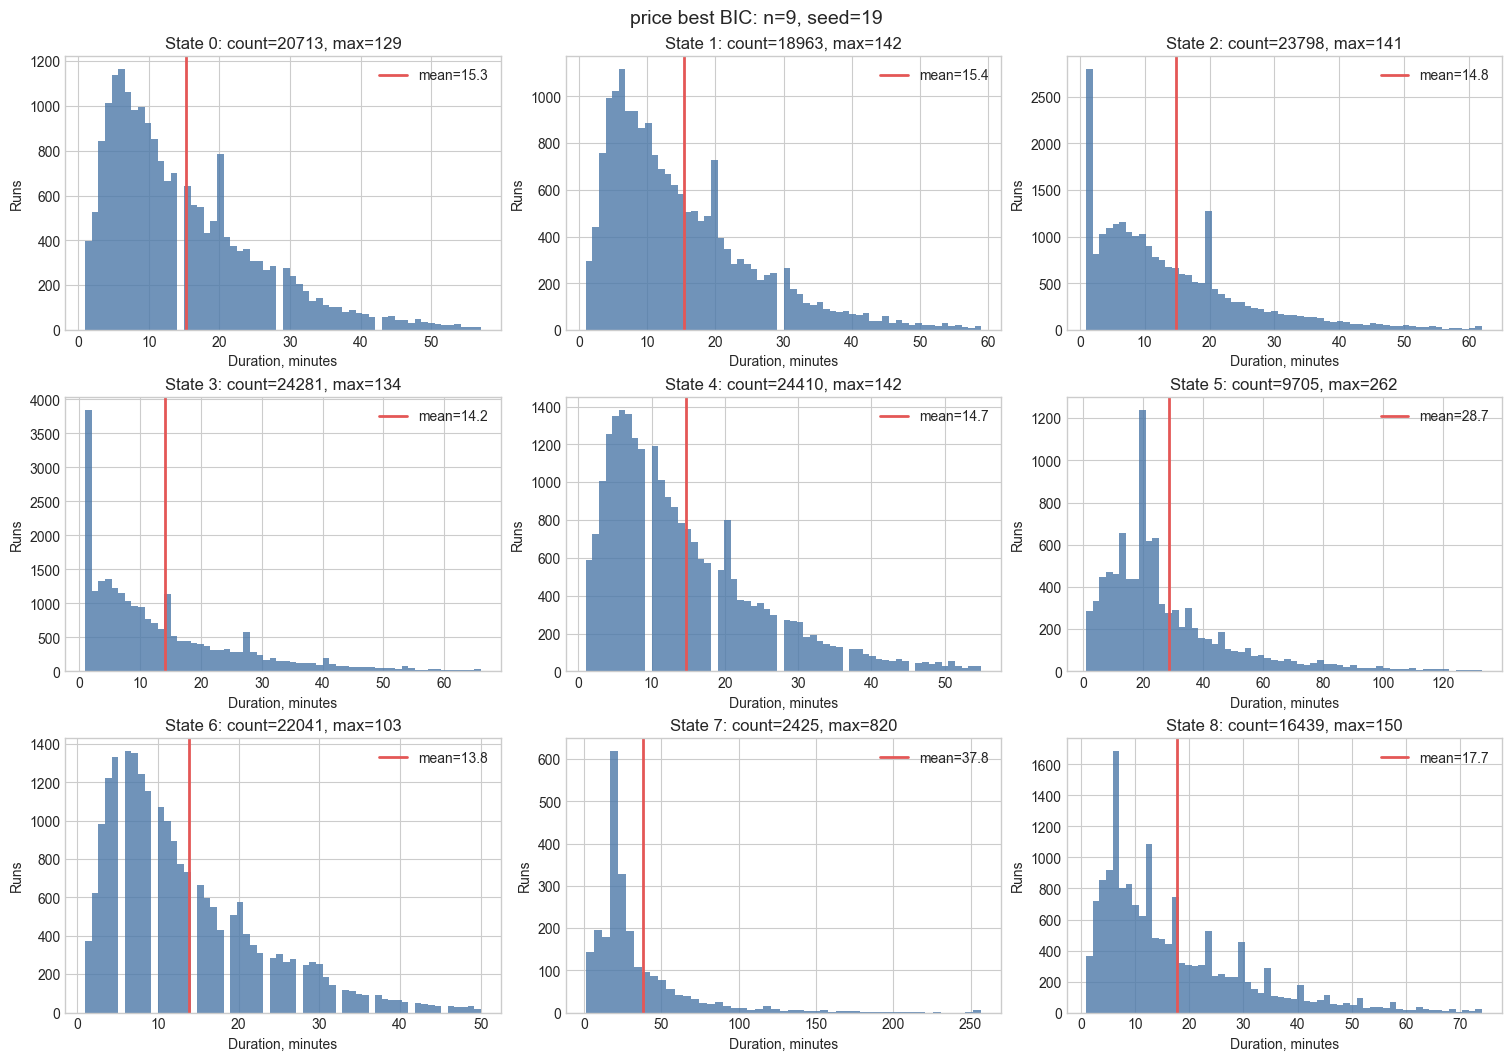

price | n=10 | best seed=16 | BIC=17025411.02


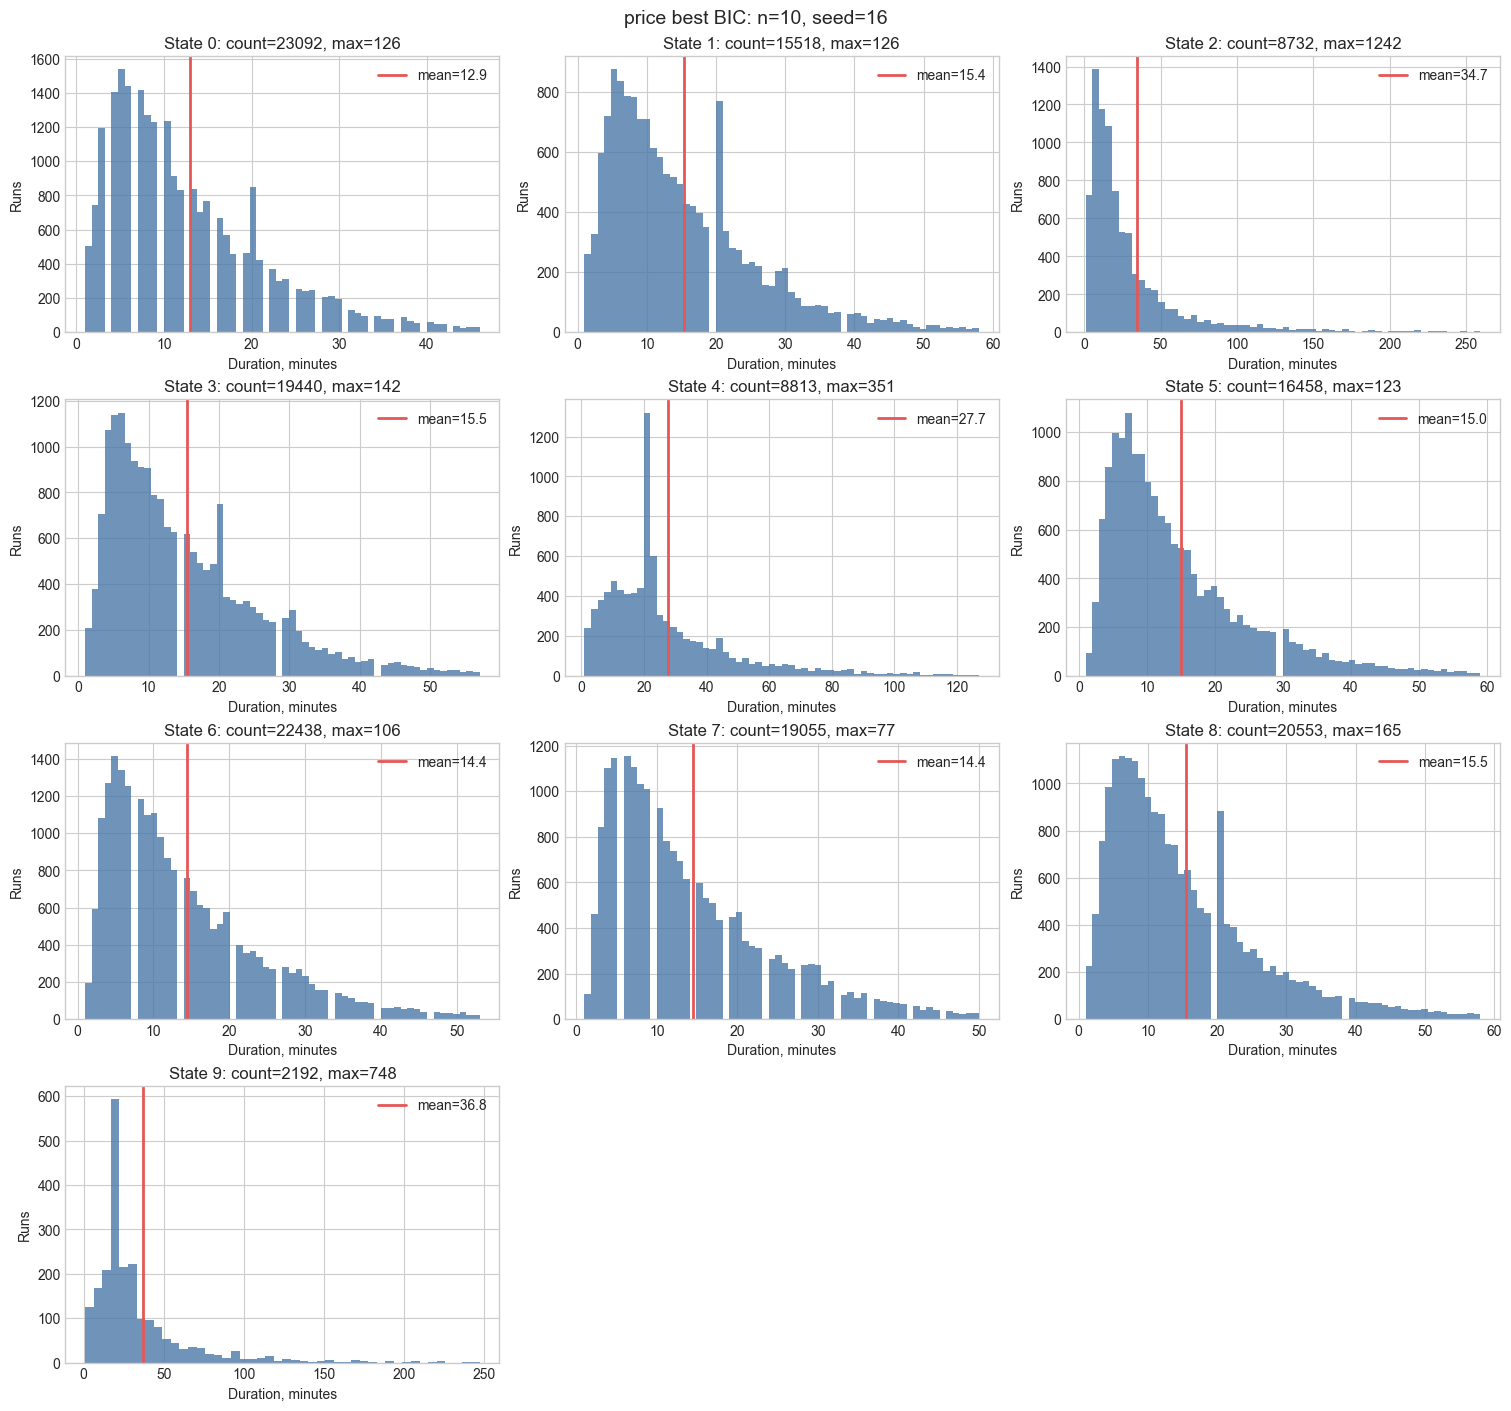

In [32]:
for _, row in best_seed_by_n.iterrows():
    print(
        f"{row['model_group']} | "
        f"n={int(row['n_components'])} | "
        f"best seed={int(row['random_state'])} | "
        f"BIC={row['bic']:.2f}"
    )
    plot_duration_distribution(row, max_duration_quantile=0.99)

## Q25 / Q50 / Q75 длительностей по режимам

Для каждой `model_group` и каждого `n_components` выбираем лучший seed по BIC, затем считаем квартильные длительности каждого режима.

In [15]:
def duration_quartiles_for_row(row: pd.Series) -> pd.DataFrame:
    durations_by_state = parse_json(row["state_duration_distribution"])
    occupancy = parse_array(row["state_occupancy"])
    transition_matrix = parse_array(row["transition_matrix"])

    rows = []
    for state_id, durations in enumerate(durations_by_state):
        values = np.asarray(durations, dtype="float64")
        if len(values) == 0:
            q25 = q50 = q75 = mean = max_duration = np.nan
            runs = 0
        else:
            q25, q50, q75 = np.quantile(values, [0.25, 0.50, 0.75])
            mean = values.mean()
            max_duration = values.max()
            runs = len(values)

        rows.append(
            {
                "model_group": row["model_group"],
                "n_components": int(row["n_components"]),
                "random_state": int(row["random_state"]),
                "state": state_id,
                "occupancy": occupancy[state_id],
                "runs": runs,
                "q25_duration": q25,
                "q50_duration": q50,
                "q75_duration": q75,
                "mean_duration": mean,
                "max_duration": max_duration,
                "self_transition": transition_matrix[state_id, state_id],
                "bic": row["bic"],
                "aic": row["aic"],
                "log_likelihood": row["log_likelihood"],
            }
        )
    return pd.DataFrame(rows)


best_seed_rows_by_group_n = (
    successful.sort_values("bic", ascending=True)
    .groupby(["model_group", "n_components"], as_index=False)
    .head(1)
    .sort_values(["model_group", "n_components"])
    .reset_index(drop=True)
)

duration_quartiles_by_state = pd.concat(
    [duration_quartiles_for_row(row) for _, row in best_seed_rows_by_group_n.iterrows()],
    ignore_index=True,
)

duration_quartiles_by_state.sort_values(
    ["model_group", "n_components", "state"]
).reset_index(drop=True)

,model_group,n_components,random_state,state,occupancy,runs,q25_duration,q50_duration,q75_duration,mean_duration,max_duration,self_transition,bic,aic,log_likelihood
0,flow,2,16,0,7.153761e-02,72128,1.0,1.0,2.0,2.609167,761.0,0.615542,-5.137057e+06,-5.137607e+06,2.568846e+06
1,flow,2,16,1,9.284624e-01,72129,5.0,18.0,47.0,33.863023,1077.0,0.970060,-5.137057e+06,-5.137607e+06,2.568846e+06
2,flow,3,16,0,8.782871e-02,74911,1.0,1.0,2.0,3.084340,757.0,0.673759,-5.920654e+06,-5.921523e+06,2.960830e+06
3,flow,3,16,1,9.121709e-01,74912,5.0,18.0,45.0,32.032892,549.0,0.968242,-5.920654e+06,-5.921523e+06,2.960830e+06
4,flow,3,16,2,3.801270e-07,1,1.0,1.0,1.0,1.000000,1.0,0.000000,-5.920654e+06,-5.921523e+06,2.960830e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,price,10,16,5,9.408408e-02,16458,7.0,11.0,20.0,15.038705,123.0,0.927828,1.702541e+07,1.702159e+07,-8.510495e+06
158,price,10,16,6,1.231627e-01,22438,6.0,11.0,19.0,14.439968,106.0,0.925660,1.702541e+07,1.702159e+07,-8.510495e+06
159,price,10,16,7,1.045167e-01,19055,6.0,11.0,20.0,14.429389,77.0,0.924388,1.702541e+07,1.702159e+07,-8.510495e+06
160,price,10,16,8,1.210134e-01,20553,7.0,12.0,20.0,15.489223,165.0,0.928741,1.702541e+07,1.702159e+07,-8.510495e+06


In [16]:
# Compact-view для одной группы: строки = n_components, колонки = state,
# значения = выбранный квартиль длительности.
MODEL_GROUP_FOR_QUARTILE_TABLE = "flow"  # "price", "flow", "market"
VALUE_COLUMN = "q50_duration"  # "q25_duration", "q50_duration", "q75_duration"

duration_quartile_pivot = (
    duration_quartiles_by_state[
        duration_quartiles_by_state["model_group"].eq(MODEL_GROUP_FOR_QUARTILE_TABLE)
    ]
    .pivot_table(
        index="n_components",
        columns="state",
        values=VALUE_COLUMN,
        aggfunc="first",
    )
    .sort_index()
)

duration_quartile_pivot

state,0,1,2,3,4,5,6,7,8,9
n_components,,,,,,,,,,
2,1.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,18.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11.0,1.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
5,16.0,10.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN
6,8.0,19.0,1.0,1.0,2.0,13.0,NaN,NaN,NaN,NaN
7,2.0,9.0,1.0,15.0,10.0,1.0,19.0,NaN,NaN,NaN
8,2.0,10.0,1.0,1.0,16.0,11.0,12.0,18.0,NaN,NaN
9,9.0,1.0,16.0,10.0,1.0,4.0,11.0,16.0,2.0,NaN
10,11.0,2.0,1.0,1.0,3.0,12.0,11.0,8.0,3.0,12.0


In [18]:
# Все три квартиля в одном wide-формате для выбранной группы.
# Ячейка самодостаточна после загрузки `successful`: если промежуточные
# ячейки были удалены или ядро перезапущено, нужные таблицы пересобираются здесь.
import json

if "MODEL_GROUP_FOR_QUARTILE_TABLE" not in globals():
    MODEL_GROUP_FOR_QUARTILE_TABLE = "market"  # "price", "flow", "market"

if "parse_json" not in globals():
    def parse_json(value):
        if value is None or (isinstance(value, float) and np.isnan(value)):
            return None
        if isinstance(value, str):
            return json.loads(value)
        return value

if "parse_array" not in globals():
    def parse_array(value) -> np.ndarray | None:
        parsed = parse_json(value)
        if parsed is None:
            return None
        return np.asarray(parsed, dtype="float64")

if "duration_quartiles_for_row" not in globals():
    def duration_quartiles_for_row(row: pd.Series) -> pd.DataFrame:
        durations_by_state = parse_json(row["state_duration_distribution"])
        occupancy = parse_array(row["state_occupancy"])
        transition_matrix = parse_array(row["transition_matrix"])

        rows = []
        for state_id, durations in enumerate(durations_by_state):
            values = np.asarray(durations, dtype="float64")
            if len(values) == 0:
                q25 = q50 = q75 = mean = max_duration = np.nan
                runs = 0
            else:
                q25, q50, q75 = np.quantile(values, [0.25, 0.50, 0.75])
                mean = values.mean()
                max_duration = values.max()
                runs = len(values)

            rows.append(
                {
                    "model_group": row["model_group"],
                    "n_components": int(row["n_components"]),
                    "random_state": int(row["random_state"]),
                    "state": state_id,
                    "occupancy": occupancy[state_id],
                    "runs": runs,
                    "q25_duration": q25,
                    "q50_duration": q50,
                    "q75_duration": q75,
                    "mean_duration": mean,
                    "max_duration": max_duration,
                    "self_transition": transition_matrix[state_id, state_id],
                    "bic": row["bic"],
                    "aic": row["aic"],
                    "log_likelihood": row["log_likelihood"],
                }
            )
        return pd.DataFrame(rows)

if "duration_quartiles_by_state" not in globals():
    best_seed_rows_by_group_n = (
        successful.sort_values("bic", ascending=True)
        .groupby(["model_group", "n_components"], as_index=False)
        .head(1)
        .sort_values(["model_group", "n_components"])
        .reset_index(drop=True)
    )

    duration_quartiles_by_state = pd.concat(
        [duration_quartiles_for_row(row) for _, row in best_seed_rows_by_group_n.iterrows()],
        ignore_index=True,
    )

duration_quartiles_wide = (
    duration_quartiles_by_state[
        duration_quartiles_by_state["model_group"].eq(MODEL_GROUP_FOR_QUARTILE_TABLE)
    ]
    .pivot_table(
        index="n_components",
        columns="state",
        values=["q25_duration", "q50_duration", "q75_duration"],
        aggfunc="first",
    )
    .sort_index()
)

duration_quartiles_wide

q25_duration                                              q50_duration                                                      q75_duration                                                 \
state                   0    1    2    3    4    5    6    7    8    9            0     1     2     3     4     5     6     7    8     9            0     1     2     3     4     5     6     7    8   
n_components                                                                                                                                                                                           
2                     1.0  5.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN          1.0  18.0   NaN   NaN   NaN   NaN   NaN   NaN  NaN   NaN          2.0  47.0   NaN   NaN   NaN   NaN   NaN   NaN  NaN   
3                     1.0  5.0  1.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN          1.0  18.0   1.0   NaN   NaN   NaN   NaN   NaN  NaN   NaN          2.0  45.0   1.0   NaN   NaN   NaN   NaN   NaN  NaN   
4                     5.0  1.0  1.0  1.0  NaN  NaN  NaN  NaN  NaN  NaN         11.0   1.0   1.0   3.0   NaN   NaN   NaN   NaN  NaN   NaN         24.0   2.0   1.0   6.0   NaN   NaN   NaN   NaN  NaN   
5                     7.0  5.0  1.0  1.0  1.0  NaN  NaN  NaN  NaN  NaN         16.0  10.0   1.0   1.0   2.0   NaN   NaN   NaN  NaN   NaN         35.0  21.0   1.0   1.0   5.0   NaN   NaN   NaN  NaN   
6                     4.0  8.0  1.0  1.0  1.0  6.0  NaN  NaN  NaN  NaN          8.0  19.0   1.0   1.0   2.0  13.0   NaN   NaN  NaN   NaN         17.0  36.0   1.0   1.0   4.0  27.0   NaN   NaN  NaN   
7                     1.0  4.0  1.0  7.0  4.0  1.0  7.0  NaN  NaN  NaN          2.0   9.0   1.0  15.0  10.0   1.0  19.0   NaN  NaN   NaN          4.0  20.0   1.0  31.0  21.0   1.0  38.0   NaN  NaN   
8                     1.0  5.0  1.0  1.0  7.0  5.0  5.0  6.0  NaN  NaN          2.0  10.0   1.0   1.0  16.0  11.0  12.0  18.0  NaN   NaN          4.0  20.0   1.0   1.0  33.0  22.0  24.0  37.0  NaN   
9                     4.0  1.0  7.0  5.0  1.0  2.0  5.0  7.0  1.0  NaN          9.0   1.0  16.0  10.0   1.0   4.0  11.0  16.0  2.0   NaN         19.0   1.0  30.0  21.0   1.0   9.0  21.0  32.0  4.0   
10                    5.0  1.0  1.0  1.0  1.0  6.0  5.0  4.0  2.0  6.0         11.0   2.0   1.0   1.0   3.0  12.0  11.0   8.0  3.0  12.0         20.0   4.0   1.0   1.0   7.0  26.0  21.0  17.0  6.0   

                    
state            9  
n_components        
2              NaN  
3              NaN  
4              NaN  
5              NaN  
6              NaN  
7              NaN  
8              NaN  
9              NaN  
10            23.0

In [ ]:
# Диагностика: минимальные q25/q50/q75 среди states для каждого n.
# Если min_q50 или min_q75 падает к 1-2 минутам, режимы становятся короткоживущими.
duration_quartile_health_by_n = (
    duration_quartiles_by_state.groupby(["model_group", "n_components"], as_index=False)
    .agg(
        states=("state", "count"),
        min_occupancy=("occupancy", "min"),
        min_q25=("q25_duration", "min"),
        min_q50=("q50_duration", "min"),
        min_q75=("q75_duration", "min"),
        min_self_transition=("self_transition", "min"),
        bic=("bic", "first"),
        random_state=("random_state", "first"),
    )
    .sort_values(["model_group", "n_components"])
)

duration_quartile_health_by_n